# **Budget Estimation**

## *Project scope*

This model is scoped to research budgets **up to 1,000,000 NIS**. Proposals above this
threshold go through a separate, dedicated committee review process and are excluded
from both the dataset and the target problem definition. In the current data, this
affects only ~5 records (all at the 4,000,000 NIS tier), so the scoping cost is minimal
while it also removes the most extreme tail driving the target's skewness.

## *Data Attribution*


This dataset was constructed from 140 Israeli Ministry of Education research grant records. Each row represents one funded research proposal, extracted from a "golden triangle" of three source documents per proposal:

1. **Call for proposals** (קול קורא) — the funding call under which the proposal was submitted
2. **Research proposal** (הצעת מחקר) — the PI's submitted research design
3. **Budget breakdown** (פילוח תקציבי) — the itemized budget allocation for the proposal

Structured fields (25 attributes per record, including study design parameters, methodology flags, and budgeted person-work) were extracted from each triangle using Google NotebookLM, then consolidated, validated, and merged into a single structured table through manual QA.


## *Data Dictionary*



Field definitions as specified in the extraction prompt given to NotebookLM.

| Column | Type | Description |
|---|---|---|
| `call_title` | string | Title of the call for proposals (קול קורא) |
| `pi_name` | string | Name of the principal investigator(s) |
| `proposal_title` | string | Title of the submitted research proposal |
| `duration_months` | int | Research duration in months (`-1` = unknown) |
| `site_count` | int | Number of research sites / participating schools (`-1` = unknown) |
| `subject_count` | int | Number of research subjects / participants (`-1` = unknown) |
| `target_populations_count` | int | Number of distinct target populations (`-1` = unknown) |
| `data_waves_count` | int | Number of data collection waves (`-1` = unknown) |
| `has_surveys` | binary | Uses questionnaires/surveys (1 = yes, 0 = no, -1 = unknown) |
| `has_interviews` | binary | Uses interviews (1/0/-1) |
| `has_focus_groups` | binary | Uses focus groups (1/0/-1) |
| `has_observations` | binary | Uses observations (1/0/-1) |
| `has_tests` | binary | Uses tests/assessments (1/0/-1) |
| `collection_mode` | categorical | Primary data collection mode: `Online`, `Field`, `SurveyInstitute`, `Mixed`, `Unknown` |
| `tool_development_type` | categorical | Level of instrument development: `Existing`, `Adaptation`, `New`, `Validation`, `Unknown` |
| `languages_count` | int | Number of languages used (`-1` = unknown) |
| `requires_translation` | binary | Requires translation / cultural adaptation (1/0/-1) |
| `uses_admin_data` | binary | Uses administrative / research-room data (1/0/-1) |
| `requires_data_linking` | binary | Requires linking/merging of datasets (1/0/-1) |
| `is_complex_design` | binary | Complex design — control group / complex population (1/0/-1) |
| `budgeted_person_work` | int/float | Total budgeted amount for personnel work, in NIS (monetary value, not months; `-1` = unknown) |
| `has_external_services` | binary | Purchases external services (surveys, statistics, editing) (1/0/-1) |
| `deliverables_level` | categorical | Scope of deliverables: `Standard`, `Extended`, `Unknown` |
| `has_special_equipment` | binary | Includes dedicated equipment in budget (1/0/-1) |
| `is_multidisciplinary` | binary | Multidisciplinary research (1/0/-1) |

## *Setup*

### *Imports*

In [190]:
import pandas as pd
import numpy as np
import plotnine as pln
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns

### *Dataset Loading*

In [191]:
df = pd.read_csv(r"C:\Users\idowe\MyProjects\MOECSO\budget_estimation\research_table_with_budget_and_sources.csv", encoding="utf-8-sig")

In [192]:
df.head()

,source_file,call_title,pi_name,proposal_title,duration_months,site_count,subject_count,target_populations_count,data_waves_count,has_surveys,...,requires_translation,uses_admin_data,requires_data_linking,is_complex_design,budgeted_person_work,has_external_services,deliverables_level,has_special_equipment,is_multidisciplinary,target_budget
0,אורטל_סלובדין_21.txt,קול קורא מס' 2021.11/27 למחקר בנושא החינוך בחב...,פרופ' אורטל סלובודין,"הארון הכפול: נוער להט""בי במערכת החינוך הערבית ...",18,80,80,-1,-1,0,...,-1,0,0,0,125280.0,1,Unknown,0,-1,300000
1,אורטל_סלובדין_24.txt,קול קורא מס' 15/5.2024 למחקר בנושא חינוך בצל מ...,"פרופ' אורטל סלובודין, פרופ' הללי פינסון",חסמים באיתור ובהשתתפות תלמידים/ות מהחברה הבדוא...,18,8,100,2,1,0,...,1,1,0,1,134676.0,1,Extended,0,1,200000
2,אורי_כהן_21.txt,קול קורא מס' 27/11.2021 למחקר בנושא החינוך בחב...,אורי כהן,יחסי גומלין בין מנהל החינוך ברשות המקומית לבתי...,18,25,65,3,-1,0,...,-1,0,0,0,248400.0,0,Unknown,0,-1,300000
3,אורית_חזן_24.txt,"קול קורא מס' 27/8.24 למחקר בנושא ""קבלת החלטות ...",אורית חזן,קבלת החלטות בית ספריות מבוססות נתונים בקרב מנה...,16,25,175,1,2,1,...,0,0,0,1,217500.0,1,Standard,0,0,250000
4,אורלי_ליפקה_24.txt,קול קורא מס 15/5.2024 למחקר בנושא חינוך בצל מש...,"אורלי ליפקה, תמר קציר",חוסן אישי ותחושת שלומות של מורים בחברה הערבית ...,18,-1,1255,2,2,1,...,1,0,0,1,135000.0,1,Extended,0,1,200000


## *EDA - Explorary Data Analysis*

### *Structural analysis*

In [193]:
df.shape

(140, 27)

In [194]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   source_file               140 non-null    str    
 1   call_title                140 non-null    str    
 2   pi_name                   140 non-null    str    
 3   proposal_title            140 non-null    str    
 4   duration_months           140 non-null    int64  
 5   site_count                140 non-null    int64  
 6   subject_count             140 non-null    int64  
 7   target_populations_count  140 non-null    int64  
 8   data_waves_count          140 non-null    int64  
 9   has_surveys               140 non-null    int64  
 10  has_interviews            140 non-null    int64  
 11  has_focus_groups          140 non-null    int64  
 12  has_observations          140 non-null    int64  
 13  has_tests                 140 non-null    int64  
 14  collection_mode      

### *Missing values*

#### *Missing values statistics*

As expeected there are no NaN values because in the prompt we defined unkhown as -1.

In [195]:
df.isnull() # check NaN in each parameter

,source_file,call_title,pi_name,proposal_title,duration_months,site_count,subject_count,target_populations_count,data_waves_count,has_surveys,...,requires_translation,uses_admin_data,requires_data_linking,is_complex_design,budgeted_person_work,has_external_services,deliverables_level,has_special_equipment,is_multidisciplinary,target_budget
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
136,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
137,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
138,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False



What the `-1` counts in each column actually mean (based on 140 records):

- **Text fields** (`source_file`, `call_title`, `pi_name`, `proposal_title`): 0% missing. These are just copied names/titles from the documents, so there's basically always something there.

- **`duration_months`** (0.7%, 1 missing): Almost every proposal says how long the study will take. Makes sense — it's a basic thing every proposal has to state.

- **`site_count`** (52.9%, 74 missing): This is the big one. More than half the proposals don't say how many schools/sites are involved. Probably because a lot of studies (online surveys, phone interviews, etc.) don't really work through a fixed number of "sites," or the researcher just didn't bother specifying it.

- **`subject_count`** (26.4%, 37 missing): About 1 in 4 proposals don't say how many people will take part. Could be because at the proposal stage the exact sample size wasn't decided yet.

- **`target_populations_count`** (24.3%, 34 missing): Similar story — a lot of proposals don't clearly say how many different population groups they're studying, especially when there's really just one group and it's obvious.

- **`data_waves_count`** (36.4%, 51 missing): Missing a lot too. Probably because many studies only collect data once (not in "waves"), so this question doesn't really apply, or it just wasn't stated.

- **`has_surveys`** (0.7%, 1 missing): Almost always known. Whether a study uses surveys or not is usually obvious from reading the proposal.

**Bottom line:** The missing values aren't random. They're mostly concentrated in the "give me an exact number" fields (site count, subject count, target populations, data waves) — because these require someone to have actually written a specific number down (mostly those are paramters that determined during the research). The yes/no methodology questions, on the other hand, are almost always answered.

In [196]:
counts = (df == -1).sum()
percent = (counts / len(df) * 100).round(1)

pd.DataFrame({
            "count": counts,
            "percent": percent
              })

,count,percent
source_file,0,0.0
call_title,0,0.0
pi_name,0,0.0
proposal_title,0,0.0
duration_months,1,0.7
site_count,74,52.9
subject_count,37,26.4
target_populations_count,34,24.3
data_waves_count,51,36.4
has_surveys,1,0.7


#### *NotebookLM labeling audit*

High missingness in `site_count` (52.9%), `data_waves_count` (36.4%) and
`languages_count` (~40%) does not necessarily mean the information was absent from
the source triangle — it may reflect NotebookLM failing to extract data that was
actually present. Before deciding to exclude or impute these features, a manual
audit is needed: sample ~15-20 missing rows per suspect feature, check the original
documents, and classify each as either (a) genuinely missing (never stated) or
(b) an extraction failure. A high extraction-failure rate means the fix is a better
prompt / re-run, not feature exclusion.

**This audit matters even more now**, because of the planned input-range binning
(see below): once a feature is converted from a raw number into a small set of
user-facing ranges, we can add an explicit **"don't know yet"** option as a
legitimate bin — which is exactly the situation of an early-stage researcher filling
in the tool. This means a feature doesn't have to be dropped just because it has
many missing values in the historical data: if the missingness reflects a real
"not yet decided" state (rather than a labeling failure), it becomes a *first-class,
predictive category* instead of a problem to clean away — potentially even
improving the model, since it captures a genuine signal about how early-stage the
proposal is.

### *Data cleaning*

#### *(-1) -> NAN conversion*

converting (-1) to nan for applying statistics methods later

In [197]:
cols_with_unknown = df.select_dtypes(include=["number"]).columns.tolist() # collecting columns name's with uncertainty
df_clean = df.copy() # creating clean data frame
df_clean[cols_with_unknown] = df_clean[cols_with_unknown].replace(-1, np.nan)

The missing values after data cleaning

In [198]:
df_clean.isnull().sum().sort_values(ascending = False)

site_count                  74
languages_count             56
data_waves_count            51
subject_count               37
target_populations_count    34
is_multidisciplinary        24
requires_translation        11
requires_data_linking        6
is_complex_design            5
uses_admin_data              4
has_observations             2
has_tests                    2
budgeted_person_work         2
has_focus_groups             2
has_surveys                  1
duration_months              1
has_interviews               1
call_title                   0
pi_name                      0
proposal_title               0
source_file                  0
tool_development_type        0
collection_mode              0
has_external_services        0
deliverables_level           0
has_special_equipment        0
target_budget                0
dtype: int64

#### *Scope limit - under 1M ILS*

original N - number of rows in the data.

In [199]:
original_n = len(df)
print(original_n)

140


Excluding outliers according to project scope

In [200]:
df_clean = df_clean[df_clean["target_budget"] <= 1_000_000].reset_index(drop=True)
after_n = len(df_clean)
print(after_n)

135


### *Univariate Distribution Analysis*

#### *Columns decleration*

In [201]:
numeric_cols = df_clean.select_dtypes(include = ["number"]).columns.tolist()

In [202]:
binary_cols = ["has_surveys", "has_interviews", "has_focus_groups", "has_observations",
               "has_tests", "requires_translation", "uses_admin_data",
               "requires_data_linking", "is_complex_design", "has_external_services",
               "has_special_equipment", "is_multidisciplinary"]

continuous_cols = ["duration_months", "site_count", "subject_count",
                    "target_populations_count", "data_waves_count",
                    "languages_count", "budgeted_person_work", "target_budget"]

#### *Statistical summary*

In [203]:
from scipy.stats import median_abs_deviation

# describe().T as before
summary = df_clean.describe().T

# MAD per column - median of |x - median(x)|
# scale=1 keeps it as the raw median absolute deviation (no normalization to match std of a normal distribution)
mad_values = df_clean[summary.index].apply(
    lambda col: median_abs_deviation(col.dropna(), scale=1)
)

summary["MAD"] = mad_values
summary

,count,mean,std,min,25%,50%,75%,max,MAD
duration_months,134.0,24.522388,8.917092,16.0,18.00,18.0,36.0,60.0,0.0
site_count,63.0,49.555556,79.251290,1.0,8.00,25.0,55.0,500.0,20.0
subject_count,102.0,1103.794118,2114.473201,25.0,156.25,490.0,1057.5,14400.0,390.0
target_populations_count,101.0,2.316832,1.028890,1.0,2.00,2.0,3.0,7.0,1.0
data_waves_count,85.0,2.141176,0.861241,1.0,2.00,2.0,3.0,5.0,1.0
has_surveys,134.0,0.843284,0.364897,0.0,1.00,1.0,1.0,1.0,0.0
has_interviews,134.0,0.701493,0.459320,0.0,0.00,1.0,1.0,1.0,0.0
has_focus_groups,133.0,0.210526,0.409224,0.0,0.00,0.0,0.0,1.0,0.0
has_observations,133.0,0.210526,0.409224,0.0,0.00,0.0,0.0,1.0,0.0
has_tests,133.0,0.278195,0.449804,0.0,0.00,0.0,1.0,1.0,0.0


##### *Skewness & kurtosis*

In [204]:
skew_kurt = pd.DataFrame({
    "Skewness": df_clean[continuous_cols].apply(lambda x: skew(x.dropna())),
    "Kurtosis": df_clean[continuous_cols].apply(lambda x: kurtosis(x.dropna()))
}).sort_values("Skewness", ascending = False)

skew_kurt

,Skewness,Kurtosis
subject_count,4.373755,21.424804
site_count,3.633777,16.075457
target_budget,2.119663,4.245004
budgeted_person_work,1.994417,4.479514
duration_months,1.323853,1.730211
target_populations_count,1.274849,3.345894
data_waves_count,0.625611,0.452306
languages_count,0.253087,-0.627509


#### *Continuous Variables*

##### *Analysis*

###### *Site count*

There are 74 missing values. that means:
- The NotebookLM labeling was not good.
- This parameter was not written explicitly in the "golden triangle".

Outliers:
- There are some outliers. I have to check if they are error - comapre with the triangle itself

Conclusions:
- Because the huge amount of missing values I assume that this feature won't be correlative to the target budget.

In [206]:
df_clean["site_count"].isna().sum()

np.int64(72)

In [207]:
top_n = 10
largest_site_count = df_clean.nlargest(top_n, "site_count")[
    ["source_file", "pi_name", "proposal_title", "site_count", "subject_count"]
]
display(largest_site_count)

,source_file,pi_name,proposal_title,site_count,subject_count
102,שושי_דורפברגר_24.txt,"ד""ר אנאבל פרידלנדר-ליפסיק, ד""ר שושי דורפברגר",הקשר בין קבלת החלטות מבוססת נתונים על ידי מנהל...,500.0,NaN
99,רימאא_דעאס_21.txt,רימאא דעאס,"מנהלים משבר: פיתוח כלי למדידת ""ניהול בזמן משבר""",300.0,2500.0
24,גוי_בנטוב_25.txt,"ד""ר ג'וי בנטוב, פרופ' נוגה כהן, ד""ר דנה לסרי","הערכת קבלת, יישמות, ויעילות התוכנית הבית ספרית...",180.0,14400.0
44,יאיר_זיו_23.txt,"פרופ' יאיר זיו, פרופ' אסתר עדי יפה",הערכת תכניות להכשרה פדגוגית של מחנכים מטפלים ב...,160.0,NaN
75,נטע_אחדות_21.txt,נטע אחדות,הקשר בין מאפייני התלמיד ומאפייני היישוב לקורבנ...,160.0,NaN
124,יוסי_פיש_21.txt,פרופ' יוסי הראל-פיש,גורמי חוסן והגנה וגורמי סיכון במרחבים של מערכת...,143.0,12000.0
43,יאיר_זיו_21.txt,פרופ' יאיר זיו,החינוך בחברה הערבית בישראל,120.0,2440.0
21,ברוריה_עדיני_21.txt,"ד""ר ברוריה עדיני",חוסן פונקציונלי של בתי הספר: הפקת לקחים ממגפת ...,100.0,NaN
25,גלי_בנימין_25.txt,"ד""ר גלי בנימין",אימוץ בינה מלאכותית בהוראה: השפעת גורמים ארגונ...,100.0,400.0
33,איריס_בן_דוד_הדר_25.txt,איריס בן דוד הדר,הערכת השפעת פיילוט הלמידה המקצועית על התפתחות ...,100.0,NaN


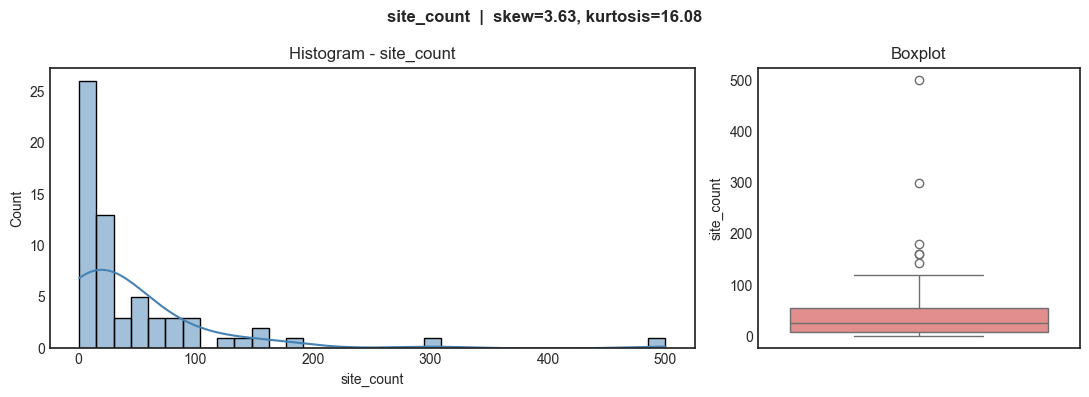

In [208]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [2, 1]})
sns.histplot(df_clean["site_count"].dropna(), bins=34, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Histogram - site_count")
sns.boxplot(y=df_clean["site_count"].dropna(), ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot")
s, k = skew_kurt.loc["site_count", "Skewness"], skew_kurt.loc["site_count", "Kurtosis"]
fig.suptitle(f"site_count  |  skew={s:.2f}, kurtosis={k:.2f}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_count : Removed 72 rows containing non-finite values.


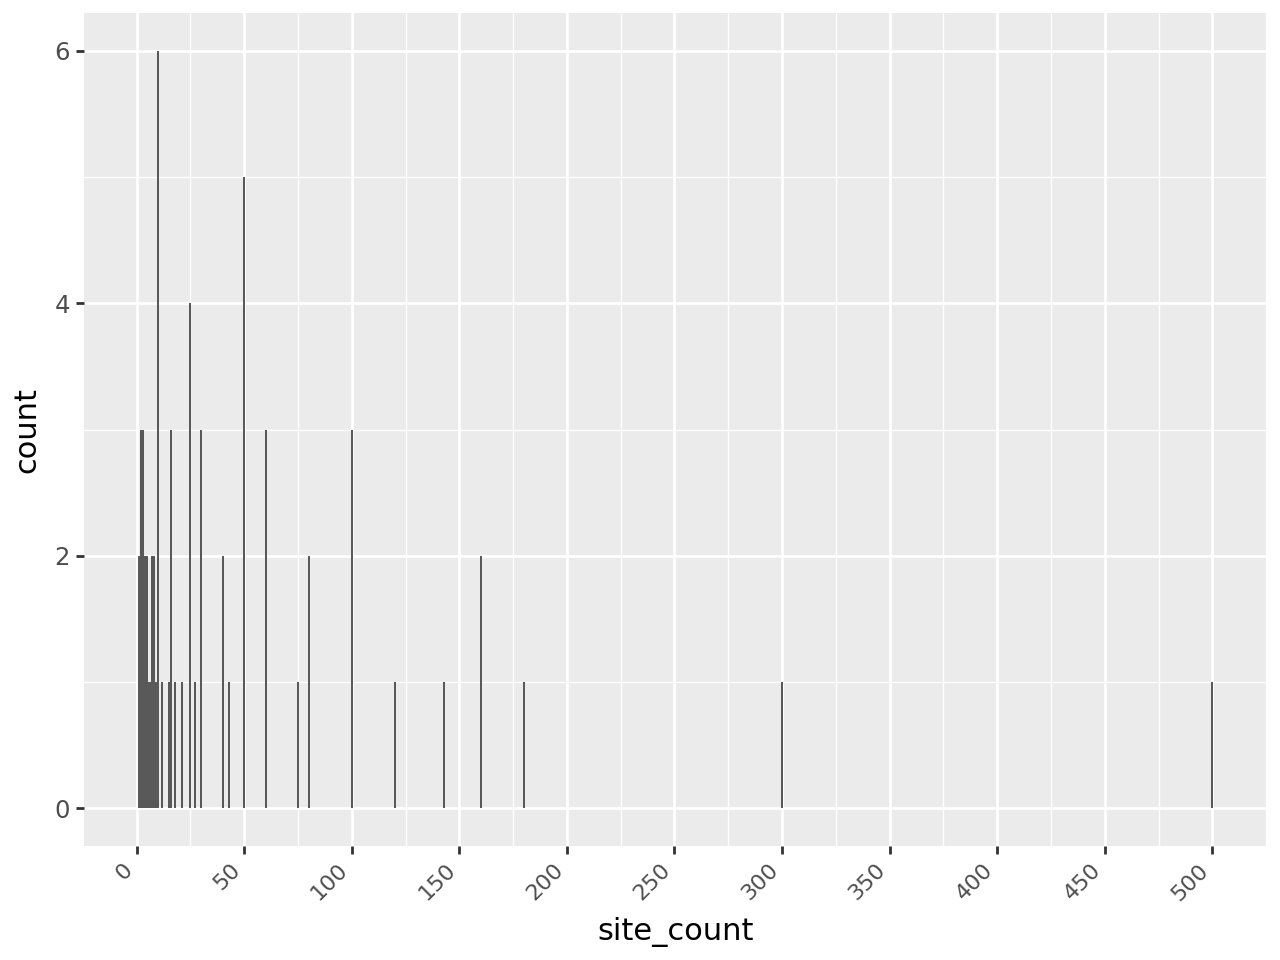

In [209]:
pln.ggplot(df_clean, pln.aes(x='site_count')) \
    + pln.geom_bar(width=1) \
    + pln.scale_x_continuous(breaks=range(0, 550, 50)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

###### *Subject count*

There are 37 missing values. that means:
- The NotebookLM labeling was not good.
- This parameter was not written explicitly in the "golden triangle".

Outliers:
- There are some outliers. I have to check if they are error - comapre with the triangle itself

Conclusions:
- Because the huge amount of missing values I assume that this feature won't be correlative to the target budget.

In [210]:
df_clean["subject_count"].isna().sum()

np.int64(33)

In [211]:
top_n = 10
largest_site_count = df_clean.nlargest(top_n, "subject_count")[
    ["source_file", "pi_name", "proposal_title", "site_count", "subject_count"]
]
display(largest_site_count)

,source_file,pi_name,proposal_title,site_count,subject_count
24,גוי_בנטוב_25.txt,"ד""ר ג'וי בנטוב, פרופ' נוגה כהן, ד""ר דנה לסרי","הערכת קבלת, יישמות, ויעילות התוכנית הבית ספרית...",180.0,14400.0
124,יוסי_פיש_21.txt,פרופ' יוסי הראל-פיש,גורמי חוסן והגנה וגורמי סיכון במרחבים של מערכת...,143.0,12000.0
134,מיכל_אל_יגון_24.txt,פרופ' מיכל אל-יגון,שלומות בהתהוות - פיתוח ויישום מודל הוליסטי לטי...,16.0,8480.0
15,אימאן_גרה_עלוש_23.txt,"ד""ר אימאן גרה עלוש",שחק אותה: פיתוח אוריינות השפה העברית בקרב תלמי...,30.0,5000.0
5,אורלי_ליפקה_25.txt,אורלי ליפקה,בינה מלאכותית יוצרת: מהבנה ליישום במערכת החינו...,10.0,4250.0
84,ראויה_חאיק_25.txt,ראויה חאיק,השפעות בינה מלאכותית יוצרת על תלמידים ועובדי ה...,80.0,3900.0
67,מירי_ימיני_21.txt,Unknown,הוראה ולמידה מרחוק בעתות של ריחוק חברתי - חקר ...,16.0,3820.0
45,יאסר_עואד_24.txt,פרופ' יאסר עואד,רווחה והתנהגות סיכון בקרב תלמידים בתקופת המשבר...,60.0,3000.0
110,רול_25.txt,עדו רול,"אוריינות בינה מלאכותית בגילאי חטה""ב ותיכון - ת...",NaN,3000.0
99,רימאא_דעאס_21.txt,רימאא דעאס,"מנהלים משבר: פיתוח כלי למדידת ""ניהול בזמן משבר""",300.0,2500.0


C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_count : Removed 33 rows containing non-finite values.
C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\positions\position.py:232: PlotnineWarning: position_stack requires non-overlapping x intervals


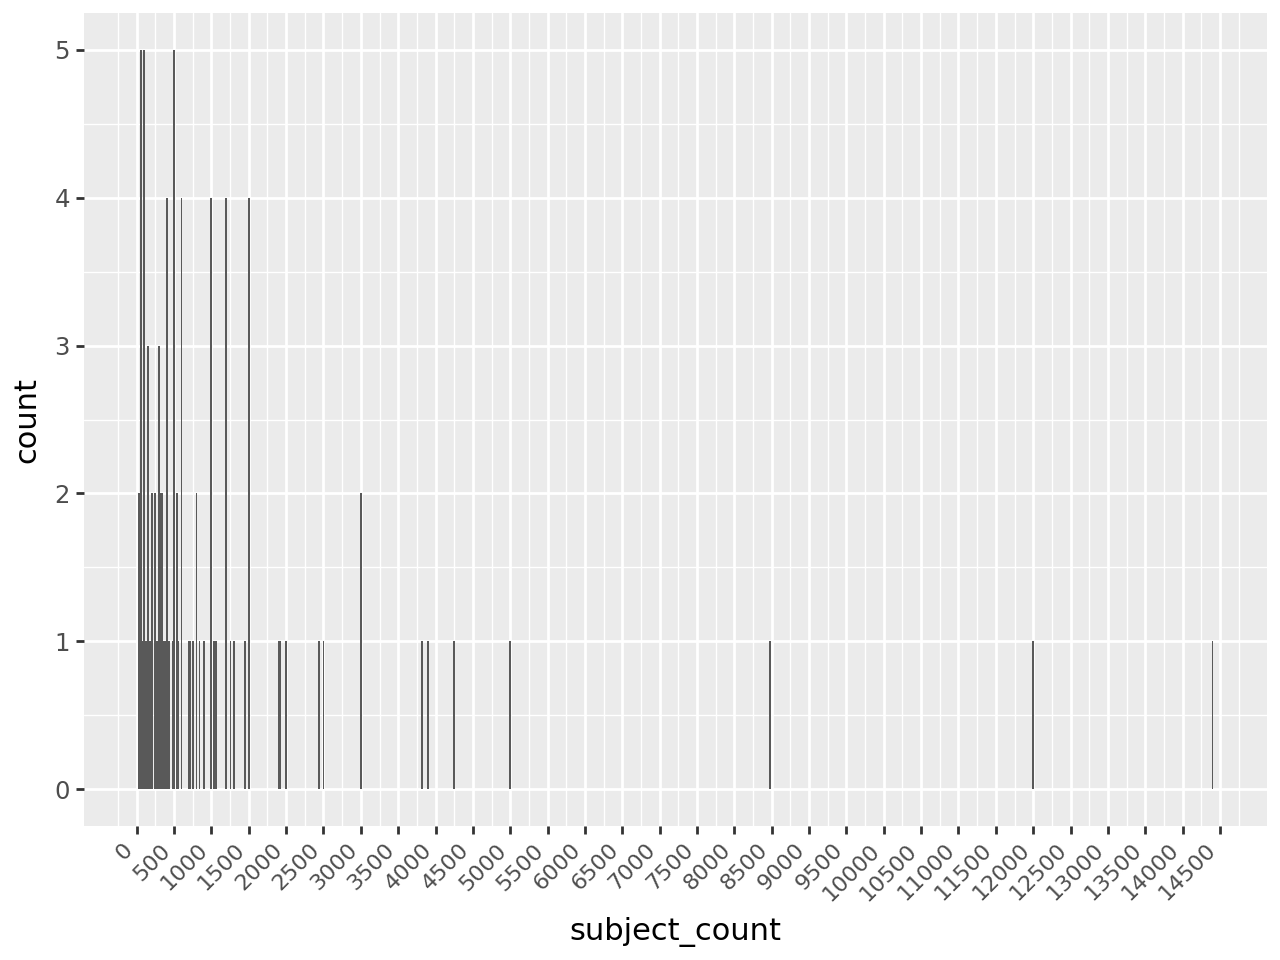

In [212]:
pln.ggplot(df_clean, pln.aes(x='subject_count')) \
    + pln.geom_bar(width=25) \
    + pln.scale_x_continuous(breaks=range(0, 15000, 500)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

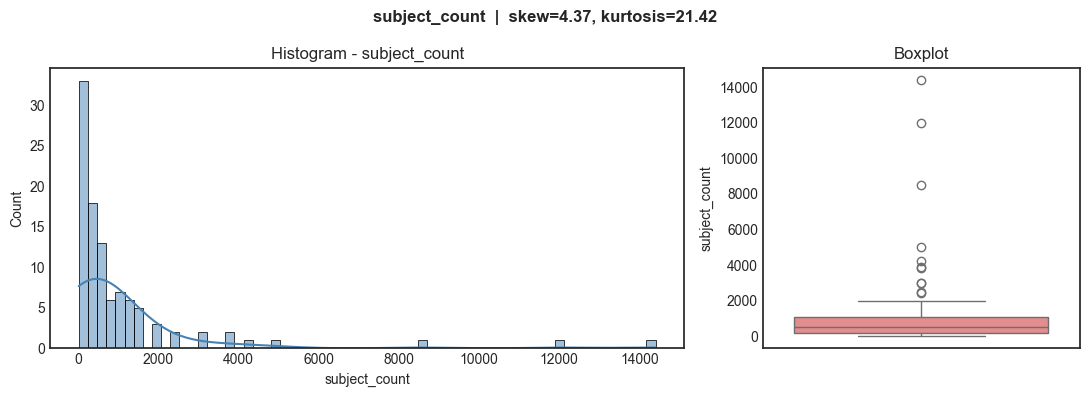

In [213]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [2, 1]})
sns.histplot(df_clean["subject_count"].dropna(), bins=63, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Histogram - subject_count")
sns.boxplot(y=df_clean["subject_count"].dropna(), ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot")
s, k = skew_kurt.loc["subject_count", "Skewness"], skew_kurt.loc["subject_count", "Kurtosis"]
fig.suptitle(f"subject_count  |  skew={s:.2f}, kurtosis={k:.2f}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

###### *Budgeted person work - ⚠*

There are 2 missing values. that means:
- The NotebookLM labeling was pretty good.
- This parameter was not written explicitly in the "golden triangle".

Outliers:
- There are some outliers. I have to check if they are error - comapre with the triangle itself
- The outliers could represent uniqe funded researches.

**⚠ Excluded from training: `budgeted_person_work`**

This feature will be **dropped** before modeling, for two independent reasons:

1. **Leakage risk** — both `budgeted_person_work` and `target_budget` are extracted
   from the same source document (budget breakdown), and correlation analysis below
   shows Pearson r=0.961 between them.
2. **Not available at prediction time** — a researcher estimating a budget at the
   ideation stage does not yet know how much will go to personnel work specifically.
   This value is a *downstream breakdown* of the total budget, not an independent
   input that precedes it — so using it as a predictor doesn't match how the tool
   will actually be used.

In [214]:
df_clean["budgeted_person_work"].isna().sum()

np.int64(2)

In [215]:
top_n = 10
largest_site_count = df_clean.nlargest(top_n, "budgeted_person_work")[
    ["source_file", "pi_name", "proposal_title", "duration_months", "budgeted_person_work"]
]
display(largest_site_count)

,source_file,pi_name,proposal_title,duration_months,budgeted_person_work
108,תומס_גומפל_24.txt,פרופ' תומס גומפל,התמקצעות של מורים להוראה בכיתה ההטרוגנית: יישו...,60.0,848950.0
122,מירי_טל_23.txt,"ד""ר מירי טל סבן",תרומת תהליך ההכשרה הפדגוגי של מחנכות-מטפלות במ...,36.0,762336.0
28,דורית_טובין_25.txt,פרופ' דורית טובין,למידת מורים מקצועית בבית הספר,36.0,748440.0
33,איריס_בן_דוד_הדר_25.txt,איריס בן דוד הדר,הערכת השפעת פיילוט הלמידה המקצועית על התפתחות ...,36.0,715000.0
44,יאיר_זיו_23.txt,"פרופ' יאיר זיו, פרופ' אסתר עדי יפה",הערכת תכניות להכשרה פדגוגית של מחנכים מטפלים ב...,36.0,684000.0
134,מיכל_אל_יגון_24.txt,פרופ' מיכל אל-יגון,שלומות בהתהוות - פיתוח ויישום מודל הוליסטי לטי...,60.0,675830.0
29,דינה_ציבולסקי_25__2_.txt,דינה ציבולסקי,מחקר מלווה לפיילוט המבוסס על מודל חדש ללמידת מ...,36.0,622000.0
17,אבידב_אונגר_בלאו_25.txt,פרופ' אורית אבידב-אונגר ופרופ' אינה בלאו,בחינת יחסי הגומלין בין גורמים מקדמים ומעכבים ל...,36.0,560000.0
110,רול_25.txt,עדו רול,"אוריינות בינה מלאכותית בגילאי חטה""ב ותיכון - ת...",36.0,421800.0
128,ירדן_גליקסמן_24.txt,Unknown,תהליכים נוירופדגוגיים - ממיפוי להתערבות,36.0,421093.0


C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_bin : Removed 2 rows containing non-finite values.


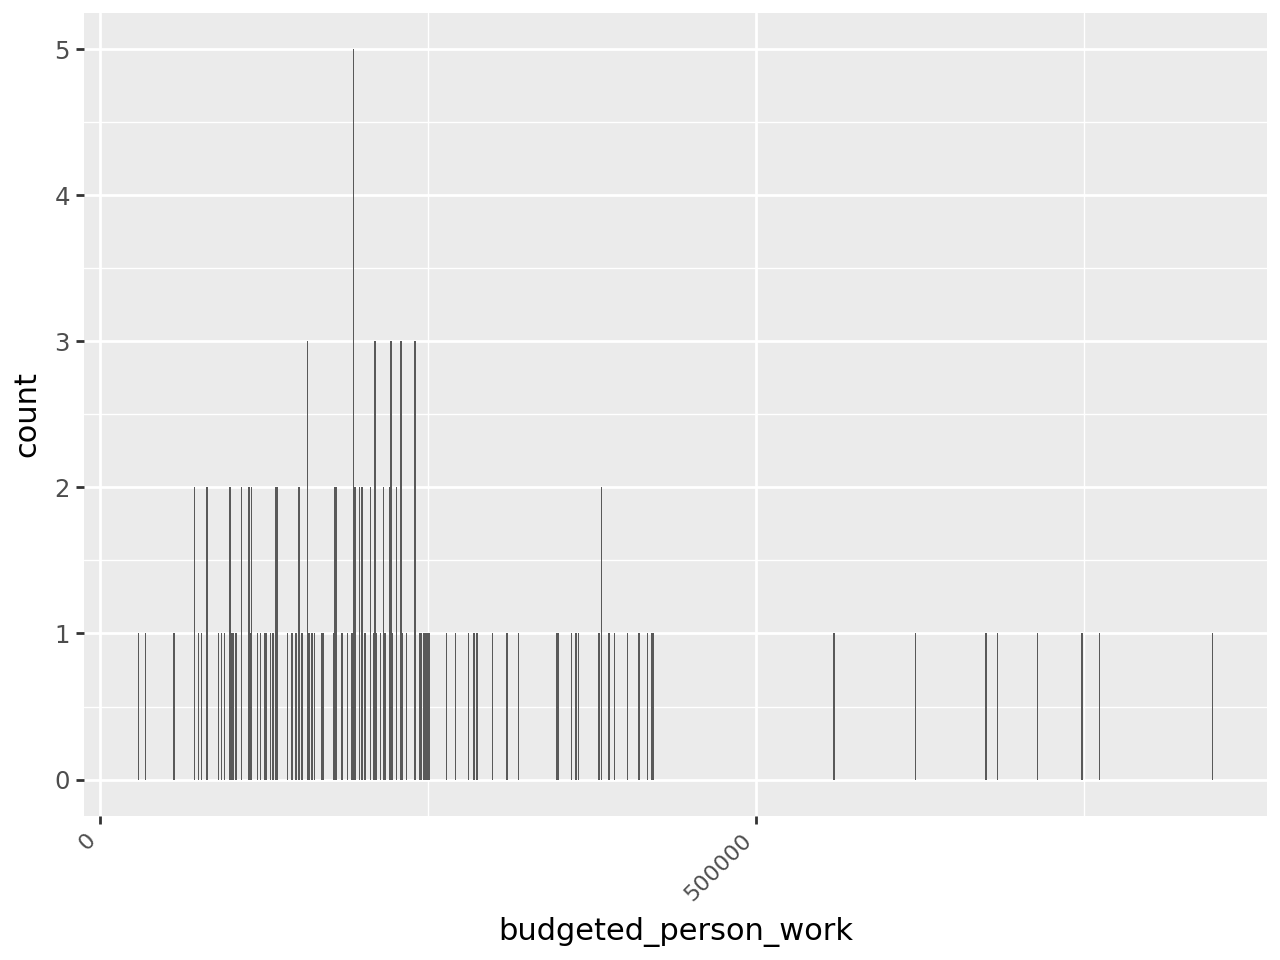

In [216]:
pln.ggplot(df_clean, pln.aes(x='budgeted_person_work')) \
    + pln.geom_histogram(bins=750) \
    + pln.scale_x_continuous(breaks=range(0, 4000000, 500000)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

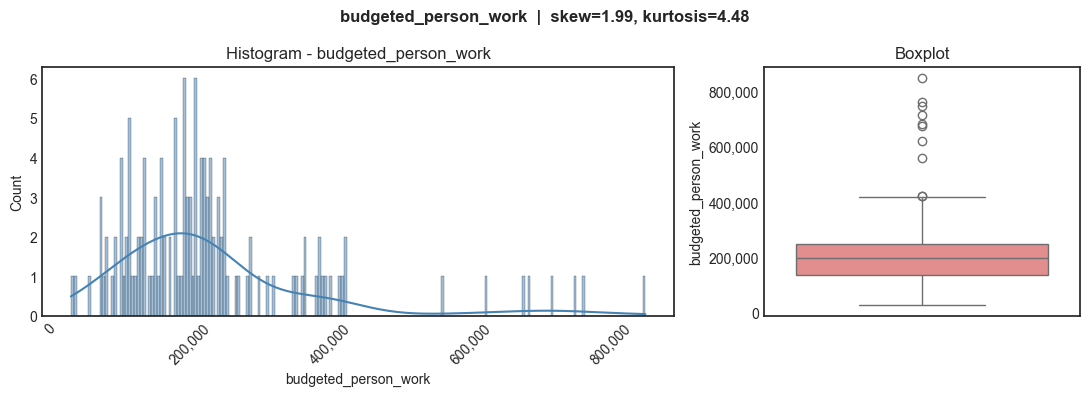

In [217]:
from matplotlib.ticker import FuncFormatter

fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [2, 1]})
sns.histplot(df_clean["budgeted_person_work"].dropna(), bins=200, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Histogram - budgeted_person_work")

# format x-axis ticks as plain numbers with thousands separators (e.g. "1,500,000")
# instead of matplotlib's default scientific/offset notation (e.g. "1.5" with a "1e6" corner label)
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].tick_params(axis="x", rotation=45)   # rotate labels so the longer numbers don't overlap each other

sns.boxplot(y=df_clean["budgeted_person_work"].dropna(), ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:,.0f}"))   # same fix for the boxplot's y-axis

s, k = skew_kurt.loc["budgeted_person_work", "Skewness"], skew_kurt.loc["budgeted_person_work", "Kurtosis"]
fig.suptitle(f"budgeted_person_work  |  skew={s:.2f}, kurtosis={k:.2f}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

###### *Durtion month*

There is 1 missing values. that means:
- The NotebookLM labeling was pretty good.
- This parameter was not written explicitly in the "golden triangle".

Outliers:
- There are some outliers. I have to check if they are error - comapre with the triangle itself
- The outliers could represent uniqe funded researches.

In [218]:
df_clean["duration_months"].isna().sum()

np.int64(1)

C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_count : Removed 1 rows containing non-finite values.


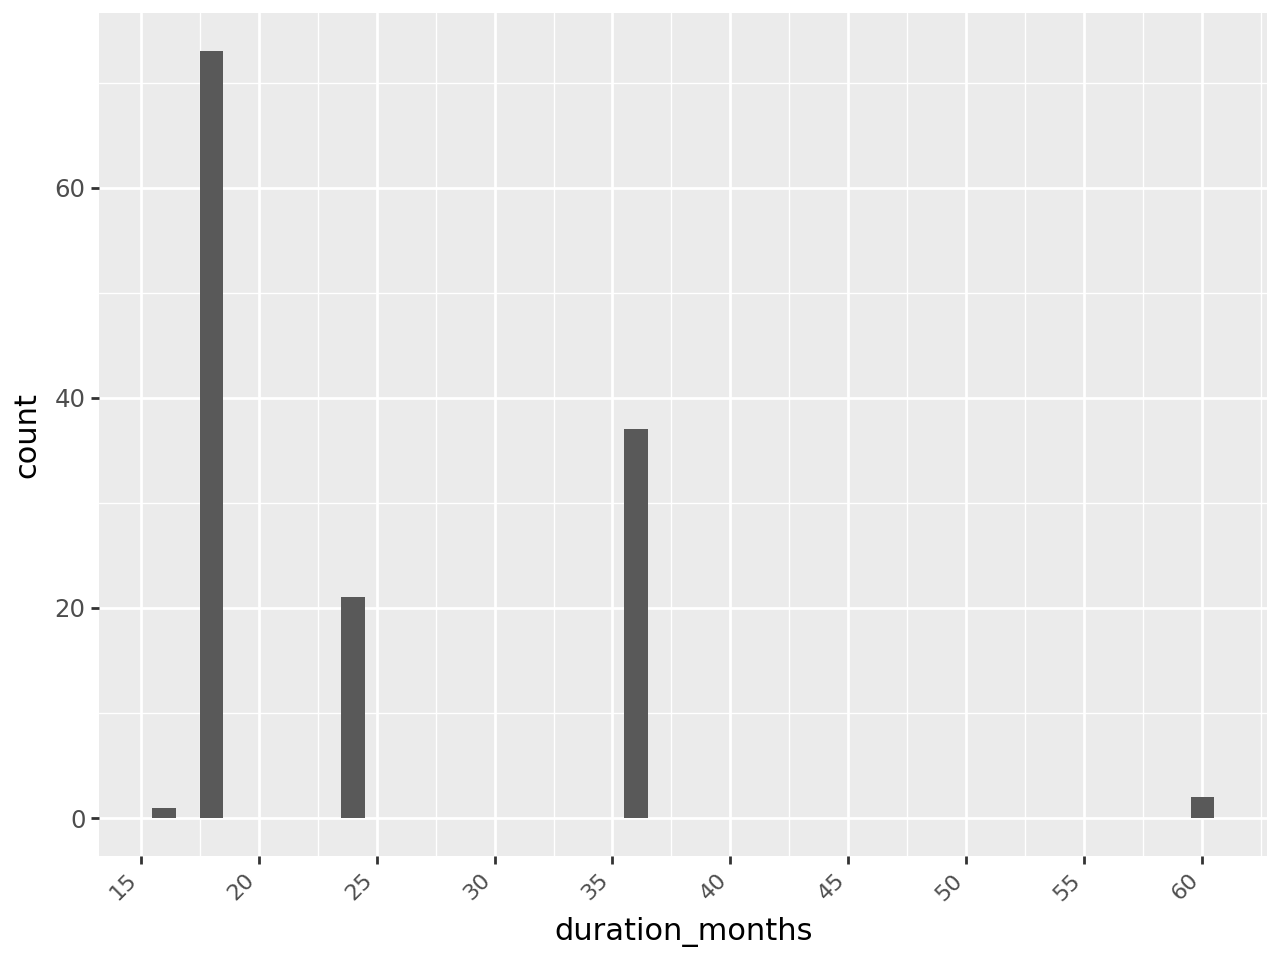

In [219]:
pln.ggplot(df_clean, pln.aes(x='duration_months')) \
    + pln.geom_bar(width=1) \
    + pln.scale_x_continuous(breaks=range(10, 70, 5)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

In [220]:
top_n = 10
largest_site_count = df_clean.nlargest(top_n, "duration_months")[
    ["source_file", "pi_name", "proposal_title", "duration_months"]
]
display(largest_site_count)

,source_file,pi_name,proposal_title,duration_months
108,תומס_גומפל_24.txt,פרופ' תומס גומפל,התמקצעות של מורים להוראה בכיתה ההטרוגנית: יישו...,60.0
134,מיכל_אל_יגון_24.txt,פרופ' מיכל אל-יגון,שלומות בהתהוות - פיתוח ויישום מודל הוליסטי לטי...,60.0
5,אורלי_ליפקה_25.txt,אורלי ליפקה,בינה מלאכותית יוצרת: מהבנה ליישום במערכת החינו...,36.0
6,אורלי_רובינשטיין_24.txt,"אורלי רובינשטיין, נגה כהן","""לדבר את החשיבה"" אימון תפקודים קוגניטביים גבוה...",36.0
15,אימאן_גרה_עלוש_23.txt,"ד""ר אימאן גרה עלוש",שחק אותה: פיתוח אוריינות השפה העברית בקרב תלמי...,36.0
17,אבידב_אונגר_בלאו_25.txt,פרופ' אורית אבידב-אונגר ופרופ' אינה בלאו,בחינת יחסי הגומלין בין גורמים מקדמים ומעכבים ל...,36.0
20,בנטוב25.txt,Unknown,דפוסי שימוש והשפעות בינה מלאכותית יוצרת (במ״י)...,36.0
25,גלי_בנימין_25.txt,"ד""ר גלי בנימין",אימוץ בינה מלאכותית בהוראה: השפעת גורמים ארגונ...,36.0
28,דורית_טובין_25.txt,פרופ' דורית טובין,למידת מורים מקצועית בבית הספר,36.0
29,דינה_ציבולסקי_25__2_.txt,דינה ציבולסקי,מחקר מלווה לפיילוט המבוסס על מודל חדש ללמידת מ...,36.0


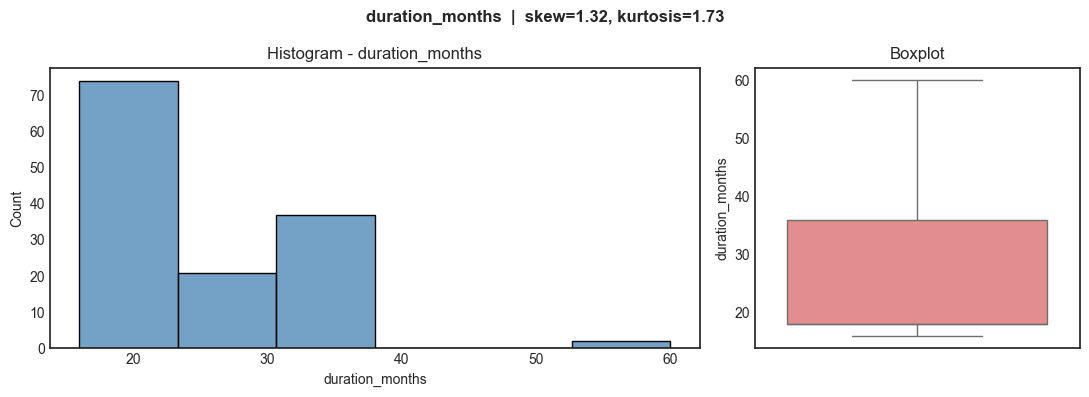

In [221]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [2, 1]})
sns.histplot(df_clean["duration_months"].dropna(), bins=6, kde=False, ax=axes[0], color="steelblue")
axes[0].set_title("Histogram - duration_months")
sns.boxplot(y=df_clean["duration_months"].dropna(), ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot")
s, k = skew_kurt.loc["duration_months", "Skewness"], skew_kurt.loc["duration_months", "Kurtosis"]
fig.suptitle(f"duration_months  |  skew={s:.2f}, kurtosis={k:.2f}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

###### *Target Populations count*

There are 37 missing values. approximatley 20 % of the data. that means:
- The NotebookLM labeling was pretty good.
- This parameter was not written explicitly in the "golden triangle".

Outliers:
- There are some outliers. I have to check if they are error - comapre with the triangle itself
- The outliers could represent uniqe funded researches.

In [222]:
df_clean["target_populations_count"].isna().sum()

np.int64(34)

C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_count : Removed 34 rows containing non-finite values.


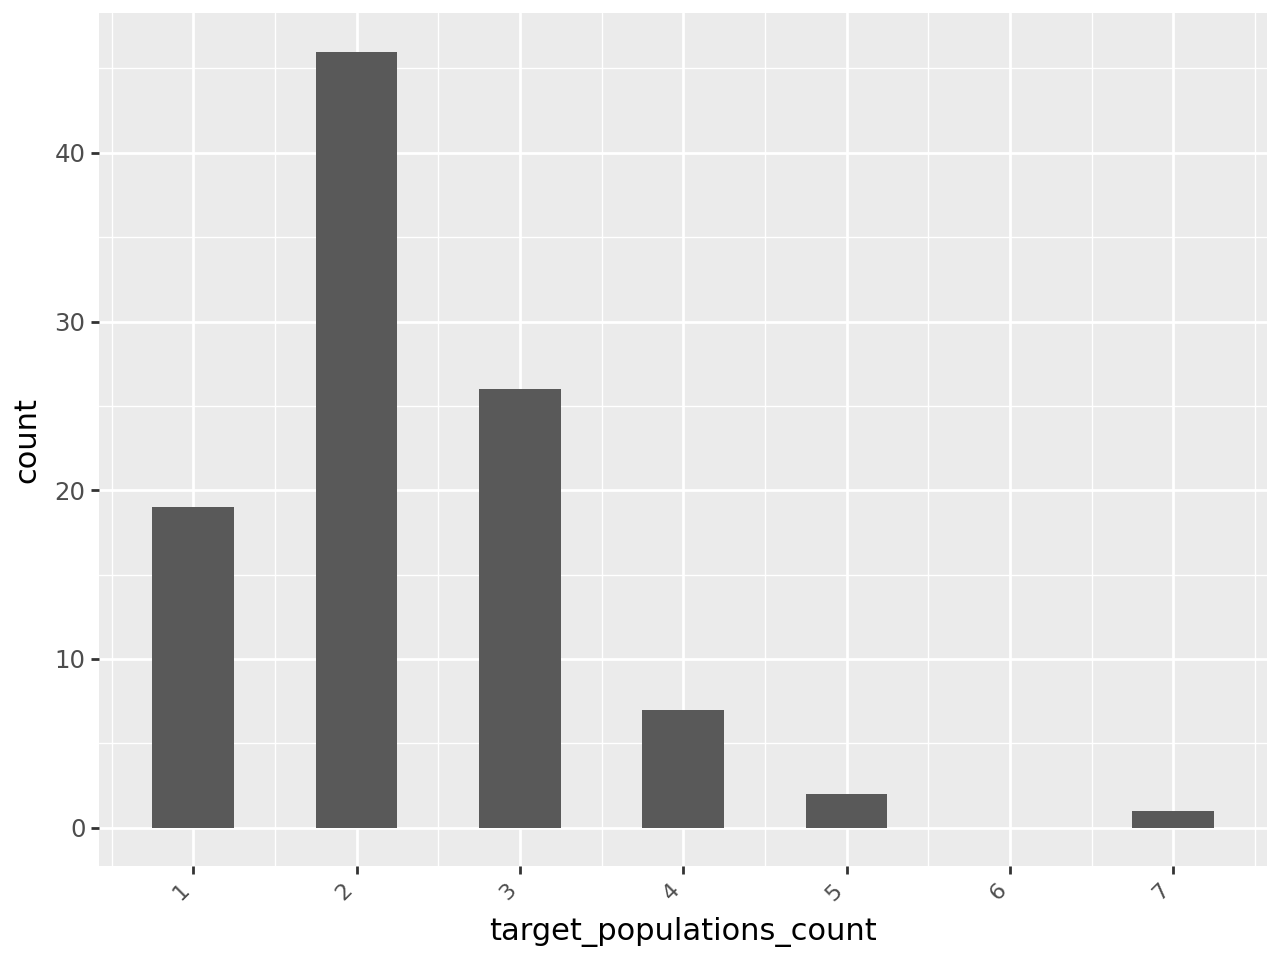

In [223]:
pln.ggplot(df_clean, pln.aes(x='target_populations_count')) \
    + pln.geom_bar(width=0.5) \
    + pln.scale_x_continuous(breaks=range(0, 8, 1)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

In [224]:
top_n = 10
largest_site_count = df_clean.nlargest(top_n, "target_populations_count")[
    ["source_file", "pi_name", "proposal_title", "target_populations_count"]
]
display(largest_site_count)

,source_file,pi_name,proposal_title,target_populations_count
41,טלי_טל_21.txt,פרופ' טלי טל,"""כן, גם בשבילנו"": חינוך בסביבות למידה לא פורמא...",7.0
16,אבו_נסרא_24.txt,"ד""ר מוחמד אבו נסרה",משאבים לחוסן של מורים ומנהלים ערבים בצל משבר מ...,5.0
82,קורץ_אמזלג_אבידב_25.txt,פרופ' גילה קורץ,"ממשקים, תפיסות והשפעות של שימוש בבינה מלאכותית...",5.0
17,אבידב_אונגר_בלאו_25.txt,פרופ' אורית אבידב-אונגר ופרופ' אינה בלאו,בחינת יחסי הגומלין בין גורמים מקדמים ומעכבים ל...,4.0
21,ברוריה_עדיני_21.txt,"ד""ר ברוריה עדיני",חוסן פונקציונלי של בתי הספר: הפקת לקחים ממגפת ...,4.0
56,זהבית_גרוס_21.txt,פרופ' זהבית גרוס,מאפייני פעילות החינוך הבלתי פורמאלי בבית הספר ...,4.0
78,נעמי_שרויאר_21.txt,פרופ' נעמי שרויאר,"יישום תוכנית הכנה לחיי עבודה (בלשנ""א) לבני נוע...",4.0
81,צמרת_ריקון_24.txt,"ד""ר צמרת ריקון",חוויות הורים יהודים וערבים שקיבלו הוראת פינוי ...,4.0
122,מירי_טל_23.txt,"ד""ר מירי טל סבן",תרומת תהליך ההכשרה הפדגוגי של מחנכות-מטפלות במ...,4.0
124,יוסי_פיש_21.txt,פרופ' יוסי הראל-פיש,גורמי חוסן והגנה וגורמי סיכון במרחבים של מערכת...,4.0


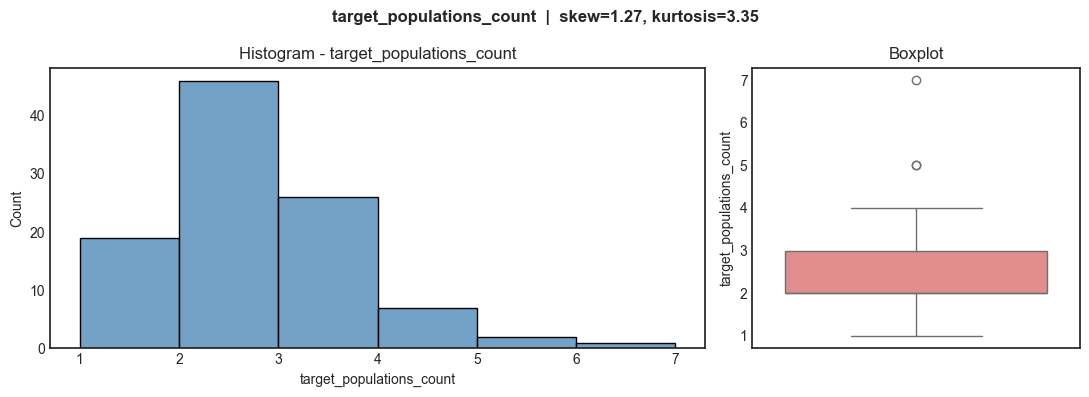

In [225]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [2, 1]})
sns.histplot(df_clean["target_populations_count"].dropna(), bins=6, kde=False, ax=axes[0], color="steelblue")
axes[0].set_title("Histogram - target_populations_count")
sns.boxplot(y=df_clean["target_populations_count"].dropna(), ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot")
s, k = skew_kurt.loc["target_populations_count", "Skewness"], skew_kurt.loc["target_populations_count", "Kurtosis"]
fig.suptitle(f"target_populations_count  |  skew={s:.2f}, kurtosis={k:.2f}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

###### *Data waves count*

There are 51 missing values. that means:
- The NotebookLM labeling was not good.
- This parameter was not written explicitly in the "golden triangle".

Outliers:
- There are some outliers. I have to check if they are error - comapre with the triangle itself

Conclusions:
- Because the huge amount of missing values I assume that this feature won't be correlative to the target budget.

In [226]:
df_clean["data_waves_count"].isna().sum()

np.int64(50)

In [227]:
top_n = 10
largest_site_count = df_clean.nlargest(top_n, "data_waves_count")[
    ["source_file", "pi_name", "proposal_title", "data_waves_count"]
]
display(largest_site_count)

,source_file,pi_name,proposal_title,data_waves_count
134,מיכל_אל_יגון_24.txt,פרופ' מיכל אל-יגון,שלומות בהתהוות - פיתוח ויישום מודל הוליסטי לטי...,5.0
34,אלט_ועובד_25.txt,"דורית אלט, אורית עובד",פיתוח מדדי SEL-AI: למידה חברתית-רגשית של מורים...,4.0
38,בנטוב_25.txt,Unknown,חיזוק החוסן של תלמידים בגילאי 13-18 באמצעות הת...,4.0
65,עינת_הד_24.txt,פרופ' עינת הד מצויינים,פרקטיקות הוראה היכולות למנוע מעגלי כישלון ולמנ...,4.0
130,כרמל_אלטמן_21.txt,"דר' כרמית אלטמן, דר' איריס הדר",אי שיוויון ופערים ופדגוגיה רלוונטית תרבות,4.0
5,אורלי_ליפקה_25.txt,אורלי ליפקה,בינה מלאכותית יוצרת: מהבנה ליישום במערכת החינו...,3.0
7,אורלי_שפירא_21.txt,אורלי שפירא,הערכת חוסר היציבות במסגרות לגיל הרך על רקע מגי...,3.0
17,אבידב_אונגר_בלאו_25.txt,פרופ' אורית אבידב-אונגר ופרופ' אינה בלאו,בחינת יחסי הגומלין בין גורמים מקדמים ומעכבים ל...,3.0
20,בנטוב25.txt,Unknown,דפוסי שימוש והשפעות בינה מלאכותית יוצרת (במ״י)...,3.0
24,גוי_בנטוב_25.txt,"ד""ר ג'וי בנטוב, פרופ' נוגה כהן, ד""ר דנה לסרי","הערכת קבלת, יישמות, ויעילות התוכנית הבית ספרית...",3.0


C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_count : Removed 50 rows containing non-finite values.


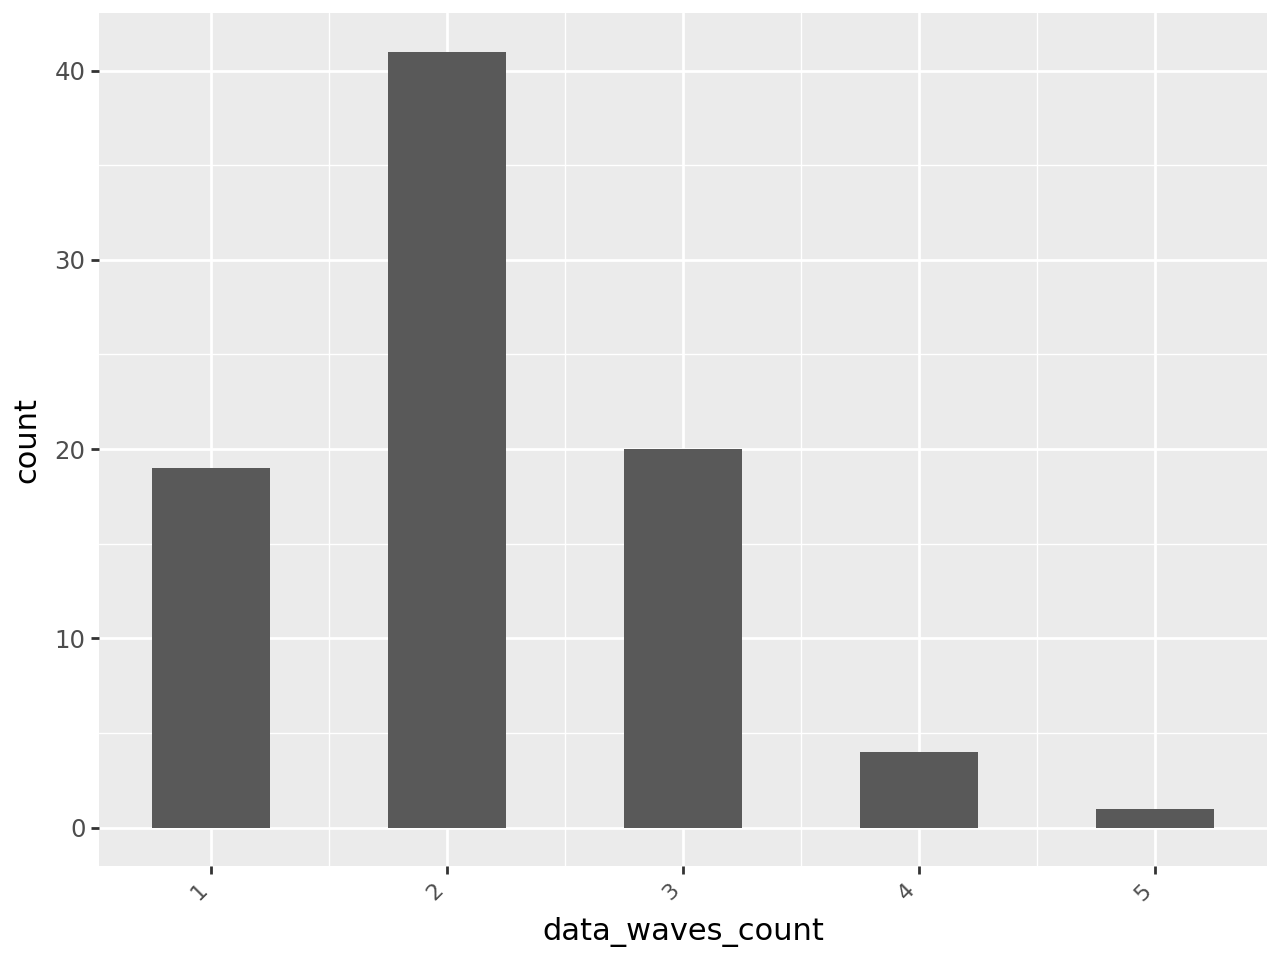

In [228]:
pln.ggplot(df_clean, pln.aes(x='data_waves_count')) \
    + pln.geom_bar(width=0.5) \
    + pln.scale_x_continuous(breaks=range(0, 8, 1)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

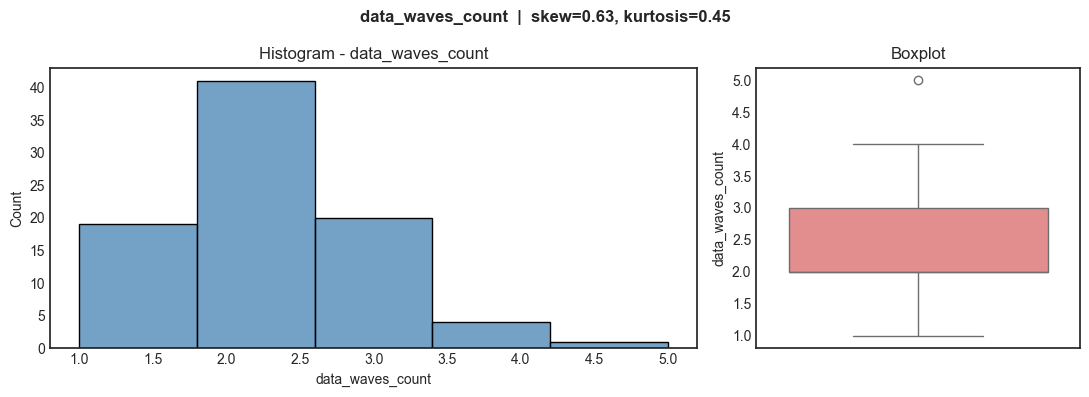

In [229]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [2, 1]})
sns.histplot(df_clean["data_waves_count"].dropna(), bins=5, kde=False, ax=axes[0], color="steelblue")
axes[0].set_title("Histogram - data_waves_count")
sns.boxplot(y=df_clean["data_waves_count"].dropna(), ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot")
s, k = skew_kurt.loc["data_waves_count", "Skewness"], skew_kurt.loc["data_waves_count", "Kurtosis"]
fig.suptitle(f"data_waves_count  |  skew={s:.2f}, kurtosis={k:.2f}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

###### *Data languages count*

There are 56 missing values. approximatley 20 % of the data. that means:
- The NotebookLM labeling was pretty good.
- This parameter was not written explicitly in the "golden triangle".

Outliers:
- There are some outliers. I have to check if they are error - comapre with the triangle itself
- The outliers could represent uniqe funded researches.

In [230]:
df_clean["languages_count"].isna().sum()

np.int64(56)

In [231]:
top_n = 10
largest_site_count = df_clean.nlargest(top_n, "languages_count")[
    ["source_file", "pi_name", "proposal_title", "languages_count"]
]
display(largest_site_count)

,source_file,pi_name,proposal_title,languages_count
0,אורטל_סלובדין_21.txt,פרופ' אורטל סלובודין,"הארון הכפול: נוער להט""בי במערכת החינוך הערבית ...",3.0
6,אורלי_רובינשטיין_24.txt,"אורלי רובינשטיין, נגה כהן","""לדבר את החשיבה"" אימון תפקודים קוגניטביים גבוה...",3.0
17,אבידב_אונגר_בלאו_25.txt,פרופ' אורית אבידב-אונגר ופרופ' אינה בלאו,בחינת יחסי הגומלין בין גורמים מקדמים ומעכבים ל...,3.0
45,יאסר_עואד_24.txt,פרופ' יאסר עואד,רווחה והתנהגות סיכון בקרב תלמידים בתקופת המשבר...,3.0
92,פאידה_נסר_24.txt,פאדיה נאסר-אבו אלהיג'א,שלומות ורווחה רגשית בקרב צוותי הוראה וניהול בח...,3.0
124,יוסי_פיש_21.txt,פרופ' יוסי הראל-פיש,גורמי חוסן והגנה וגורמי סיכון במרחבים של מערכת...,3.0
1,אורטל_סלובדין_24.txt,"פרופ' אורטל סלובודין, פרופ' הללי פינסון",חסמים באיתור ובהשתתפות תלמידים/ות מהחברה הבדוא...,2.0
2,אורי_כהן_21.txt,אורי כהן,יחסי גומלין בין מנהל החינוך ברשות המקומית לבתי...,2.0
13,איילון_25.txt,Unknown,לילו: סימולציית שיחה מבוססת מודלי שפה גדולים ל...,2.0
15,אימאן_גרה_עלוש_23.txt,"ד""ר אימאן גרה עלוש",שחק אותה: פיתוח אוריינות השפה העברית בקרב תלמי...,2.0


C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_count : Removed 56 rows containing non-finite values.


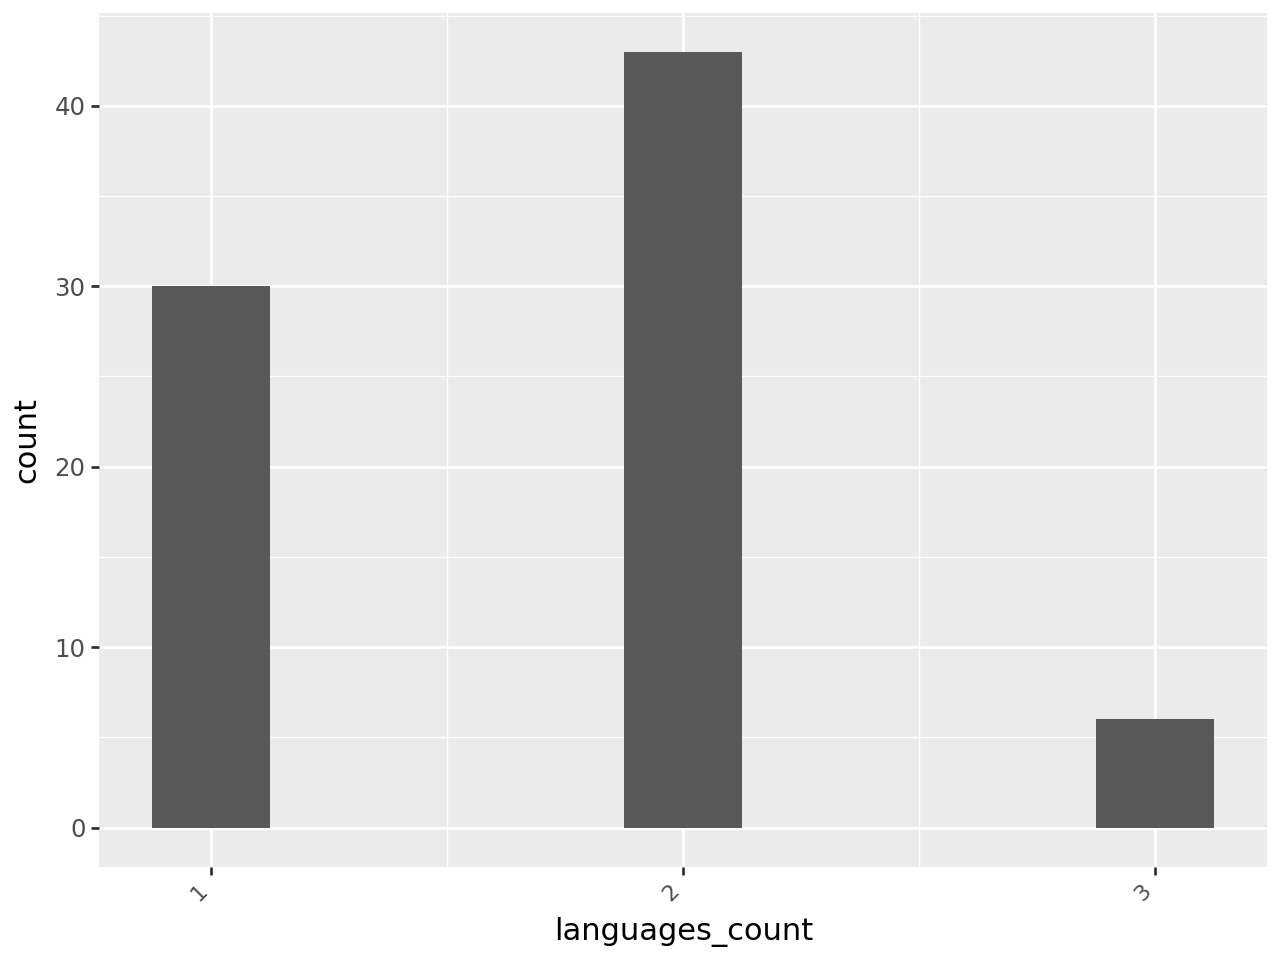

In [232]:
pln.ggplot(df_clean, pln.aes(x='languages_count')) \
    + pln.geom_bar(width=0.25) \
    + pln.scale_x_continuous(breaks=range(0, 8, 1)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

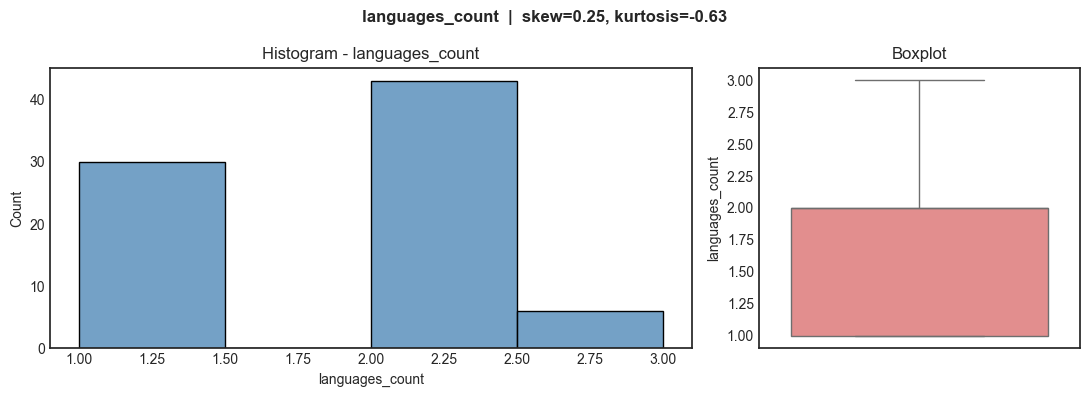

In [233]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [2, 1]})
sns.histplot(df_clean["languages_count"].dropna(), bins=4, kde=False, ax=axes[0], color="steelblue")
axes[0].set_title("Histogram - languages_count")
sns.boxplot(y=df_clean["languages_count"].dropna(), ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot")
s, k = skew_kurt.loc["languages_count", "Skewness"], skew_kurt.loc["languages_count", "Kurtosis"]
fig.suptitle(f"languages_count  |  skew={s:.2f}, kurtosis={k:.2f}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

###### *Taret budget*

`target_budget` takes suspiciously round values (200,000 / 300,000 / 500,000 /
1,000,000 / 4,000,000), suggesting these are fixed call-defined budget caps rather
than a truly continuous variable. Combined with the extreme skew (4.48) and
kurtosis (19.5), this motivates framing the problem as **ordinal classification**
over a small number of budget ranges, instead of regression. Next steps:
1. Run `df_clean['target_budget'].value_counts().sort_index()` on the ≤1M-scoped data.
2. If few unique values exist, use them directly as classes.
3. Otherwise, build bins using quantile or log-spaced cuts (not fixed-width),
   since the mass is concentrated at the low end (25%=300K, median=300K, 75%=500K).

There are 0 missing values. that means:
- The NotebookLM labeling was pretty good.

Outliers:
- There are some outliers. I have to check if they are error - comapre with the triangle itself
- The outliers could represent uniqe funded researches.

In [234]:
df_clean["target_budget"].isna().sum()

np.int64(0)

This feature has only 8 options.

In [300]:
df_clean["target_budget"].value_counts()

target_budget
300000     60
500000     29
200000     17
250000     16
1000000     5
950000      4
350000      3
400000      1
Name: count, dtype: int64

In [301]:
df_clean["target_budget"].value_counts(normalize=True)

target_budget
300000     0.444444
500000     0.214815
200000     0.125926
250000     0.118519
1000000    0.037037
950000     0.029630
350000     0.022222
400000     0.007407
Name: proportion, dtype: float64

In [235]:
top_n = 10
largest_site_count = df_clean.nlargest(top_n, "target_budget")[
    ["source_file", "pi_name", "proposal_title", "target_budget"]
]
display(largest_site_count)

,source_file,pi_name,proposal_title,target_budget
44,יאיר_זיו_23.txt,"פרופ' יאיר זיו, פרופ' אסתר עדי יפה",הערכת תכניות להכשרה פדגוגית של מחנכים מטפלים ב...,1000000
77,ניצה_דוידוביץ_23.txt,פרופ' ניצה דוידוביץ',פיתוח קריירה בטיפול בפעוטות במעונות היום: מעיס...,1000000
108,תומס_גומפל_24.txt,פרופ' תומס גומפל,התמקצעות של מורים להוראה בכיתה ההטרוגנית: יישו...,1000000
122,מירי_טל_23.txt,"ד""ר מירי טל סבן",תרומת תהליך ההכשרה הפדגוגי של מחנכות-מטפלות במ...,1000000
134,מיכל_אל_יגון_24.txt,פרופ' מיכל אל-יגון,שלומות בהתהוות - פיתוח ויישום מודל הוליסטי לטי...,1000000
17,אבידב_אונגר_בלאו_25.txt,פרופ' אורית אבידב-אונגר ופרופ' אינה בלאו,בחינת יחסי הגומלין בין גורמים מקדמים ומעכבים ל...,950000
28,דורית_טובין_25.txt,פרופ' דורית טובין,למידת מורים מקצועית בבית הספר,950000
29,דינה_ציבולסקי_25__2_.txt,דינה ציבולסקי,מחקר מלווה לפיילוט המבוסס על מודל חדש ללמידת מ...,950000
33,איריס_בן_דוד_הדר_25.txt,איריס בן דוד הדר,הערכת השפעת פיילוט הלמידה המקצועית על התפתחות ...,950000
5,אורלי_ליפקה_25.txt,אורלי ליפקה,בינה מלאכותית יוצרת: מהבנה ליישום במערכת החינו...,500000


Target budget distribution under milion ILS

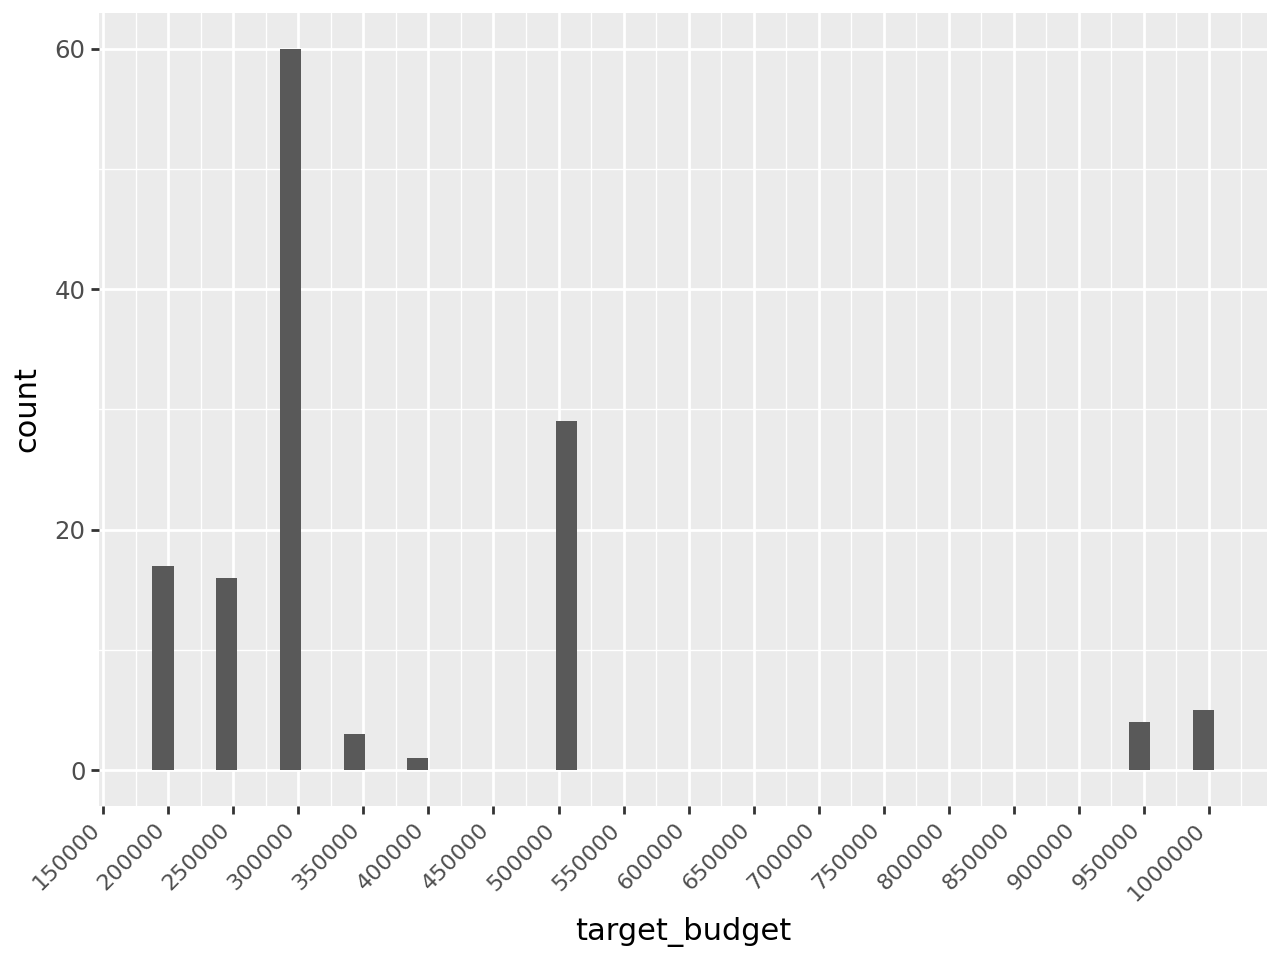

In [236]:
pln.ggplot(df_clean[df_clean['target_budget'] <= 1000000], pln.aes(x='target_budget')) \
    + pln.geom_histogram(bins=50) \
    + pln.scale_x_continuous(breaks=range(0, 1100000, 50000)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

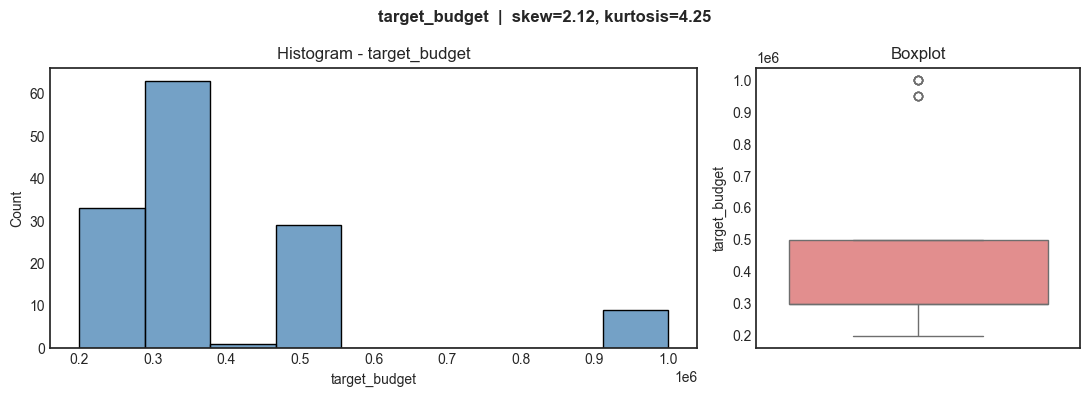

In [237]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [2, 1]})
sns.histplot(df_clean["target_budget"].dropna(), bins=9, kde=False, ax=axes[0], color="steelblue")
axes[0].set_title("Histogram - target_budget")
sns.boxplot(y=df_clean["target_budget"].dropna(), ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot")
s, k = skew_kurt.loc["target_budget", "Skewness"], skew_kurt.loc["target_budget", "Kurtosis"]
fig.suptitle(f"target_budget  |  skew={s:.2f}, kurtosis={k:.2f}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

##### *insights*

###### *Input range binning - continuous variables (for UX + model robustness)*

For the end-user tool, exact continuous values (e.g. "how many subjects exactly")
are unrealistic to ask at the ideation stage. Plan: convert the continuous input
features (`site_count`, `subject_count`, `duration_months`,
`target_populations_count`, `data_waves_count`, `languages_count`) into a small
number of user-friendly ranges, including an explicit "not yet decided" option
where relevant. Bin edges should be chosen on a log/quantile scale per feature
(given the skew already measured above), not equal-width, to keep bins reasonably
populated. **Critical**: the same bin edges used for training must be reused as the
UI's selectable ranges, to avoid train/serve mismatch.

###### Proposed bins per feature

**`duration_months`** (skew=1.32, MAD=0 — most values cluster on a few round numbers)
min=16, 25%=18, median=18, 75%=36, max=60. The distribution concentrates on conventional
project lengths rather than spreading continuously, so bins follow typical research
durations instead of generic quantiles:
- ≤ 18 months
- 19–36 months
- 37–60 months
- > 60 months (if present)

**`site_count`** (skew=3.63, **only 63/135 non-missing — 53% missing**)
min=1, 25%=8, 50%=25, 75%=55, max=500. Spans several orders of magnitude → log-spaced bins:
- 1 site
- 2–10 sites
- 11–50 sites
- > 50 sites
- **"Not yet decided"** — a separate category rather than mean/median imputation. Given the
  high missingness here, this ties back to the NotebookLM labeling audit: if the missingness
  reflects a genuine "not decided yet" state (rather than an extraction failure), this bin
  keeps the feature usable instead of forcing its exclusion.

**`subject_count`** (skew=4.37, the most skewed feature; 102/135 non-missing)
min=25, 25%=156, 50%=490, 75%=1,057, max=14,400. Also spans orders of magnitude → log-spaced:
- ≤ 100 subjects
- 101–500 subjects
- 501–2,000 subjects
- > 2,000 subjects
- "Not yet decided"

**`target_populations_count`** (skew=1.27, 101/135 non-missing)
min=1, 25%=2, 50%=2, 75%=3, max=7 — a small, tight integer range, no log transform needed:
- 1 target population
- 2 target populations
- 3+ target populations
- "Not yet decided"

**`data_waves_count`** (skew=0.63, **85/135 non-missing — 37% missing**)
min=1, 25%=2, 50%=2, 75%=3, max=5 — similarly small/tight scale:
- 1 data collection wave
- 2 waves
- 3+ waves
- "Not yet decided"

**`languages_count`** (skew=0.25, the most symmetric feature, but **only 79/135 non-missing — 41% missing**)
min=1, 25%=1, 50%=2, 75%=2, max=3 — narrow range:
- 1 language
- 2 languages
- 3+ languages
- "Not yet decided"

**`target_budget`** (target variable — not an input feature)
`value_counts()` on the scoped data (≤1,000,000 NIS) confirms the target is **fully discrete**:
only 8 unique values appear across all 135 rows (200k, 250k, 300k, 350k, 400k, 500k, 950k,
1,000,000), with two dominant tiers (300k: 44%, 500k: 22%) and several near-singleton values
(350k: n=3, 400k: n=1). A naive quantile or fixed-width cut would either ignore this
structure or create unstable, near-empty classes unsuitable for stratified splitting.

Bins are instead placed at the **natural gaps** in the observed values — in particular the
large gap between 500,000 and 950,000, where no value exists at all:

| Bin | Underlying values | Rows |
|---|---|---|
| 200,000–250,000 NIS | 200k, 250k | 33 |
| 300,000 NIS | 300k | 60 |
| 350,000–500,000 NIS | 350k, 400k, 500k | 33 |
| 900,000–1,000,000 NIS | 950k, 1,000,000 | 9 |

This merges the near-singleton tiers (350k, 400k) into a wider neighboring bin so no class is
left with a single training row, while keeping the split data-driven (aligned to real gaps)
rather than arbitrary. The top bin (n=9) remains the smallest class and should be watched
during model evaluation (e.g. confusion matrix per class) even after merging.

##### Methodological note
For the three features with the highest missingness (`site_count`, `data_waves_count`,
`languages_count`), the "Not yet decided" bin is not just a UX convenience — it is what lets
these features stay in training without biasing the model through artificial imputation
(mean/median), provided the NotebookLM audit confirms the missingness is genuine rather than
an extraction failure.

###### *Bining*

In [303]:
df_binned = df_clean.copy()

In [324]:
binning_config = {
    "duration_months": (
        [-np.inf, 18, np.inf],
        ["≤18 months", ">19 months"]
    ),
    "site_count": (
        [-np.inf, 10, 50, np.inf],
        ["1–10 sites", "11–50 sites", ">50 sites"]
    ),
    "subject_count": (
        [-np.inf, 100, 500, 2000, np.inf],
        ["≤100 subjects", "101–500 subjects", "501–2,000 subjects", ">2,000 subjects"]
    ),
    "target_populations_count": (
        [-np.inf, 1, 2, np.inf],
        ["1 population", "2 populations", "3+ populations"]
    ),
    "data_waves_count": (
        [-np.inf, 1, 2, np.inf],
        ["1 wave", "2 waves", "3+ waves"]
    ),
    "languages_count": (
        [-np.inf, 1, 2, np.inf],
        ["1 language", "2 languages", "3+ languages"]
    ),
    # Target variable — edges placed at the natural gaps between the 8 observed
    # discrete values (confirmed via value_counts() on the scoped data), not at
    # arbitrary round-number cuts. This merges near-singleton tiers (350k, 400k)
    # into a wider bin to avoid unstable/empty classes in training.
    "target_budget": (
        [-np.inf, 275_000, 325_000, 700_000, np.inf],
        ["200,000–250,000 NIS", "300,000 NIS", "350,000–500,000 NIS", "900,000–1,000,000 NIS"]
    ),
}

In [325]:
# apply binning to all features (input features get "Not yet decided" for missing values; target_budget should have no missing values by this point in the pipeline, so it's skipped)

INPUT_FEATURES_WITH_MISSING_OPTION = [
    "duration_months", "site_count", "subject_count",
    "target_populations_count", "data_waves_count", "languages_count"
]
for feature, (edges, labels) in binning_config.items():
    binned_col = f"{feature}_bin"

    df_binned[binned_col] = pd.cut(
        df_binned[feature],
        bins=edges,
        labels=labels,
        right=True
    )

    if feature in INPUT_FEATURES_WITH_MISSING_OPTION:
        df_binned[binned_col] = df_binned[binned_col].cat.add_categories(["Not yet decided"])
        df_binned[binned_col] = df_binned[binned_col].fillna("Not yet decided")
        ordered_categories = labels + ["Not yet decided"]
    else:
        # target_budget: verify there are no missing values before proceeding
        assert df_binned[binned_col].isna().sum() == 0, \
            f"{feature} has missing values — resolve before binning the target"
        ordered_categories = labels

    df_binned[binned_col] = df_binned[binned_col].cat.reorder_categories(
        ordered_categories, ordered=True
    )



In [326]:
MIN_HEALTHY_BIN_SIZE = 5

for feature in binning_config:
    binned_col = f"{feature}_bin"
    counts = df_binned[binned_col].value_counts(sort=False)
    print(f"\n{binned_col}:")
    print(counts)

    small_bins = counts[counts < MIN_HEALTHY_BIN_SIZE]
    if not small_bins.empty:
        print(f"  ⚠ small/empty bins (<{MIN_HEALTHY_BIN_SIZE} rows): {dict(small_bins)}")


duration_months_bin:
duration_months_bin
≤18 months         74
>19 months         60
Not yet decided     1
Name: count, dtype: int64
  ⚠ small/empty bins (<5 rows): {'Not yet decided': np.int64(1)}

site_count_bin:
site_count_bin
1–10 sites         24
11–50 sites        23
>50 sites          16
Not yet decided    72
Name: count, dtype: int64

subject_count_bin:
subject_count_bin
≤100 subjects         20
101–500 subjects      36
501–2,000 subjects    35
>2,000 subjects       11
Not yet decided       33
Name: count, dtype: int64

target_populations_count_bin:
target_populations_count_bin
1 population       19
2 populations      46
3+ populations     36
Not yet decided    34
Name: count, dtype: int64

data_waves_count_bin:
data_waves_count_bin
1 wave             19
2 waves            41
3+ waves           25
Not yet decided    50
Name: count, dtype: int64

languages_count_bin:
languages_count_bin
1 language         30
2 languages        43
3+ languages        6
Not yet decided    56
Name

Sanity check

In [327]:
df_binned.info()

<class 'pandas.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   source_file                   135 non-null    str     
 1   call_title                    135 non-null    str     
 2   pi_name                       135 non-null    str     
 3   proposal_title                135 non-null    str     
 4   duration_months               134 non-null    float64 
 5   site_count                    63 non-null     float64 
 6   subject_count                 102 non-null    float64 
 7   target_populations_count      101 non-null    float64 
 8   data_waves_count              85 non-null     float64 
 9   has_surveys                   134 non-null    float64 
 10  has_interviews                134 non-null    float64 
 11  has_focus_groups              133 non-null    float64 
 12  has_observations              133 non-null    float64 
 13  h

#### *Binary Variables*

##### *Has surveys*

Cardinality:
- almost all of the triangles use surveys. that means that probably there will be no strong correlation to the target budget.

In [238]:
df_clean["has_surveys"].value_counts()

has_surveys
1.0    113
0.0     21
Name: count, dtype: int64

In [239]:
df_clean["has_surveys"].isna().sum()

np.int64(1)

C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_count : Removed 1 rows containing non-finite values.


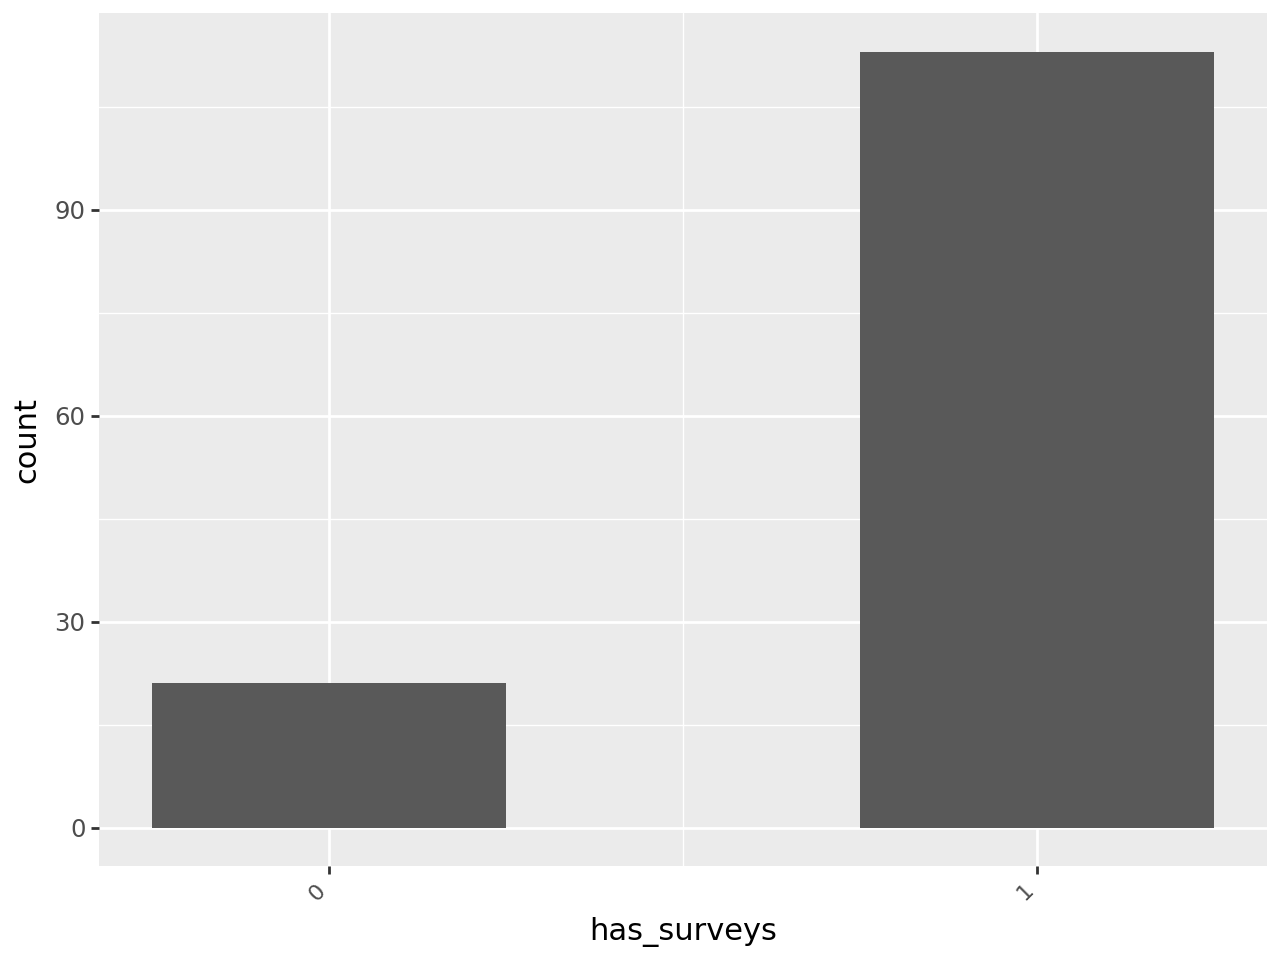

In [240]:
pln.ggplot(df_clean, pln.aes(x='has_surveys')) \
    + pln.geom_bar(width=0.5) \
    + pln.scale_x_continuous(breaks=range(0, 2, 1)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

##### *Has interviews*

In [241]:
df_clean["has_interviews"].value_counts()

has_interviews
1.0    94
0.0    40
Name: count, dtype: int64

In [242]:
df_clean["has_interviews"].isna().sum()

np.int64(1)

C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_count : Removed 1 rows containing non-finite values.


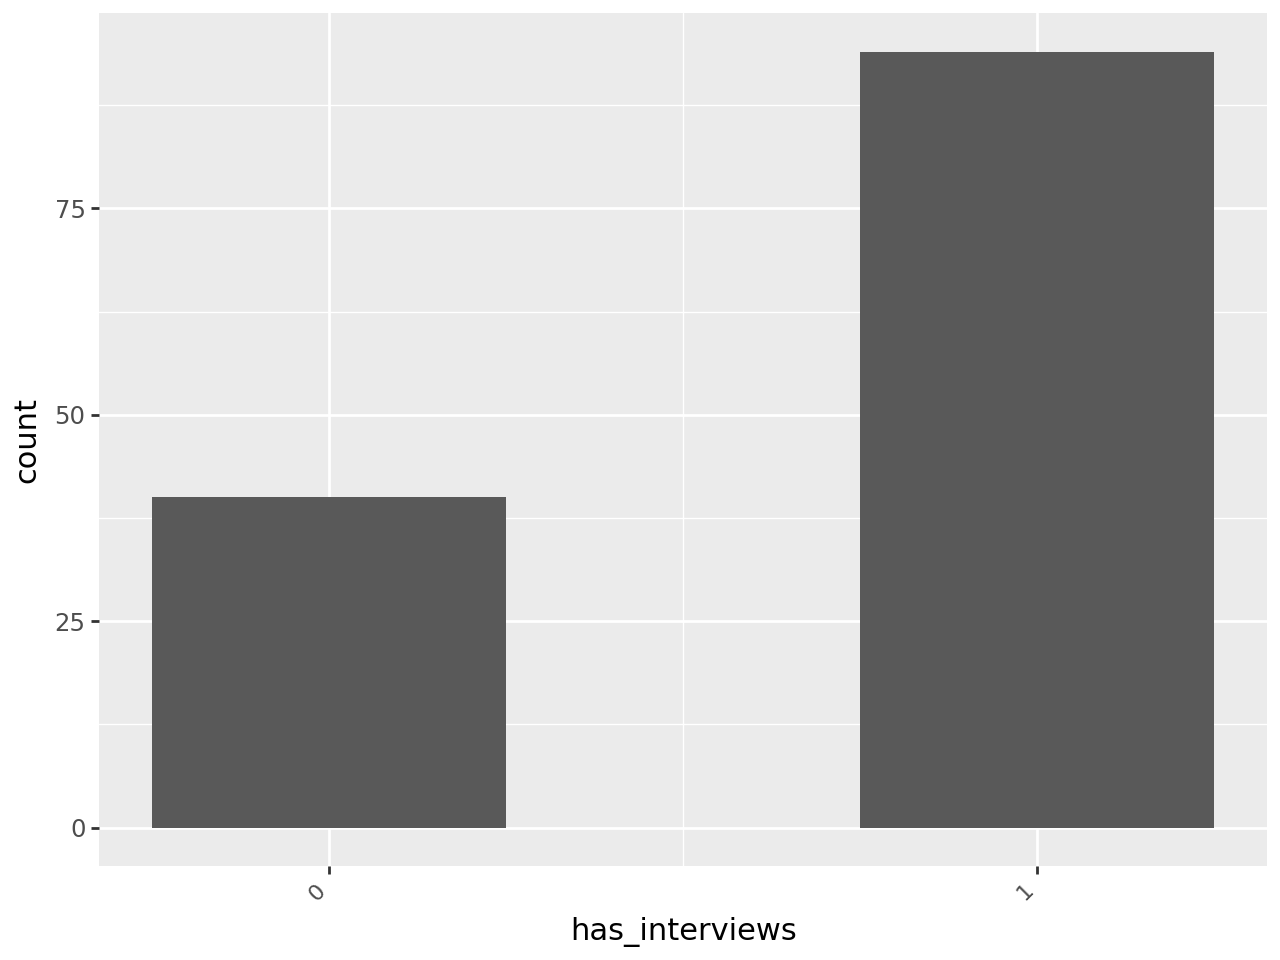

In [243]:
pln.ggplot(df_clean, pln.aes(x='has_interviews')) \
    + pln.geom_bar(width=0.5) \
    + pln.scale_x_continuous(breaks=range(0, 2, 1)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

##### *Has focus groups*

In [244]:
df_clean["has_focus_groups"].value_counts()

has_focus_groups
0.0    105
1.0     28
Name: count, dtype: int64

In [245]:
df_clean["has_focus_groups"].isna().sum()

np.int64(2)

C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_count : Removed 2 rows containing non-finite values.


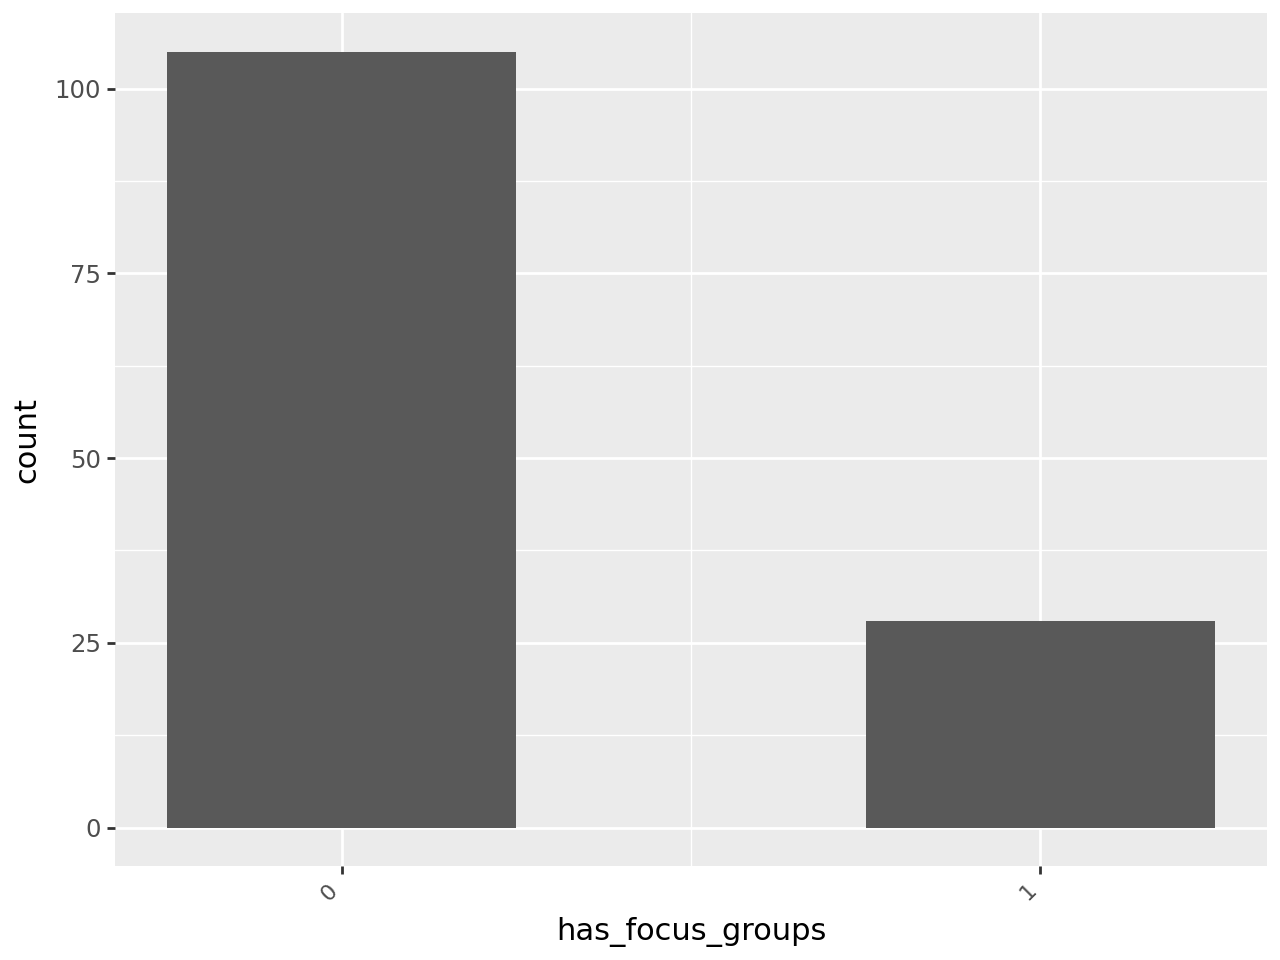

In [246]:
pln.ggplot(df_clean, pln.aes(x='has_focus_groups')) \
    + pln.geom_bar(width=0.5) \
    + pln.scale_x_continuous(breaks=range(0, 2, 1)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

##### *Has observations*

In [247]:
df_clean["has_observations"].value_counts()

has_observations
0.0    105
1.0     28
Name: count, dtype: int64

In [248]:
df_clean["has_observations"].isna().sum()

np.int64(2)

C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_count : Removed 2 rows containing non-finite values.


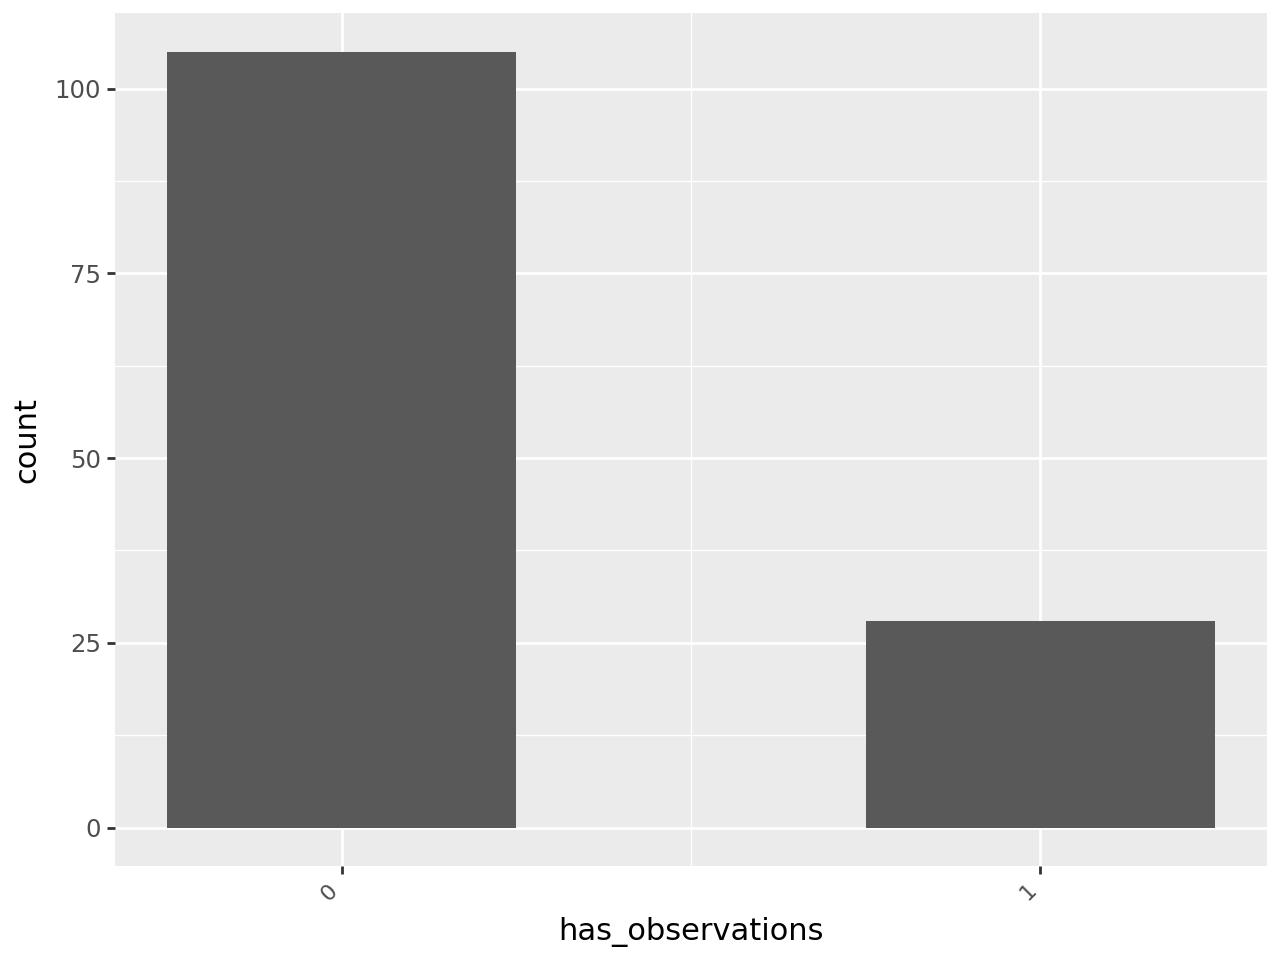

In [249]:
pln.ggplot(df_clean, pln.aes(x='has_observations')) \
    + pln.geom_bar(width=0.5) \
    + pln.scale_x_continuous(breaks=range(0, 2, 1)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

##### *Has tests*

In [250]:
df_clean["has_tests"].value_counts()

has_tests
0.0    96
1.0    37
Name: count, dtype: int64

In [251]:
df_clean["has_tests"].isna().sum()

np.int64(2)

C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_count : Removed 2 rows containing non-finite values.


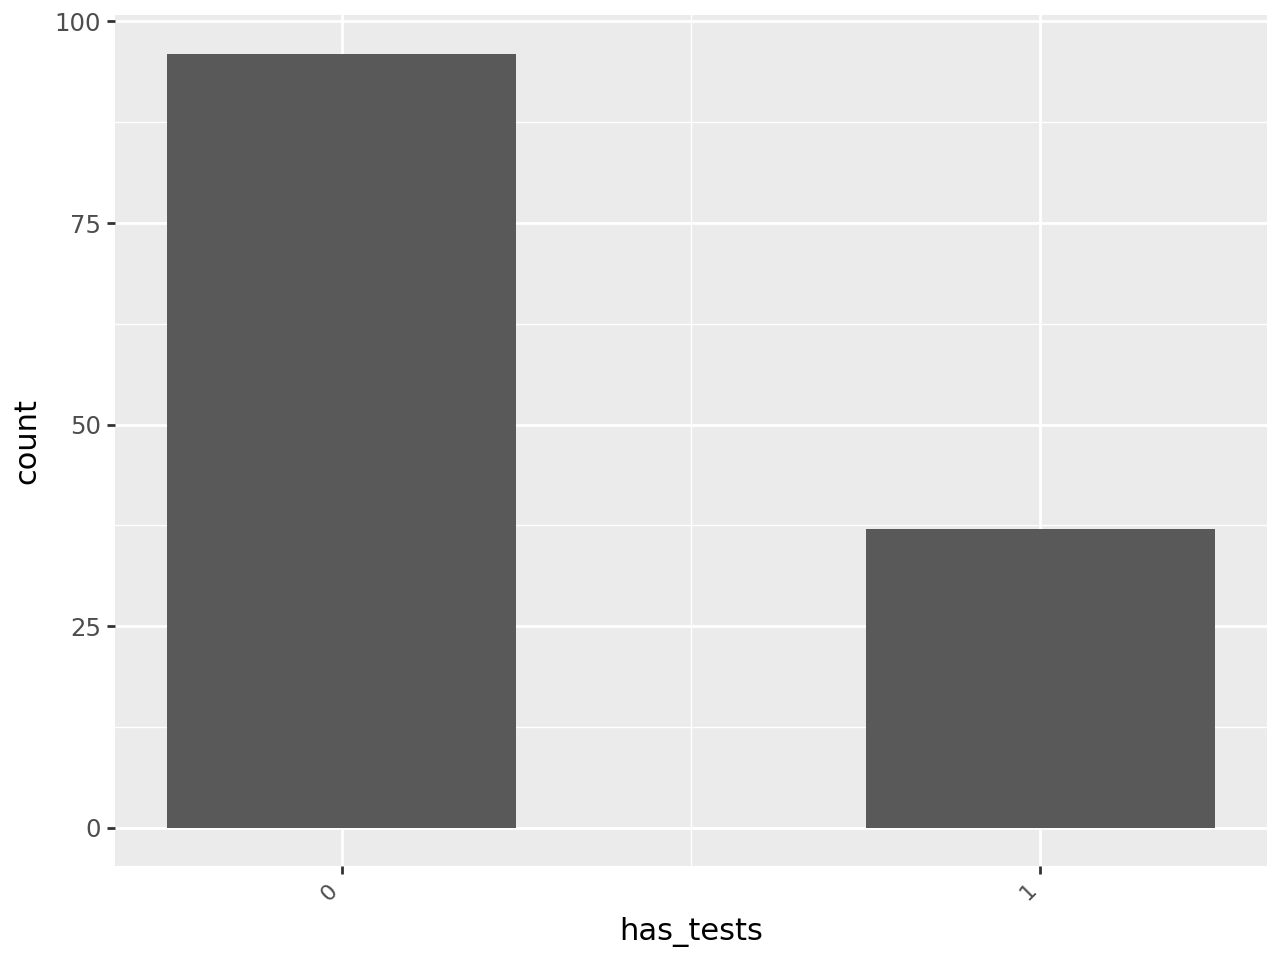

In [252]:
pln.ggplot(df_clean, pln.aes(x='has_tests')) \
    + pln.geom_bar(width=0.5) \
    + pln.scale_x_continuous(breaks=range(0, 2, 1)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

##### *requires translation*

In [253]:
df_clean["requires_translation"].value_counts()

requires_translation
1.0    71
0.0    53
Name: count, dtype: int64

In [254]:
df_clean["requires_translation"].isna().sum()

np.int64(11)

C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_count : Removed 11 rows containing non-finite values.


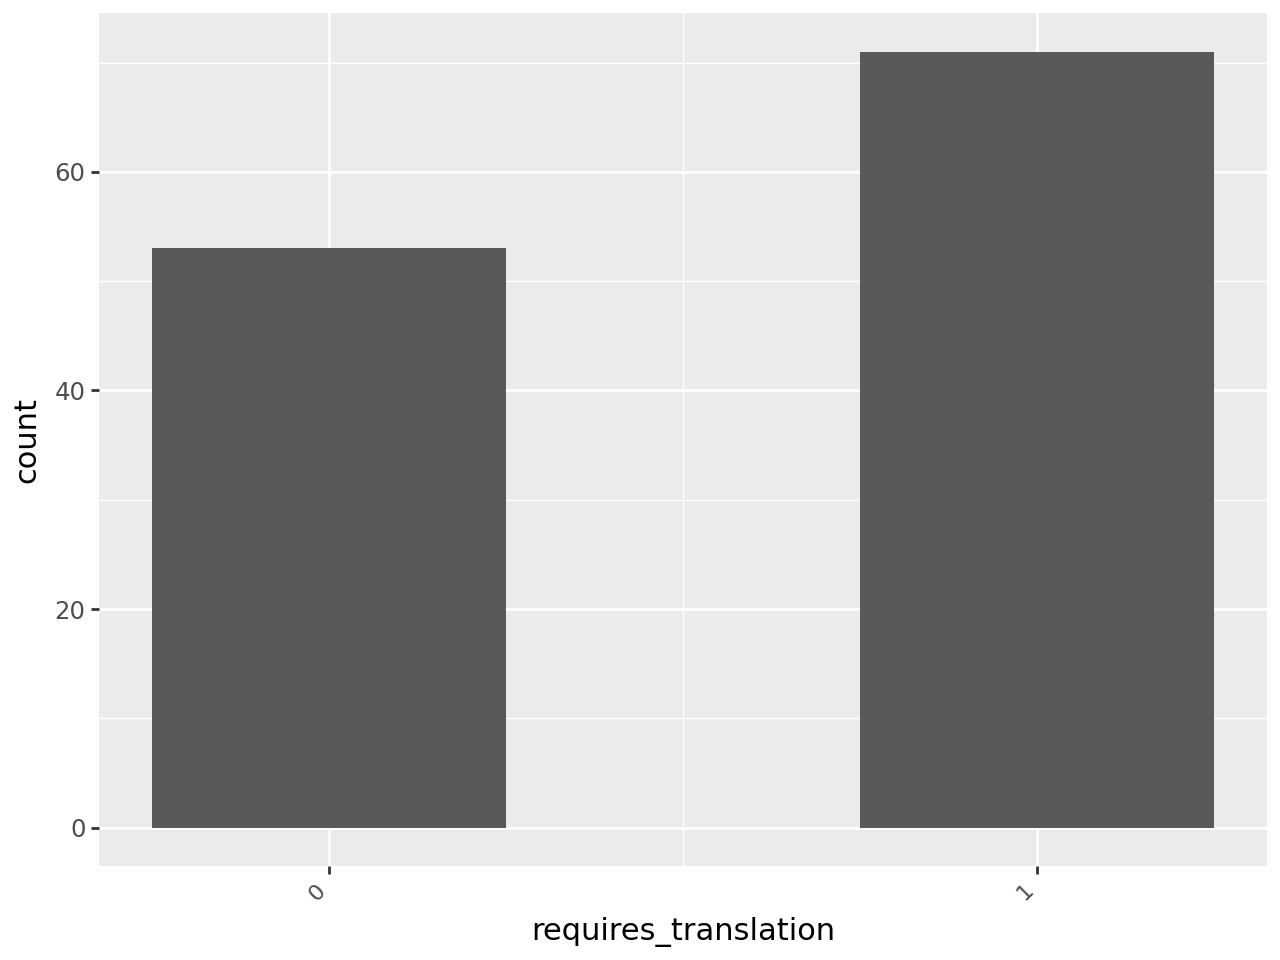

In [255]:
pln.ggplot(df_clean, pln.aes(x='requires_translation')) \
    + pln.geom_bar(width=0.5) \
    + pln.scale_x_continuous(breaks=range(0, 2, 1)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

##### *Uses admin data*

In [256]:
df_clean["uses_admin_data"].value_counts()

uses_admin_data
0.0    105
1.0     26
Name: count, dtype: int64

In [257]:
df_clean["uses_admin_data"].isna().sum()

np.int64(4)

C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_count : Removed 4 rows containing non-finite values.


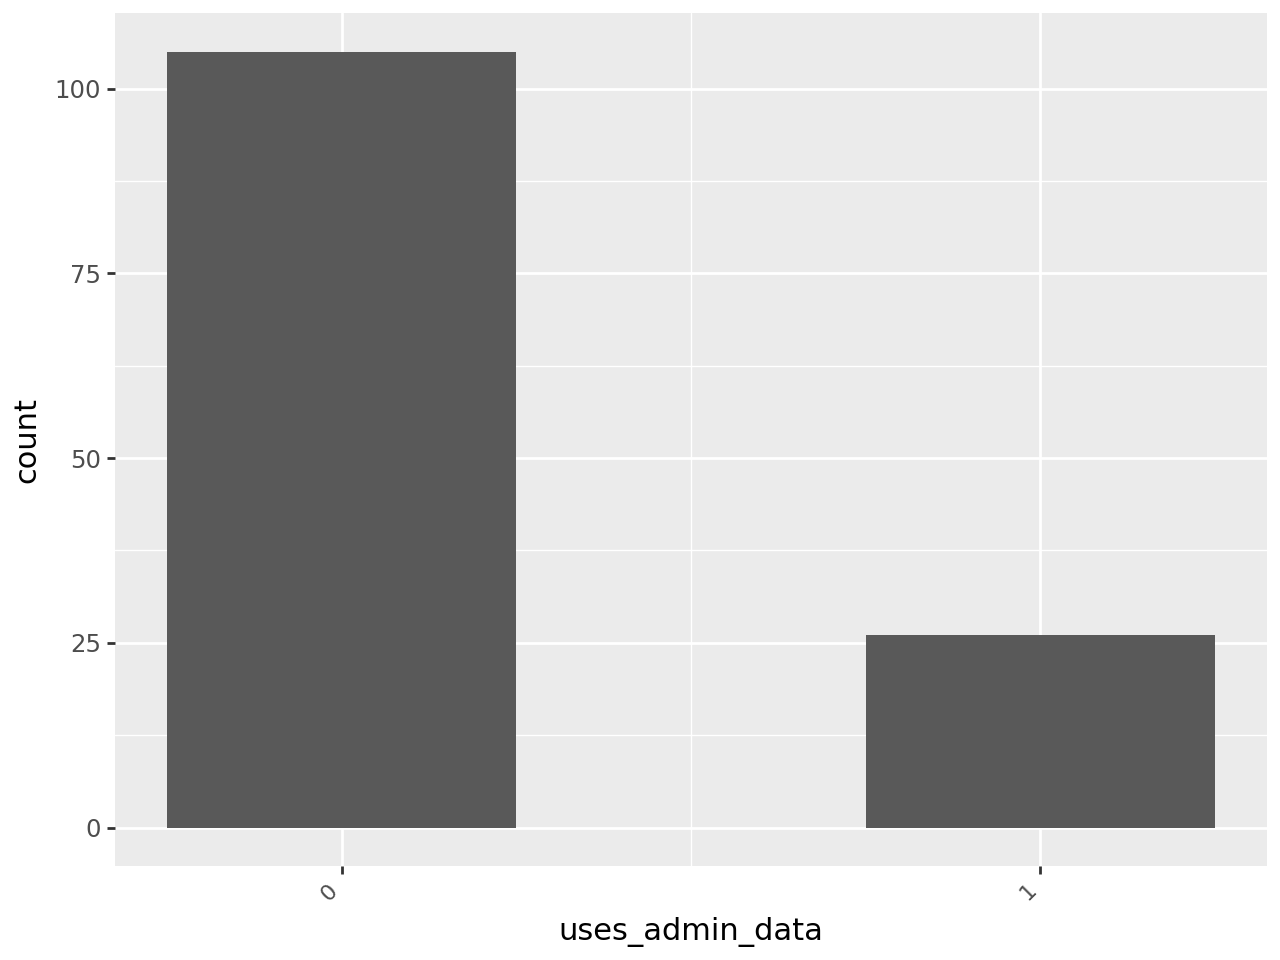

In [258]:
pln.ggplot(df_clean, pln.aes(x='uses_admin_data')) \
    + pln.geom_bar(width=0.5) \
    + pln.scale_x_continuous(breaks=range(0, 2, 1)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

##### *requires data linking*

In [259]:
df_clean["requires_data_linking"].value_counts()

requires_data_linking
0.0    114
1.0     15
Name: count, dtype: int64

In [260]:
df_clean["requires_data_linking"].isna().sum()

np.int64(6)

C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_count : Removed 6 rows containing non-finite values.


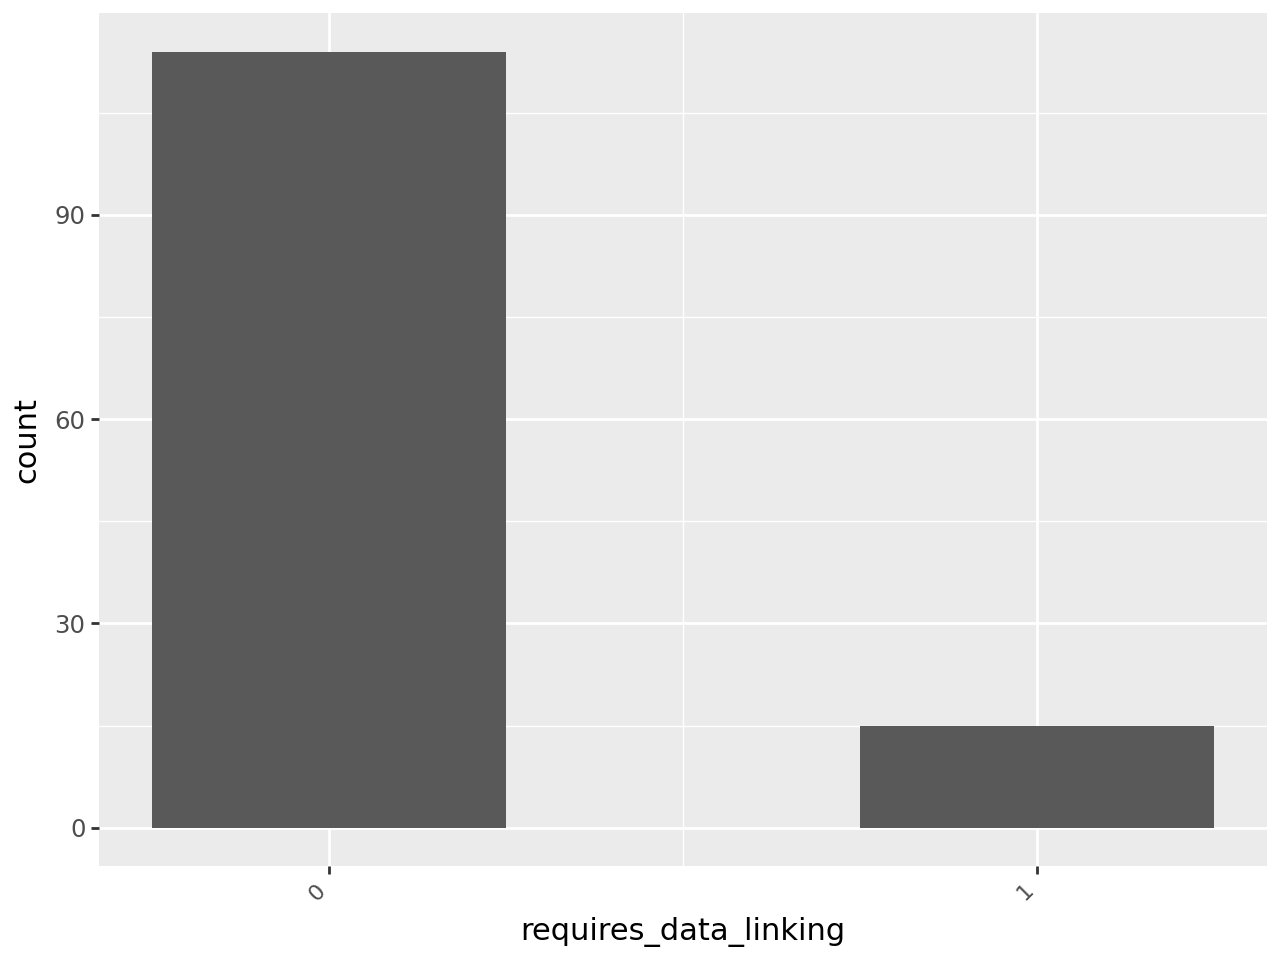

In [261]:
pln.ggplot(df_clean, pln.aes(x='requires_data_linking')) \
    + pln.geom_bar(width=0.5) \
    + pln.scale_x_continuous(breaks=range(0, 2, 1)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

##### *Is complex design*

In [262]:
df_clean["is_complex_design"].value_counts()

is_complex_design
1.0    94
0.0    36
Name: count, dtype: int64

In [263]:
df_clean["is_complex_design"].isna().sum()

np.int64(5)

C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_count : Removed 5 rows containing non-finite values.


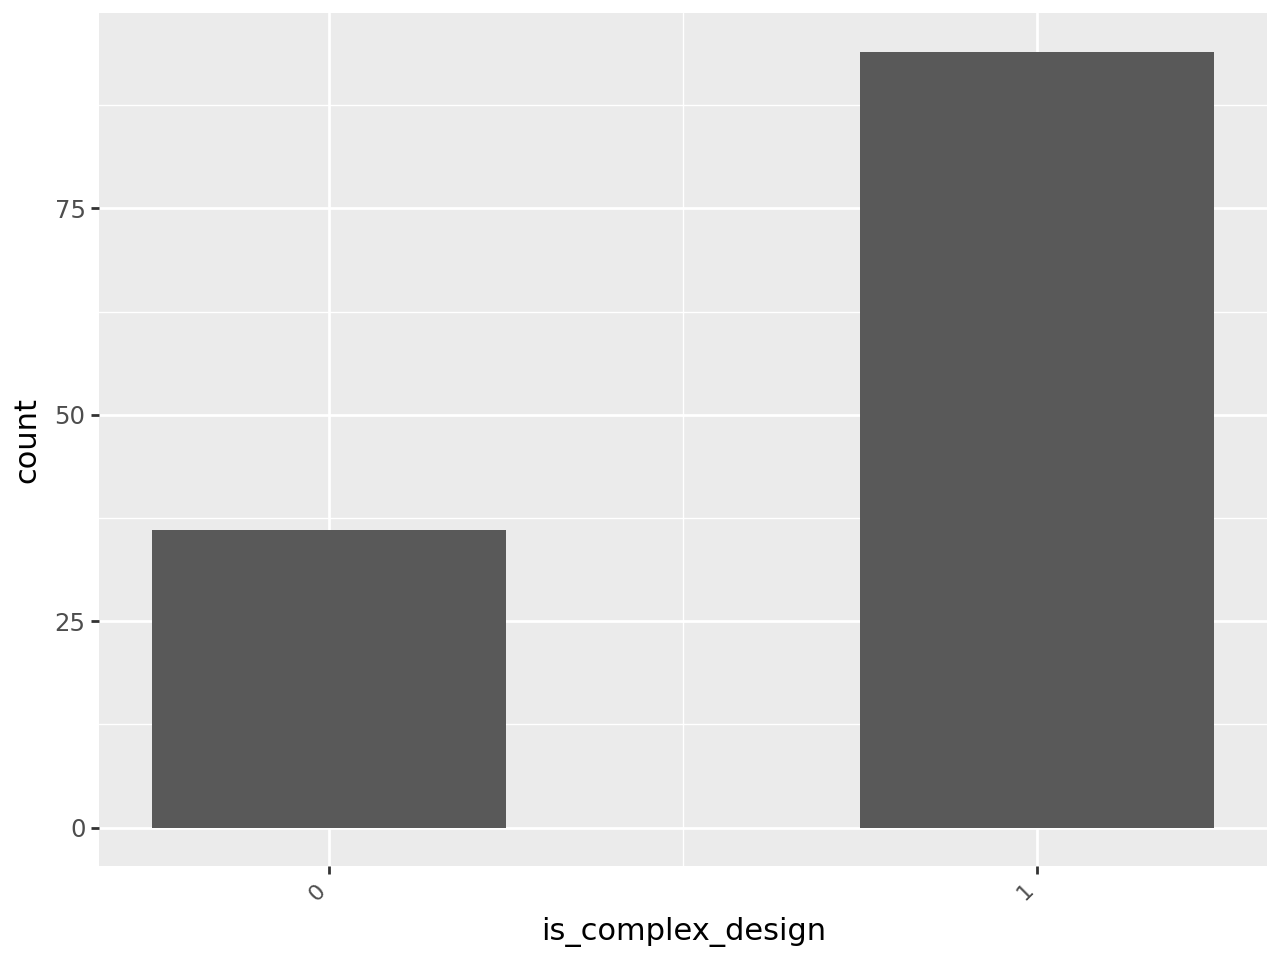

In [264]:
pln.ggplot(df_clean, pln.aes(x='is_complex_design')) \
    + pln.geom_bar(width=0.5) \
    + pln.scale_x_continuous(breaks=range(0, 2, 1)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

##### *has external services*

In [265]:
df_clean["has_external_services"].value_counts()

has_external_services
1    111
0     24
Name: count, dtype: int64

In [266]:
df_clean["has_external_services"].isna().sum()

np.int64(0)

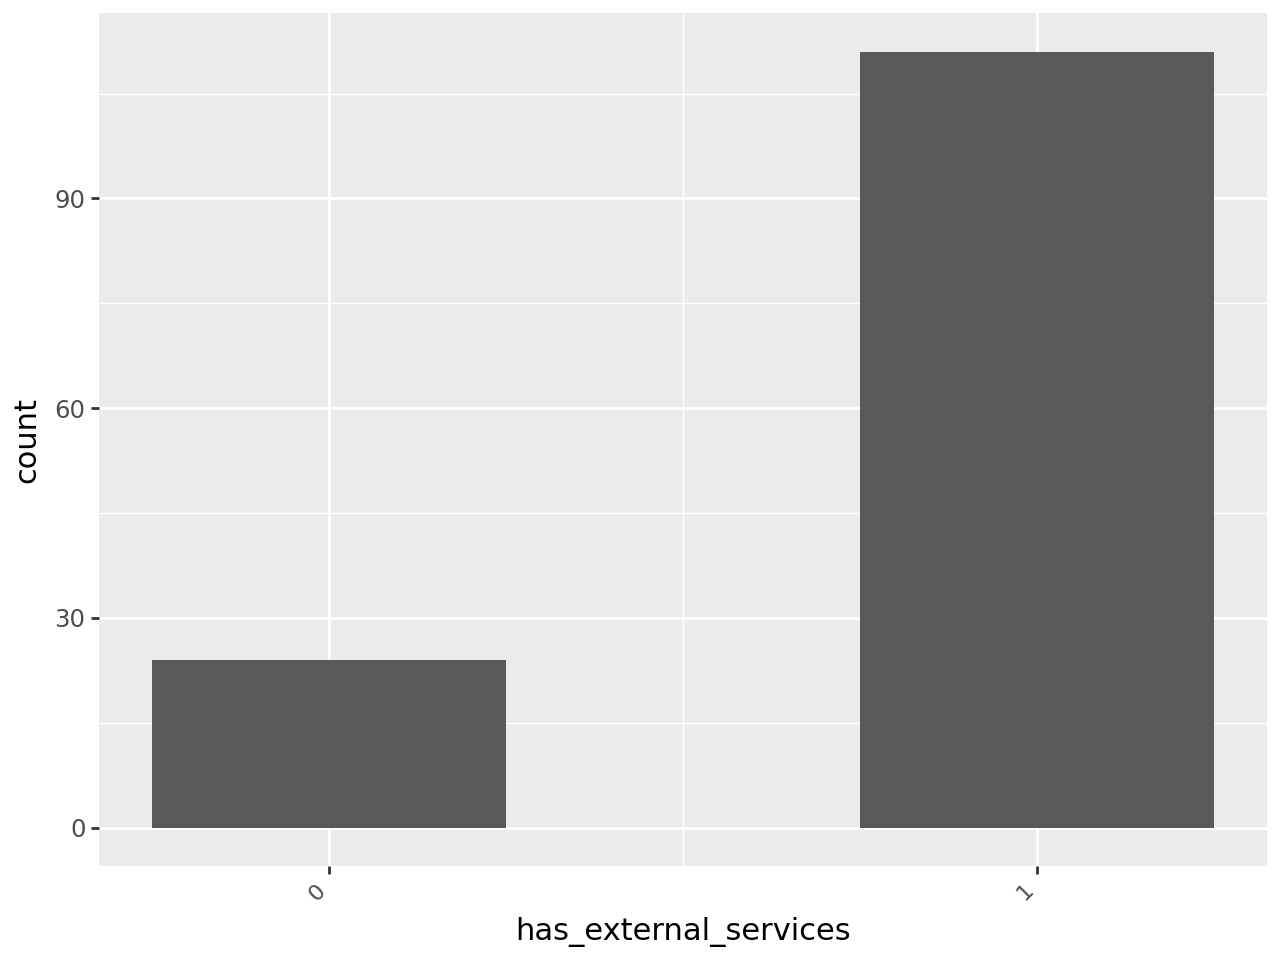

In [267]:
pln.ggplot(df_clean, pln.aes(x='has_external_services')) \
    + pln.geom_bar(width=0.5) \
    + pln.scale_x_continuous(breaks=range(0, 2, 1)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

##### *Has special equipment*

In [268]:
df_clean["has_special_equipment"].value_counts()

has_special_equipment
0    102
1     33
Name: count, dtype: int64

In [269]:
df_clean["has_special_equipment"].isna().sum()

np.int64(0)

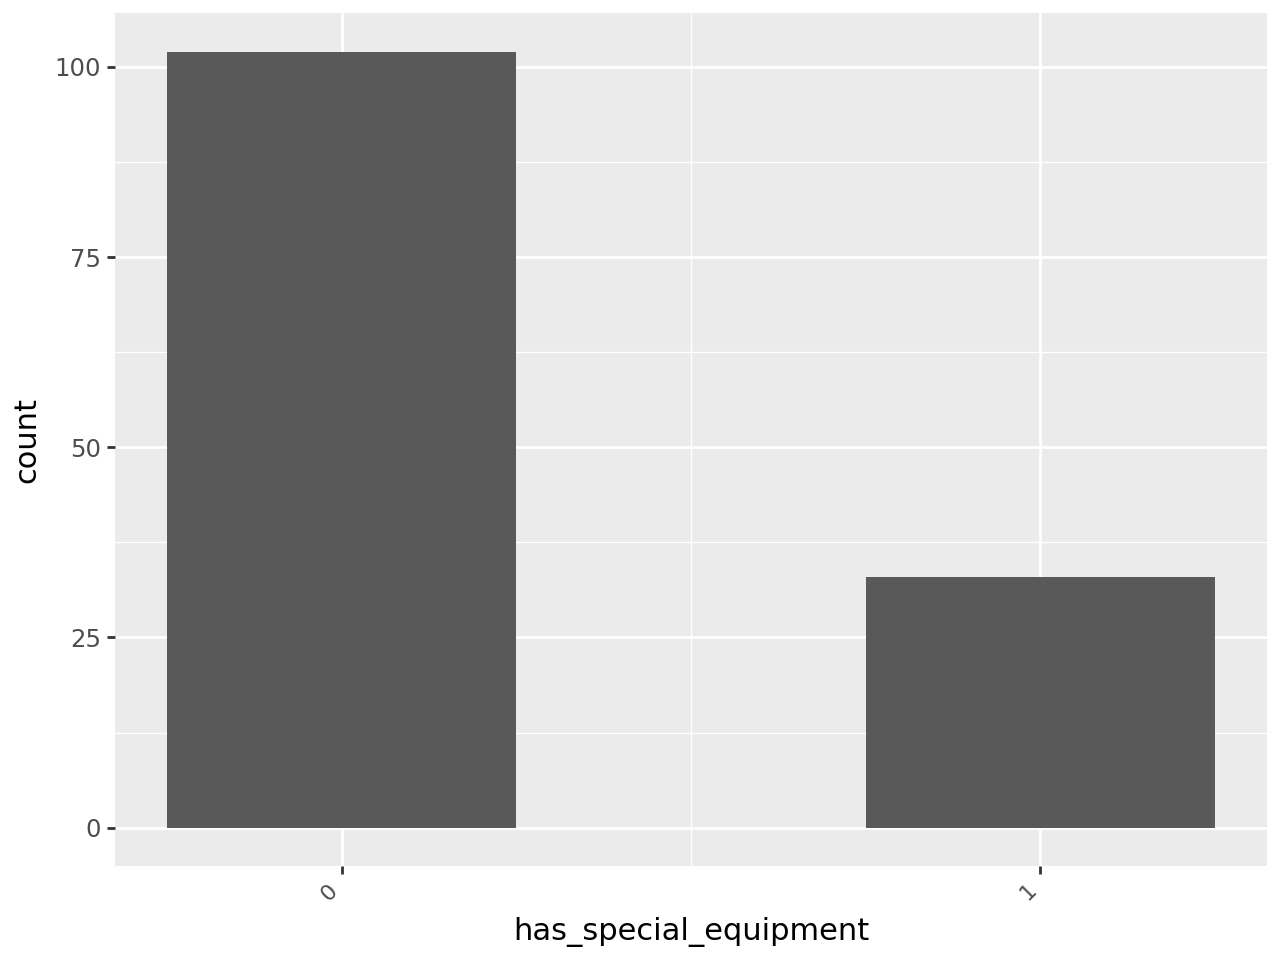

In [270]:
pln.ggplot(df_clean, pln.aes(x='has_special_equipment')) \
    + pln.geom_bar(width=0.5) \
    + pln.scale_x_continuous(breaks=range(0, 2, 1)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

##### *Is multidisciplinary*

In [271]:
df_clean["is_multidisciplinary"].value_counts()

is_multidisciplinary
1.0    62
0.0    49
Name: count, dtype: int64

In [272]:
df_clean["is_multidisciplinary"].isna().sum()

np.int64(24)

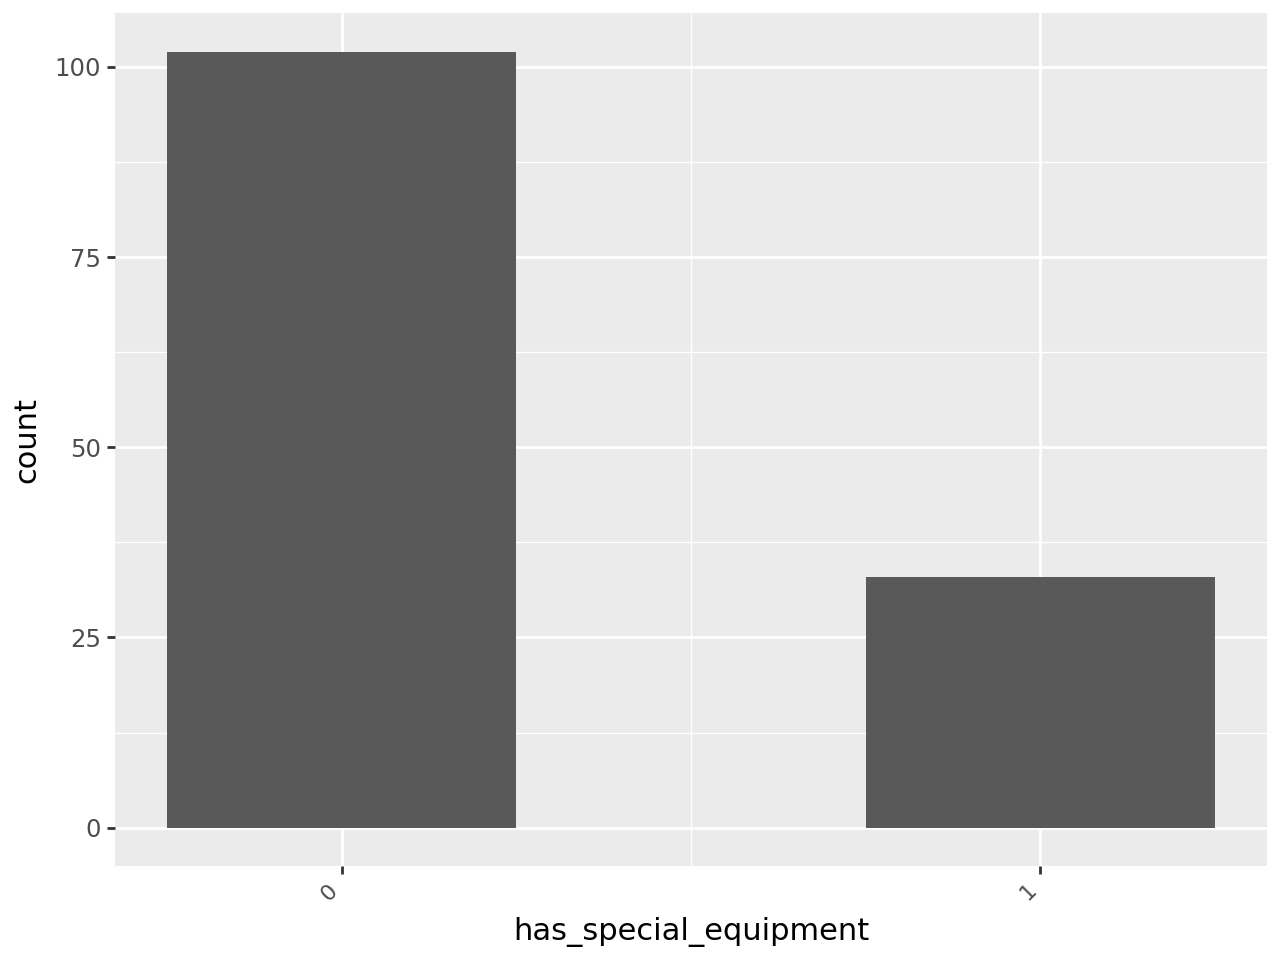

In [273]:
pln.ggplot(df_clean, pln.aes(x='has_special_equipment')) \
    + pln.geom_bar(width=0.5) \
    + pln.scale_x_continuous(breaks=range(0, 2, 1)) \
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

#### *Categorial Variables*

##### *Collection mode*

In [274]:
df_clean["collection_mode"].isna().sum()

np.int64(0)

In [275]:
df_clean["collection_mode"].value_counts()

collection_mode
Mixed              72
Field              34
Online             20
Unknown             5
SurveyInstitute     4
Name: count, dtype: int64

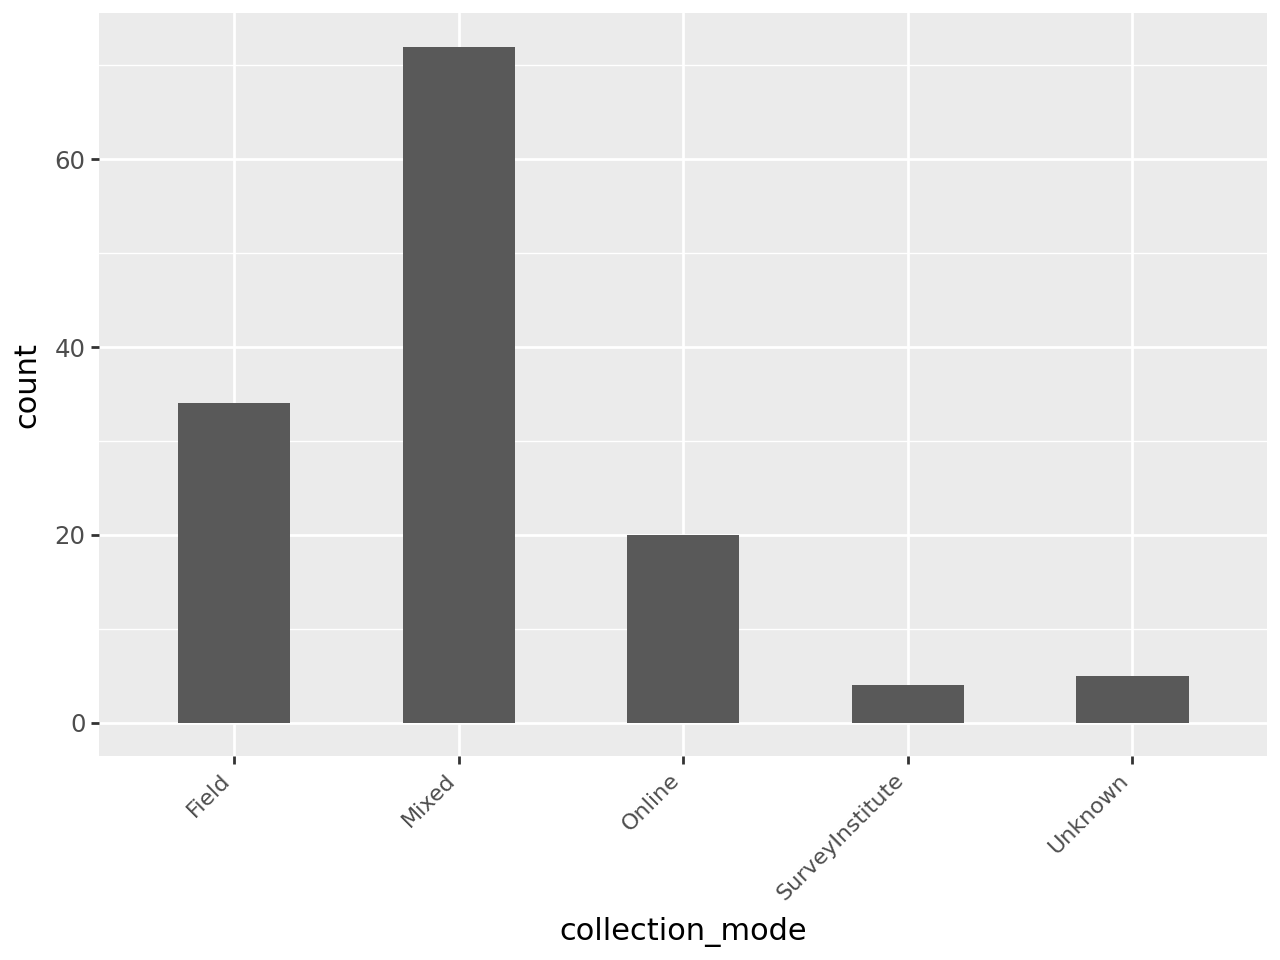

In [276]:
pln.ggplot(df_clean, pln.aes(x='collection_mode'))\
     + pln.geom_bar(width=0.5)\
     + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

##### *tool development type*

In [277]:
df_clean["tool_development_type"].isna().sum()

np.int64(0)

In [278]:
df_clean["tool_development_type"].value_counts()

tool_development_type
Adaptation    73
New           40
Unknown       15
Existing       6
Validation     1
Name: count, dtype: int64

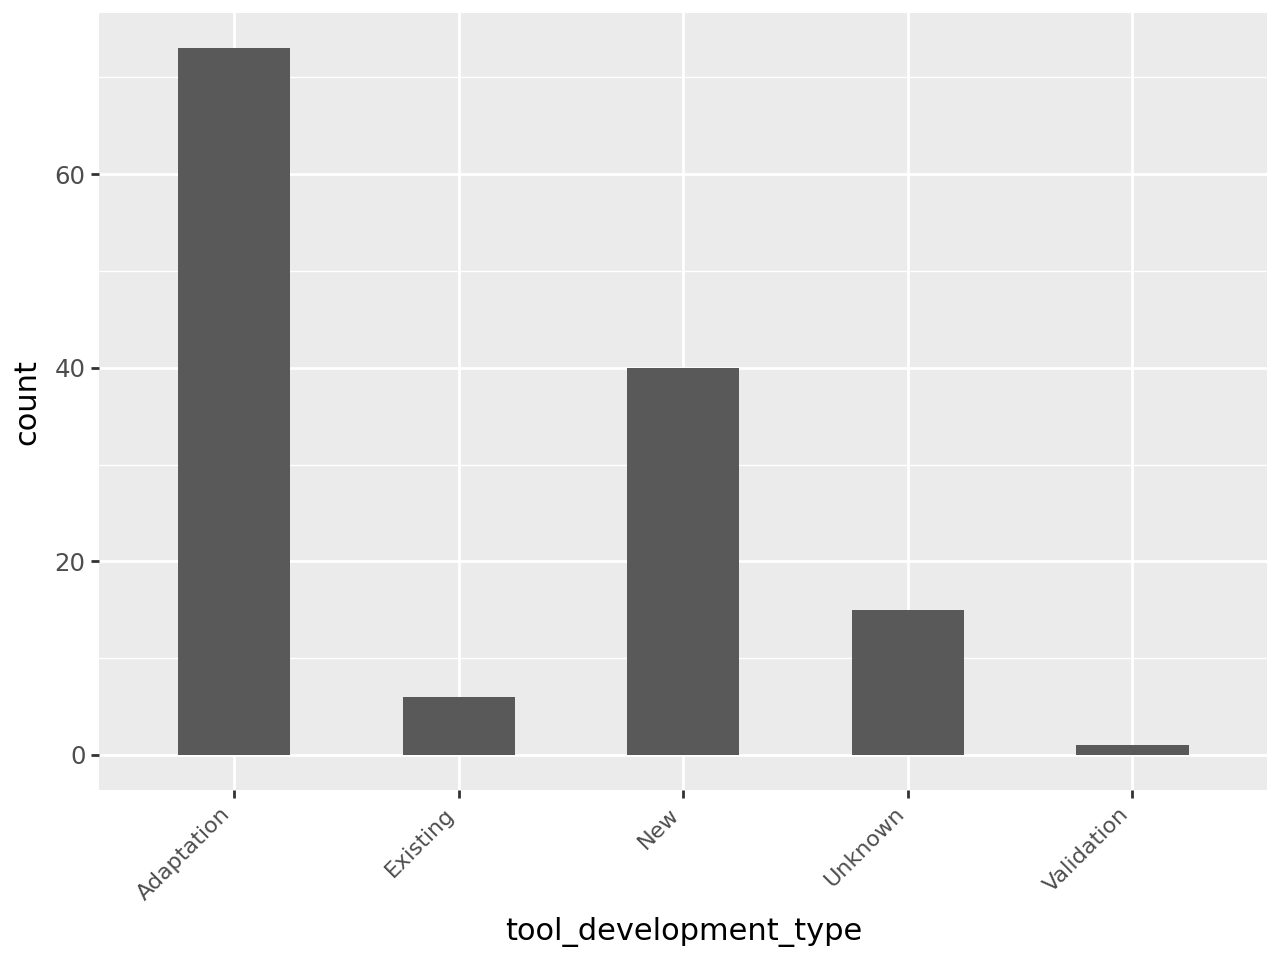

In [279]:
pln.ggplot(df_clean, pln.aes(x='tool_development_type'))\
     + pln.geom_bar(width=0.5)\
     + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

##### *derivelables type*

In [280]:
df_clean["deliverables_level"].isna().sum()

np.int64(0)

In [281]:
df_clean["tool_development_type"].value_counts()

tool_development_type
Adaptation    73
New           40
Unknown       15
Existing       6
Validation     1
Name: count, dtype: int64

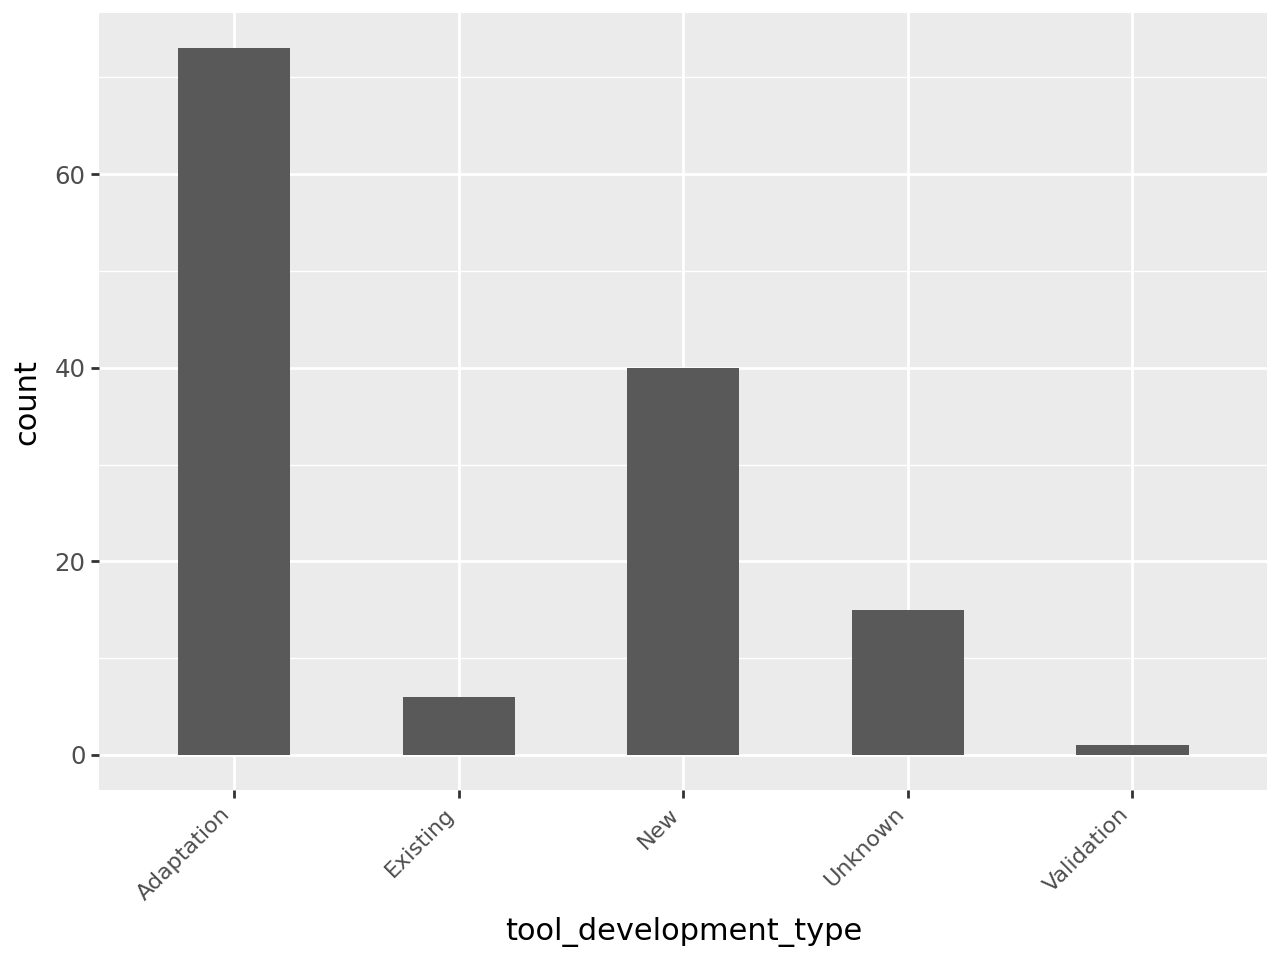

In [282]:
pln.ggplot(df_clean, pln.aes(x='tool_development_type'))\
     + pln.geom_bar(width=0.5)\
     + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))

### *Correlation Analysis*

#### *Setup*

In [283]:
def corr_heatmap(matrix, title):
    long = matrix.reset_index().melt(id_vars="index")
    long.columns = ["feature_1", "feature_2", "correlation"]
    return (
        pln.ggplot(long, pln.aes("feature_1", "feature_2", fill="correlation"))
        + pln.geom_tile()
        + pln.scale_fill_gradient2(low="blue", mid="white", high="red", midpoint=0, limits=(-1, 1))
        + pln.theme(axis_text_x=pln.element_text(rotation=90, hjust=1), figure_size=(9, 8))
        + pln.labs(title=title)
    )

#### *Numeric varaibles analsys*

##### *Pearson correlation analysis*

In [284]:
linear_corr_continuous = df_clean[continuous_cols].corr(method="pearson")
linear_corr_continuous

,duration_months,site_count,subject_count,target_populations_count,data_waves_count,languages_count,budgeted_person_work,target_budget
duration_months,1.000000,-0.094533,0.185826,0.051075,0.500360,-0.049360,0.735553,0.810197
site_count,-0.094533,1.000000,0.488942,0.026876,-0.168402,0.280819,-0.019709,0.016250
subject_count,0.185826,0.488942,1.000000,0.278470,0.292570,0.207616,0.141733,0.181746
target_populations_count,0.051075,0.026876,0.278470,1.000000,0.186353,0.309411,0.191338,0.213543
data_waves_count,0.500360,-0.168402,0.292570,0.186353,1.000000,-0.134983,0.404499,0.418654
languages_count,-0.049360,0.280819,0.207616,0.309411,-0.134983,1.000000,-0.110373,-0.012777
budgeted_person_work,0.735553,-0.019709,0.141733,0.191338,0.404499,-0.110373,1.000000,0.900321
target_budget,0.810197,0.016250,0.181746,0.213543,0.418654,-0.012777,0.900321,1.000000


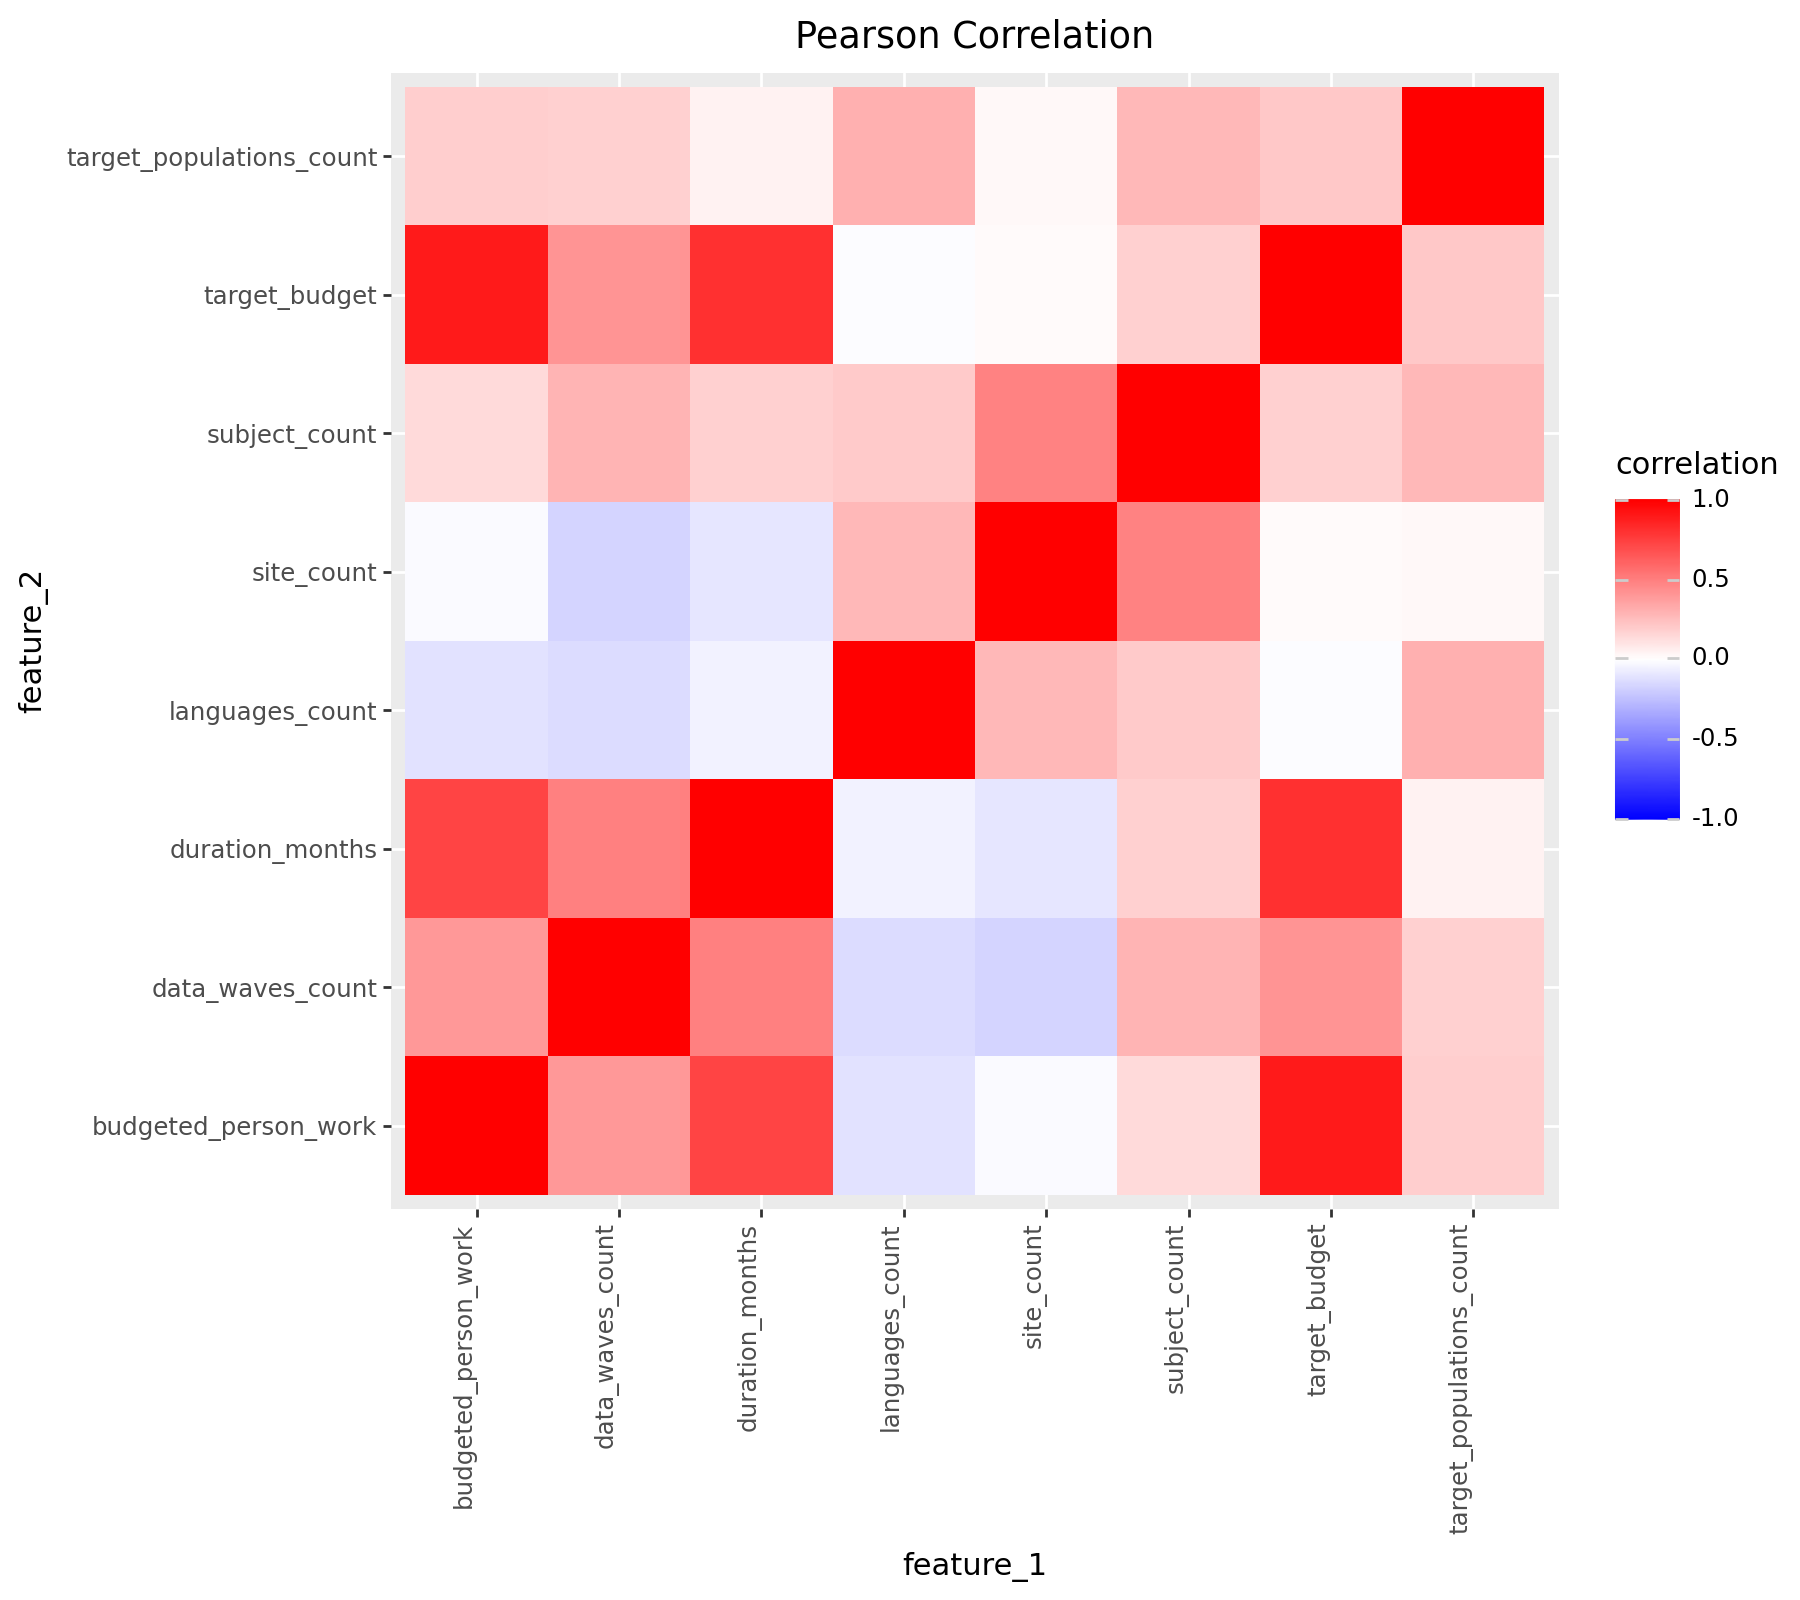

In [285]:
corr_heatmap(linear_corr_continuous, "Pearson Correlation")

In [286]:
linear_corr_binary = df_clean[binary_cols].corr(method="pearson")
linear_corr_binary

,has_surveys,has_interviews,has_focus_groups,has_observations,has_tests,requires_translation,uses_admin_data,requires_data_linking,is_complex_design,has_external_services,has_special_equipment,is_multidisciplinary
has_surveys,1.000000,-0.146633,0.223607,-0.079860,0.038749,0.153013,-0.001625,0.150756,0.288880,-0.040752,0.055826,0.226474
has_interviews,-0.146633,1.000000,0.097367,0.097367,-0.324619,0.042237,-0.010864,-0.083892,-0.002865,0.205674,-0.194912,-0.074410
has_focus_groups,0.223607,0.097367,1.000000,0.050000,0.008665,0.284841,-0.072703,0.102316,0.104964,0.050482,-0.168550,0.123433
has_observations,-0.079860,0.097367,0.050000,1.000000,0.132135,-0.071876,0.114044,-0.015006,0.031523,-0.093391,-0.083151,0.131861
has_tests,0.038749,-0.324619,0.008665,0.132135,1.000000,0.034758,0.122399,0.159366,0.314150,-0.319524,0.148378,0.363492
requires_translation,0.153013,0.042237,0.284841,-0.071876,0.034758,1.000000,0.186863,0.261822,0.102404,-0.085876,0.107443,0.299718
uses_admin_data,-0.001625,-0.010864,-0.072703,0.114044,0.122399,0.186863,1.000000,0.634435,0.130152,-0.110660,0.028903,0.141146
requires_data_linking,0.150756,-0.083892,0.102316,-0.015006,0.159366,0.261822,0.634435,1.000000,0.173887,-0.020570,0.022376,0.154524
is_complex_design,0.288880,-0.002865,0.104964,0.031523,0.314150,0.102404,0.130152,0.173887,1.000000,-0.205856,-0.005525,0.515644
has_external_services,-0.040752,0.205674,0.050482,-0.093391,-0.319524,-0.085876,-0.110660,-0.020570,-0.205856,1.000000,-0.006011,-0.209875


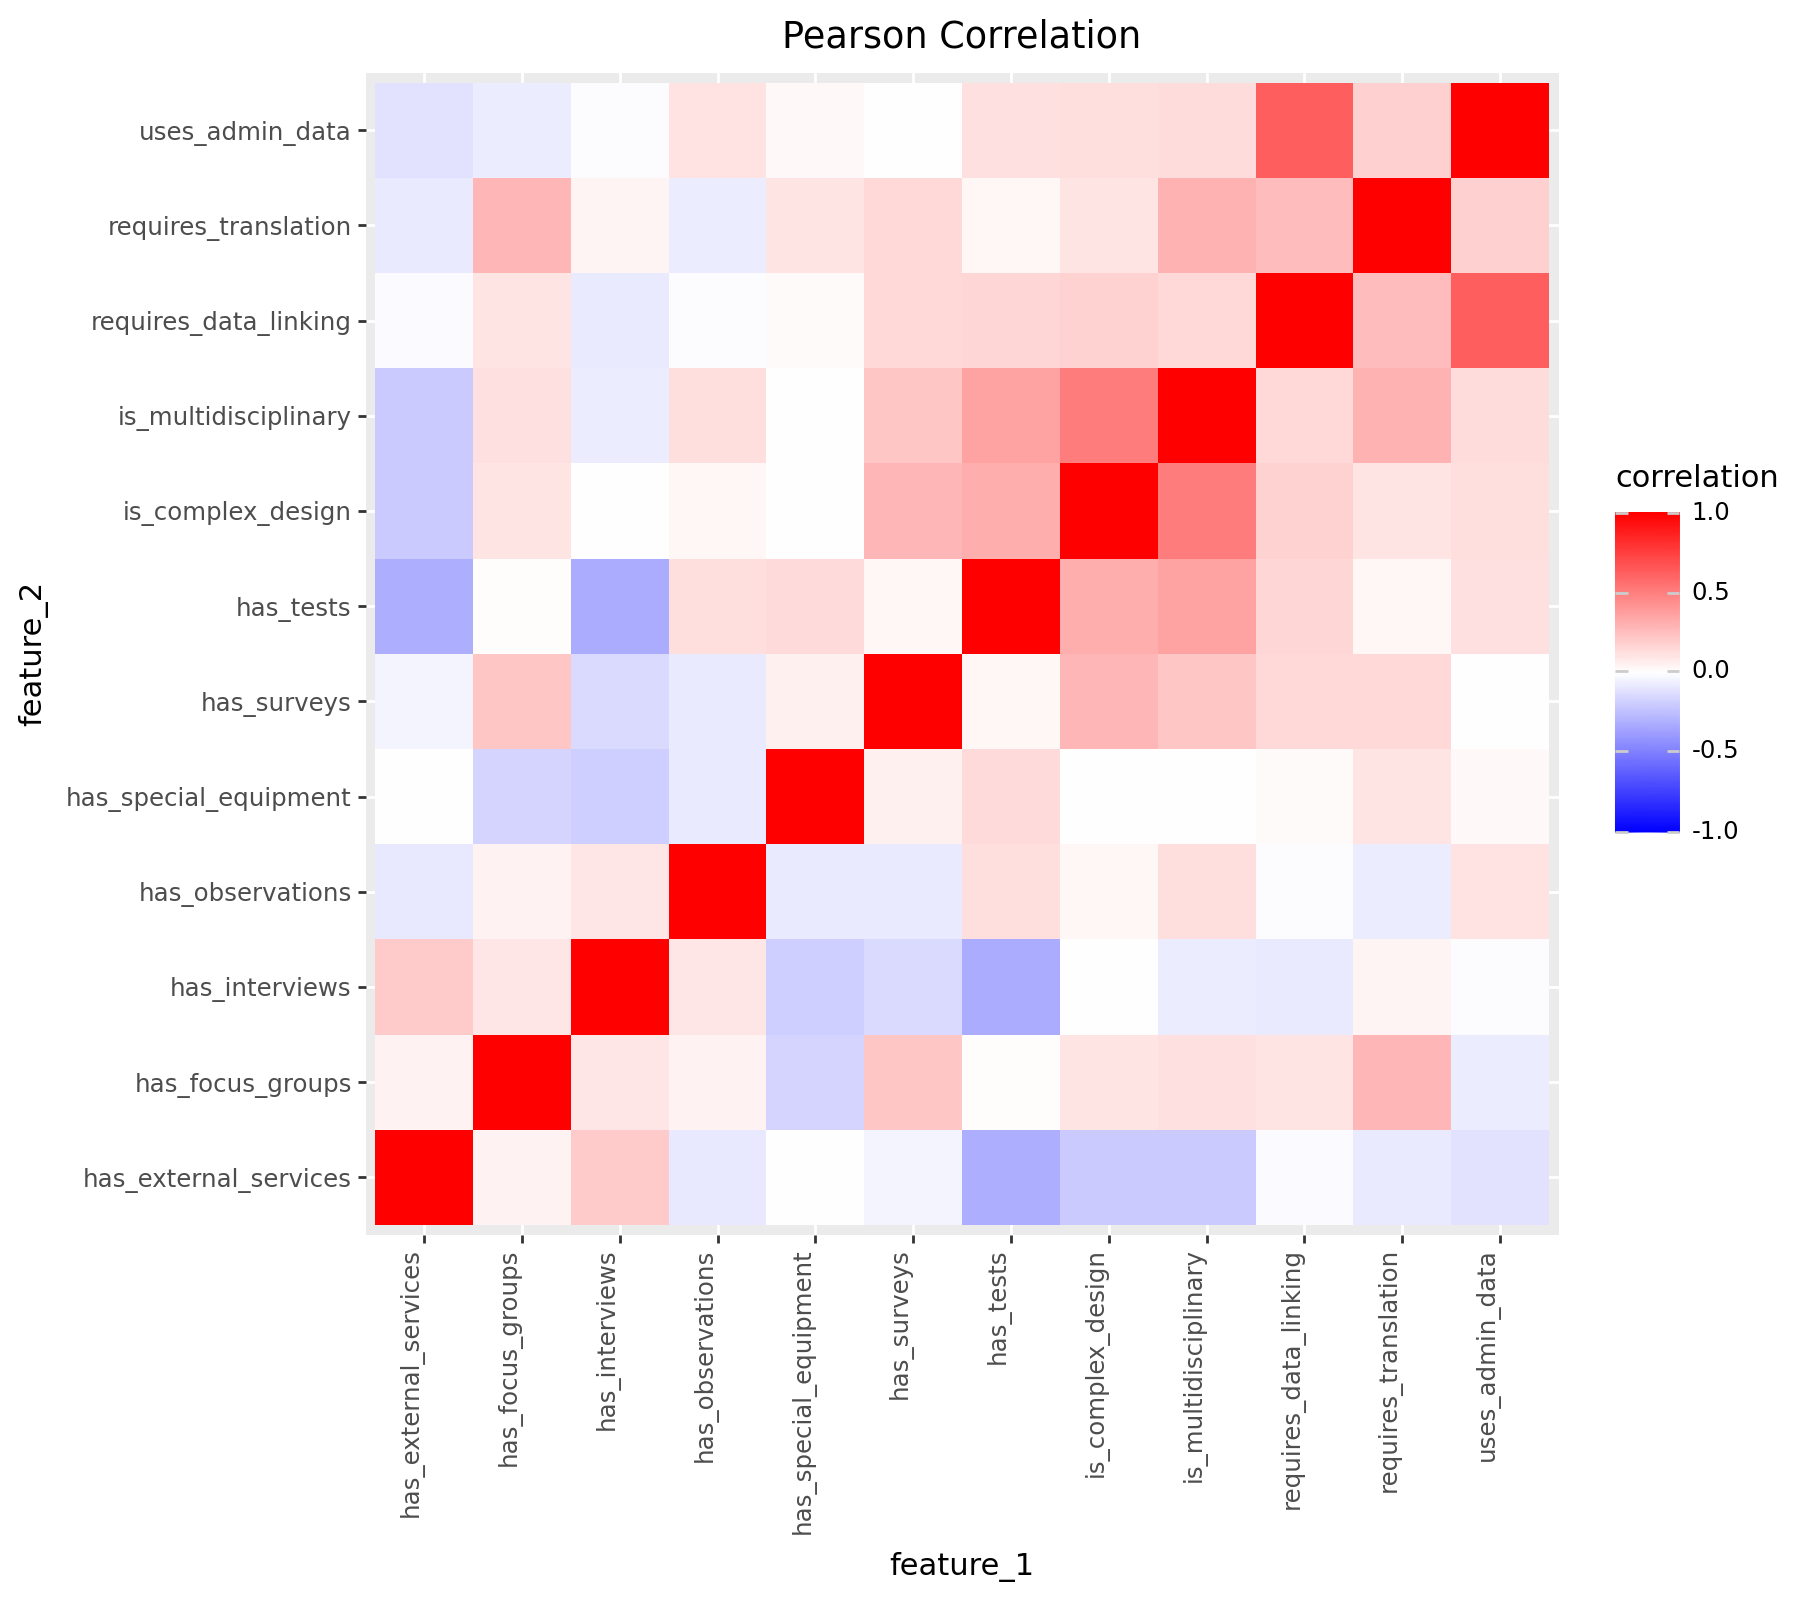

In [287]:
corr_heatmap(linear_corr_binary, "Pearson Correlation")

In [288]:
linear_corr_cross = df_clean[numeric_cols].corr(method="pearson")
linear_corr_cross

,duration_months,site_count,subject_count,target_populations_count,data_waves_count,has_surveys,has_interviews,has_focus_groups,has_observations,has_tests,languages_count,requires_translation,uses_admin_data,requires_data_linking,is_complex_design,budgeted_person_work,has_external_services,has_special_equipment,is_multidisciplinary,target_budget
duration_months,1.000000,-0.094533,0.185826,0.051075,0.500360,0.166829,0.008949,0.150937,0.225776,0.444684,-0.049360,-0.150542,0.088583,0.096297,0.377910,0.735553,-0.248573,0.095074,0.397641,0.810197
site_count,-0.094533,1.000000,0.488942,0.026876,-0.168402,0.208228,-0.026331,-0.033401,-0.105272,-0.028621,0.280819,0.204924,0.258622,0.504728,-0.120470,-0.019709,0.041989,-0.100309,-0.138118,0.016250
subject_count,0.185826,0.488942,1.000000,0.278470,0.292570,0.196038,0.081278,0.272785,-0.111082,0.111020,0.207616,0.200385,0.148312,0.462333,0.122696,0.141733,-0.027211,-0.197766,0.200371,0.181746
target_populations_count,0.051075,0.026876,0.278470,1.000000,0.186353,0.124144,0.324661,0.281659,0.085623,-0.095344,0.309411,0.065824,0.088903,0.126632,0.073828,0.191338,0.043035,-0.069593,0.013159,0.213543
data_waves_count,0.500360,-0.168402,0.292570,0.186353,1.000000,-0.018302,0.053475,0.284499,0.158024,0.309532,-0.134983,0.054187,0.076444,0.113472,0.222777,0.404499,-0.183599,0.010477,0.182682,0.418654
has_surveys,0.166829,0.208228,0.196038,0.124144,-0.018302,1.000000,-0.146633,0.223607,-0.079860,0.038749,0.002867,0.153013,-0.001625,0.150756,0.288880,0.092480,-0.040752,0.055826,0.226474,0.179692
has_interviews,0.008949,-0.026331,0.081278,0.324661,0.053475,-0.146633,1.000000,0.097367,0.097367,-0.324619,0.214998,0.042237,-0.010864,-0.083892,-0.002865,0.046096,0.205674,-0.194912,-0.074410,0.079916
has_focus_groups,0.150937,-0.033401,0.272785,0.281659,0.284499,0.223607,0.097367,1.000000,0.050000,0.008665,0.059504,0.284841,-0.072703,0.102316,0.104964,0.107204,0.050482,-0.168550,0.123433,0.137311
has_observations,0.225776,-0.105272,-0.111082,0.085623,0.158024,-0.079860,0.097367,0.050000,1.000000,0.132135,0.008408,-0.071876,0.114044,-0.015006,0.031523,0.392107,-0.093391,-0.083151,0.131861,0.292199
has_tests,0.444684,-0.028621,0.111020,-0.095344,0.309532,0.038749,-0.324619,0.008665,0.132135,1.000000,-0.108584,0.034758,0.122399,0.159366,0.314150,0.303005,-0.319524,0.148378,0.363492,0.318415


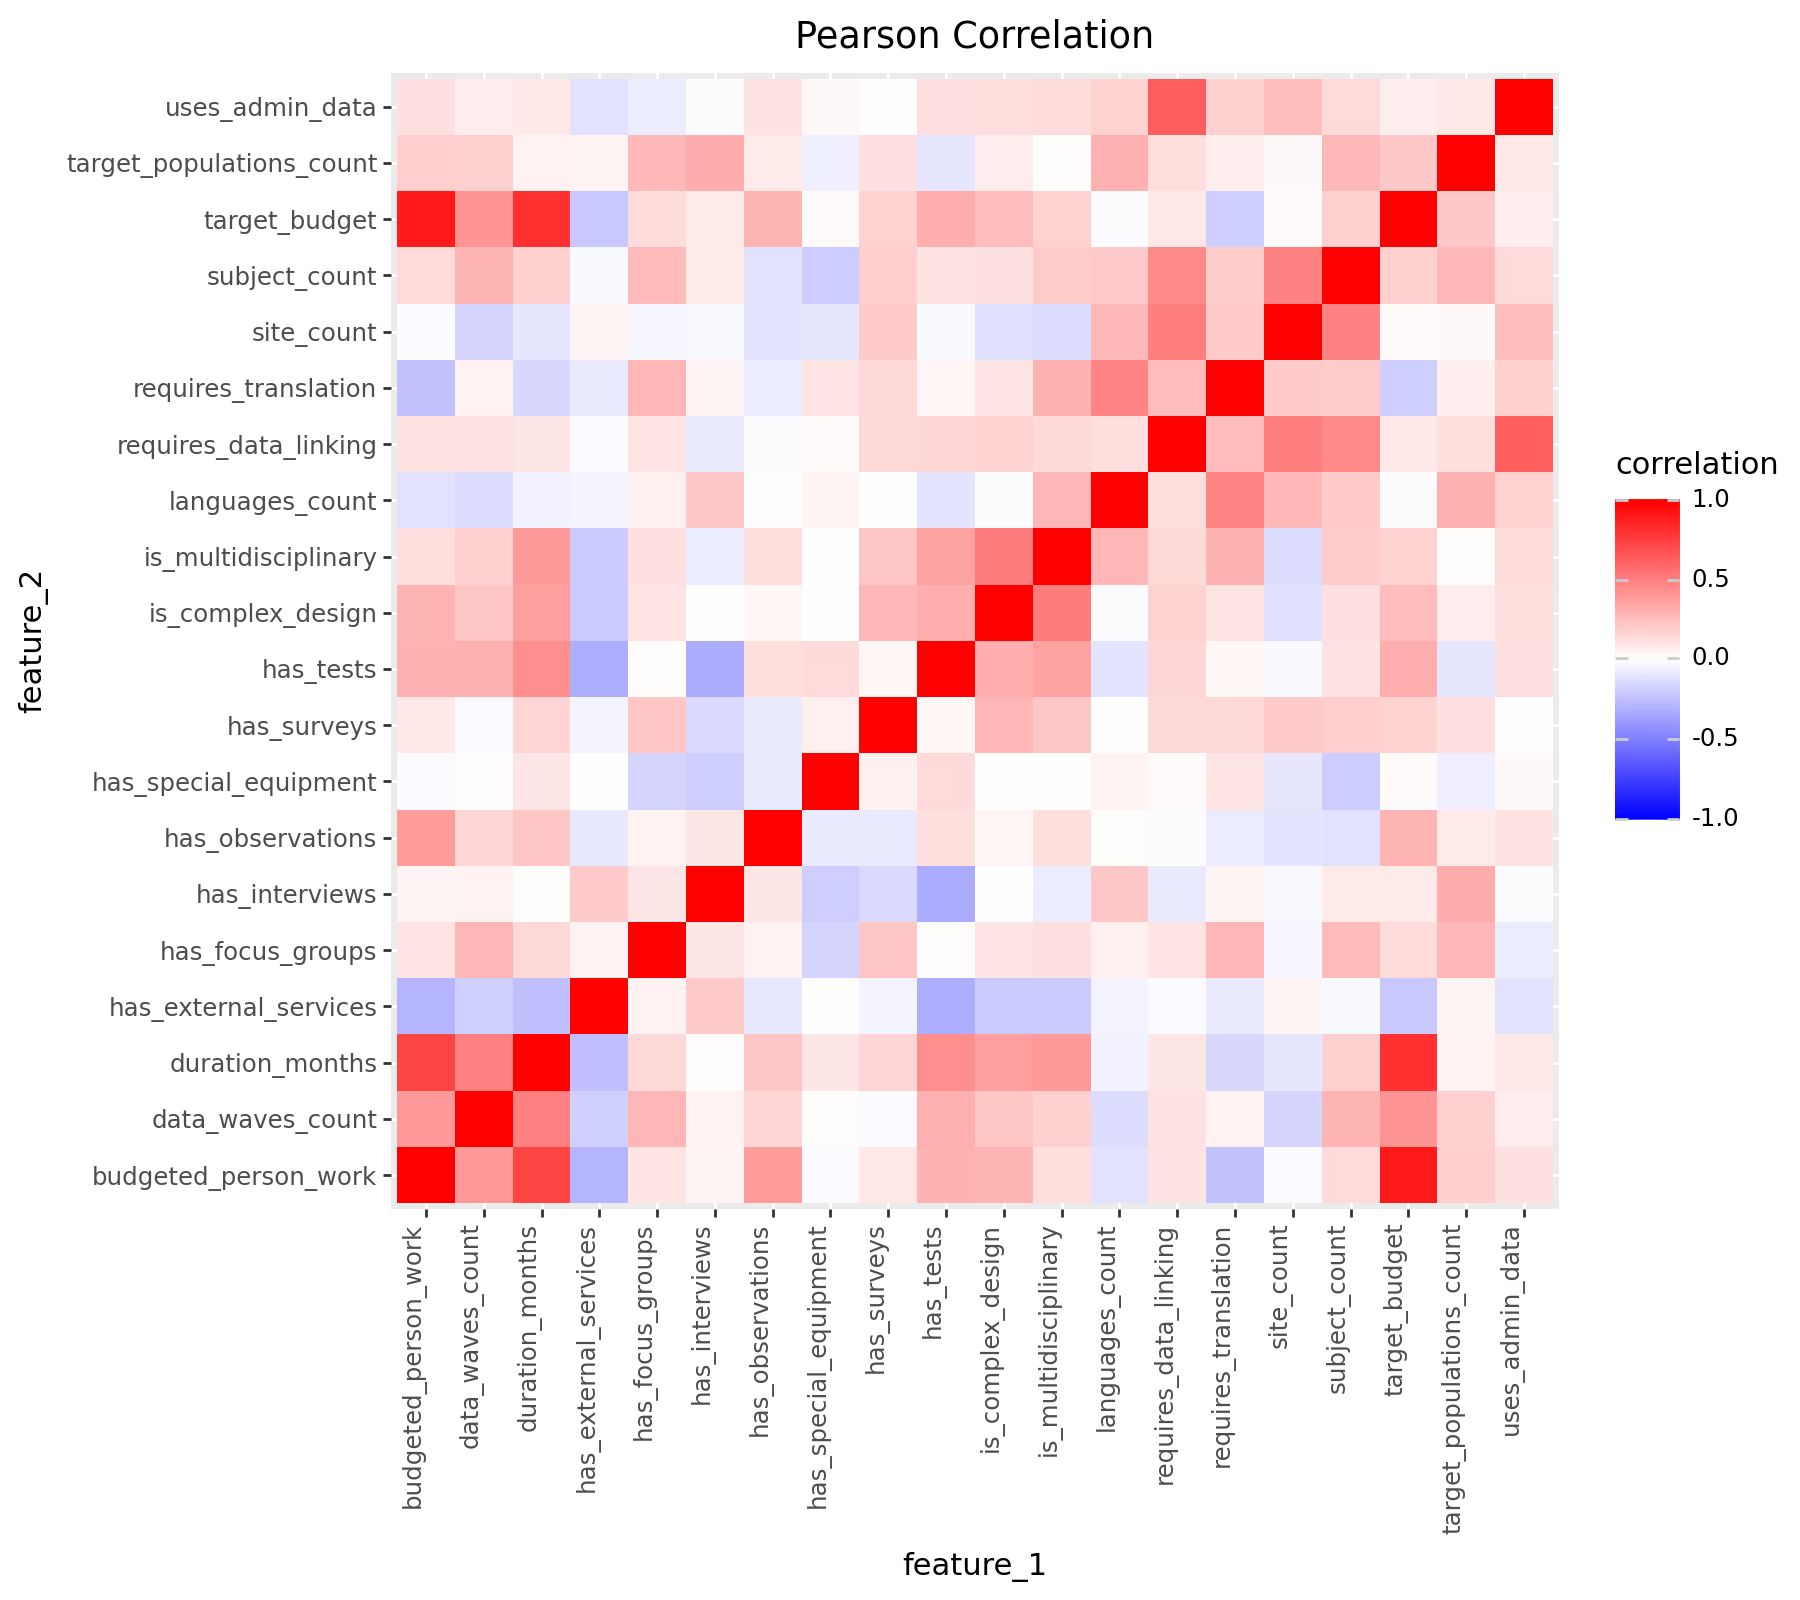

In [289]:
corr_heatmap(linear_corr_cross, "Pearson Correlation")

##### *Spearman corelation analysis*

In [290]:
mono_corr_continuous = df_clean[continuous_cols].corr(method="spearman")
mono_corr_continuous

,duration_months,site_count,subject_count,target_populations_count,data_waves_count,languages_count,budgeted_person_work,target_budget
duration_months,1.000000,-0.016205,0.135715,0.041663,0.450312,-0.016742,0.624597,0.780495
site_count,-0.016205,1.000000,0.353418,0.173992,-0.140364,0.255291,-0.071606,0.079976
subject_count,0.135715,0.353418,1.000000,0.237089,0.141286,0.175345,0.113994,0.225524
target_populations_count,0.041663,0.173992,0.237089,1.000000,0.211437,0.334462,0.215036,0.204921
data_waves_count,0.450312,-0.140364,0.141286,0.211437,1.000000,-0.123874,0.408887,0.475779
languages_count,-0.016742,0.255291,0.175345,0.334462,-0.123874,1.000000,-0.149712,-0.016229
budgeted_person_work,0.624597,-0.071606,0.113994,0.215036,0.408887,-0.149712,1.000000,0.697608
target_budget,0.780495,0.079976,0.225524,0.204921,0.475779,-0.016229,0.697608,1.000000


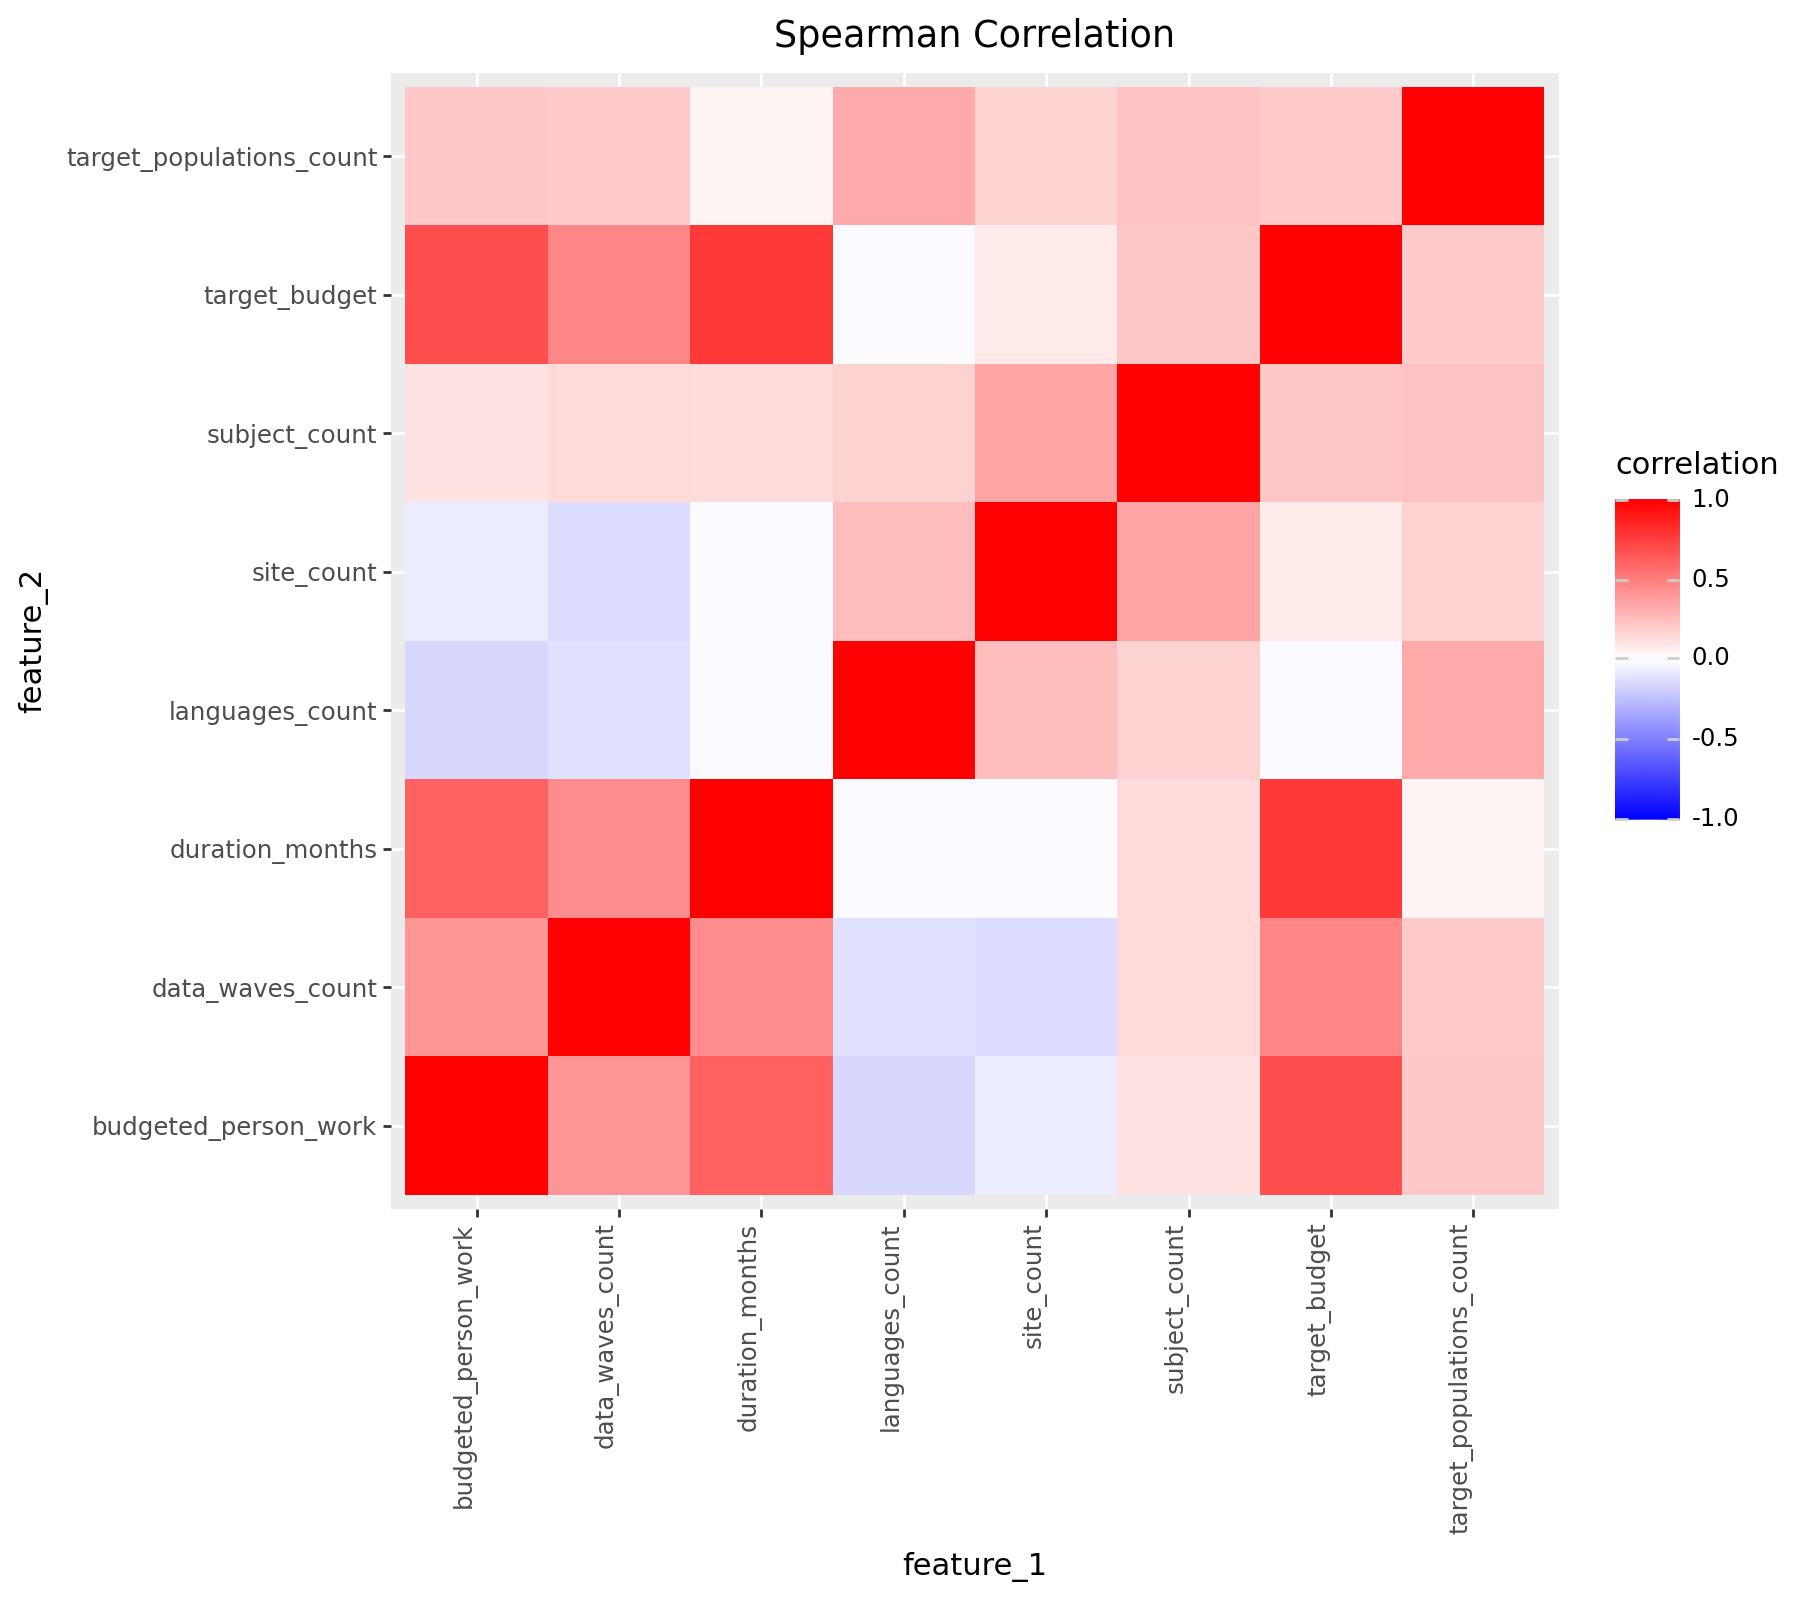

In [291]:
corr_heatmap(mono_corr_continuous, "Spearman Correlation")

In [292]:
mono_corr_binary = df_clean[binary_cols].corr(method="spearman")
mono_corr_binary

,has_surveys,has_interviews,has_focus_groups,has_observations,has_tests,requires_translation,uses_admin_data,requires_data_linking,is_complex_design,has_external_services,has_special_equipment,is_multidisciplinary
has_surveys,1.000000,-0.146633,0.223607,-0.079860,0.038749,0.153013,-0.001625,0.150756,0.288880,-0.040752,0.055826,0.226474
has_interviews,-0.146633,1.000000,0.097367,0.097367,-0.324619,0.042237,-0.010864,-0.083892,-0.002865,0.205674,-0.194912,-0.074410
has_focus_groups,0.223607,0.097367,1.000000,0.050000,0.008665,0.284841,-0.072703,0.102316,0.104964,0.050482,-0.168550,0.123433
has_observations,-0.079860,0.097367,0.050000,1.000000,0.132135,-0.071876,0.114044,-0.015006,0.031523,-0.093391,-0.083151,0.131861
has_tests,0.038749,-0.324619,0.008665,0.132135,1.000000,0.034758,0.122399,0.159366,0.314150,-0.319524,0.148378,0.363492
requires_translation,0.153013,0.042237,0.284841,-0.071876,0.034758,1.000000,0.186863,0.261822,0.102404,-0.085876,0.107443,0.299718
uses_admin_data,-0.001625,-0.010864,-0.072703,0.114044,0.122399,0.186863,1.000000,0.634435,0.130152,-0.110660,0.028903,0.141146
requires_data_linking,0.150756,-0.083892,0.102316,-0.015006,0.159366,0.261822,0.634435,1.000000,0.173887,-0.020570,0.022376,0.154524
is_complex_design,0.288880,-0.002865,0.104964,0.031523,0.314150,0.102404,0.130152,0.173887,1.000000,-0.205856,-0.005525,0.515644
has_external_services,-0.040752,0.205674,0.050482,-0.093391,-0.319524,-0.085876,-0.110660,-0.020570,-0.205856,1.000000,-0.006011,-0.209875


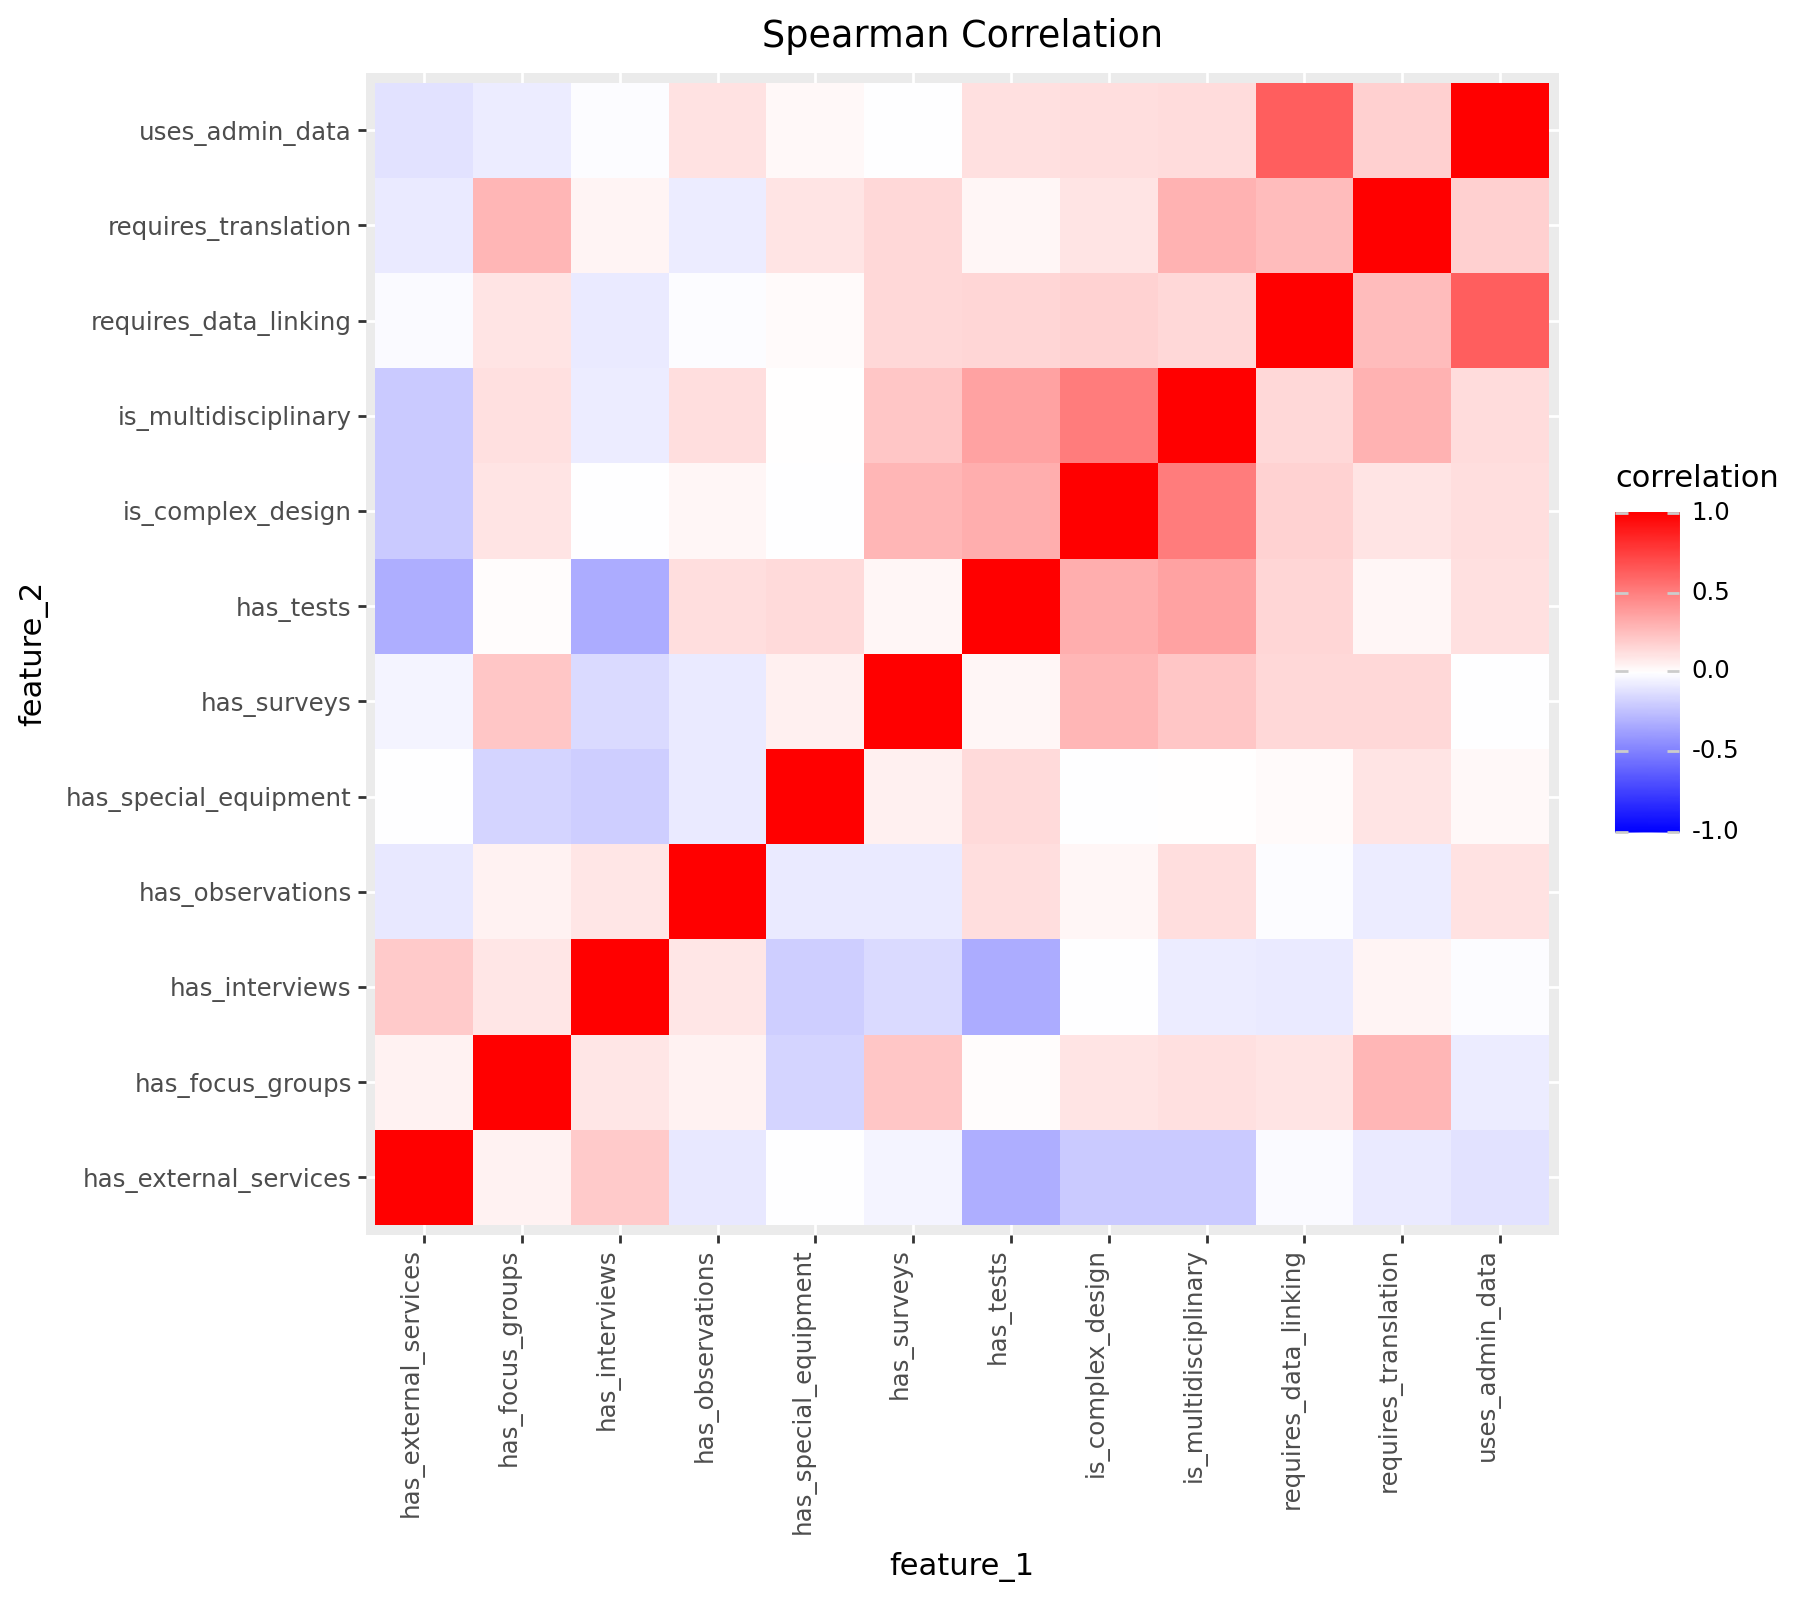

In [293]:
corr_heatmap(mono_corr_binary, "Spearman Correlation")

In [294]:
mono_corr_cross = df_clean[numeric_cols].corr(method="spearman")
mono_corr_cross

,duration_months,site_count,subject_count,target_populations_count,data_waves_count,has_surveys,has_interviews,has_focus_groups,has_observations,has_tests,languages_count,requires_translation,uses_admin_data,requires_data_linking,is_complex_design,budgeted_person_work,has_external_services,has_special_equipment,is_multidisciplinary,target_budget
duration_months,1.000000,-0.016205,0.135715,0.041663,0.450312,0.178373,-0.024348,0.124454,0.238962,0.477083,-0.016742,-0.136623,0.024851,0.085243,0.421891,0.624597,-0.198041,0.123875,0.466773,0.780495
site_count,-0.016205,1.000000,0.353418,0.173992,-0.140364,0.284832,0.065865,0.054654,-0.120098,0.012240,0.255291,0.140386,0.188553,0.443165,0.023824,-0.071606,-0.036721,-0.076528,0.008014,0.079976
subject_count,0.135715,0.353418,1.000000,0.237089,0.141286,0.512458,-0.080552,0.308430,-0.200964,0.003180,0.175345,0.170880,-0.020759,0.121198,0.207943,0.113994,-0.031304,-0.194064,0.181154,0.225524
target_populations_count,0.041663,0.173992,0.237089,1.000000,0.211437,0.109909,0.344570,0.318674,0.040537,-0.063719,0.334462,0.061108,0.154751,0.183424,0.140664,0.215036,0.001890,-0.045566,0.050032,0.204921
data_waves_count,0.450312,-0.140364,0.141286,0.211437,1.000000,0.012298,0.037682,0.274052,0.185751,0.308796,-0.123874,0.030693,0.019197,0.076958,0.227216,0.408887,-0.160390,0.022293,0.182631,0.475779
has_surveys,0.178373,0.284832,0.512458,0.109909,0.012298,1.000000,-0.146633,0.223607,-0.079860,0.038749,0.003382,0.153013,-0.001625,0.150756,0.288880,0.030441,-0.040752,0.055826,0.226474,0.228147
has_interviews,-0.024348,0.065865,-0.080552,0.344570,0.037682,-0.146633,1.000000,0.097367,0.097367,-0.324619,0.220882,0.042237,-0.010864,-0.083892,-0.002865,-0.034209,0.205674,-0.194912,-0.074410,-0.069744
has_focus_groups,0.124454,0.054654,0.308430,0.318674,0.274052,0.223607,0.097367,1.000000,0.050000,0.008665,0.070189,0.284841,-0.072703,0.102316,0.104964,0.114982,0.050482,-0.168550,0.123433,0.148635
has_observations,0.238962,-0.120098,-0.200964,0.040537,0.185751,-0.079860,0.097367,0.050000,1.000000,0.132135,-0.003815,-0.071876,0.114044,-0.015006,0.031523,0.367106,-0.093391,-0.083151,0.131861,0.281345
has_tests,0.477083,0.012240,0.003180,-0.063719,0.308796,0.038749,-0.324619,0.008665,0.132135,1.000000,-0.103814,0.034758,0.122399,0.159366,0.314150,0.367637,-0.319524,0.148378,0.363492,0.411197


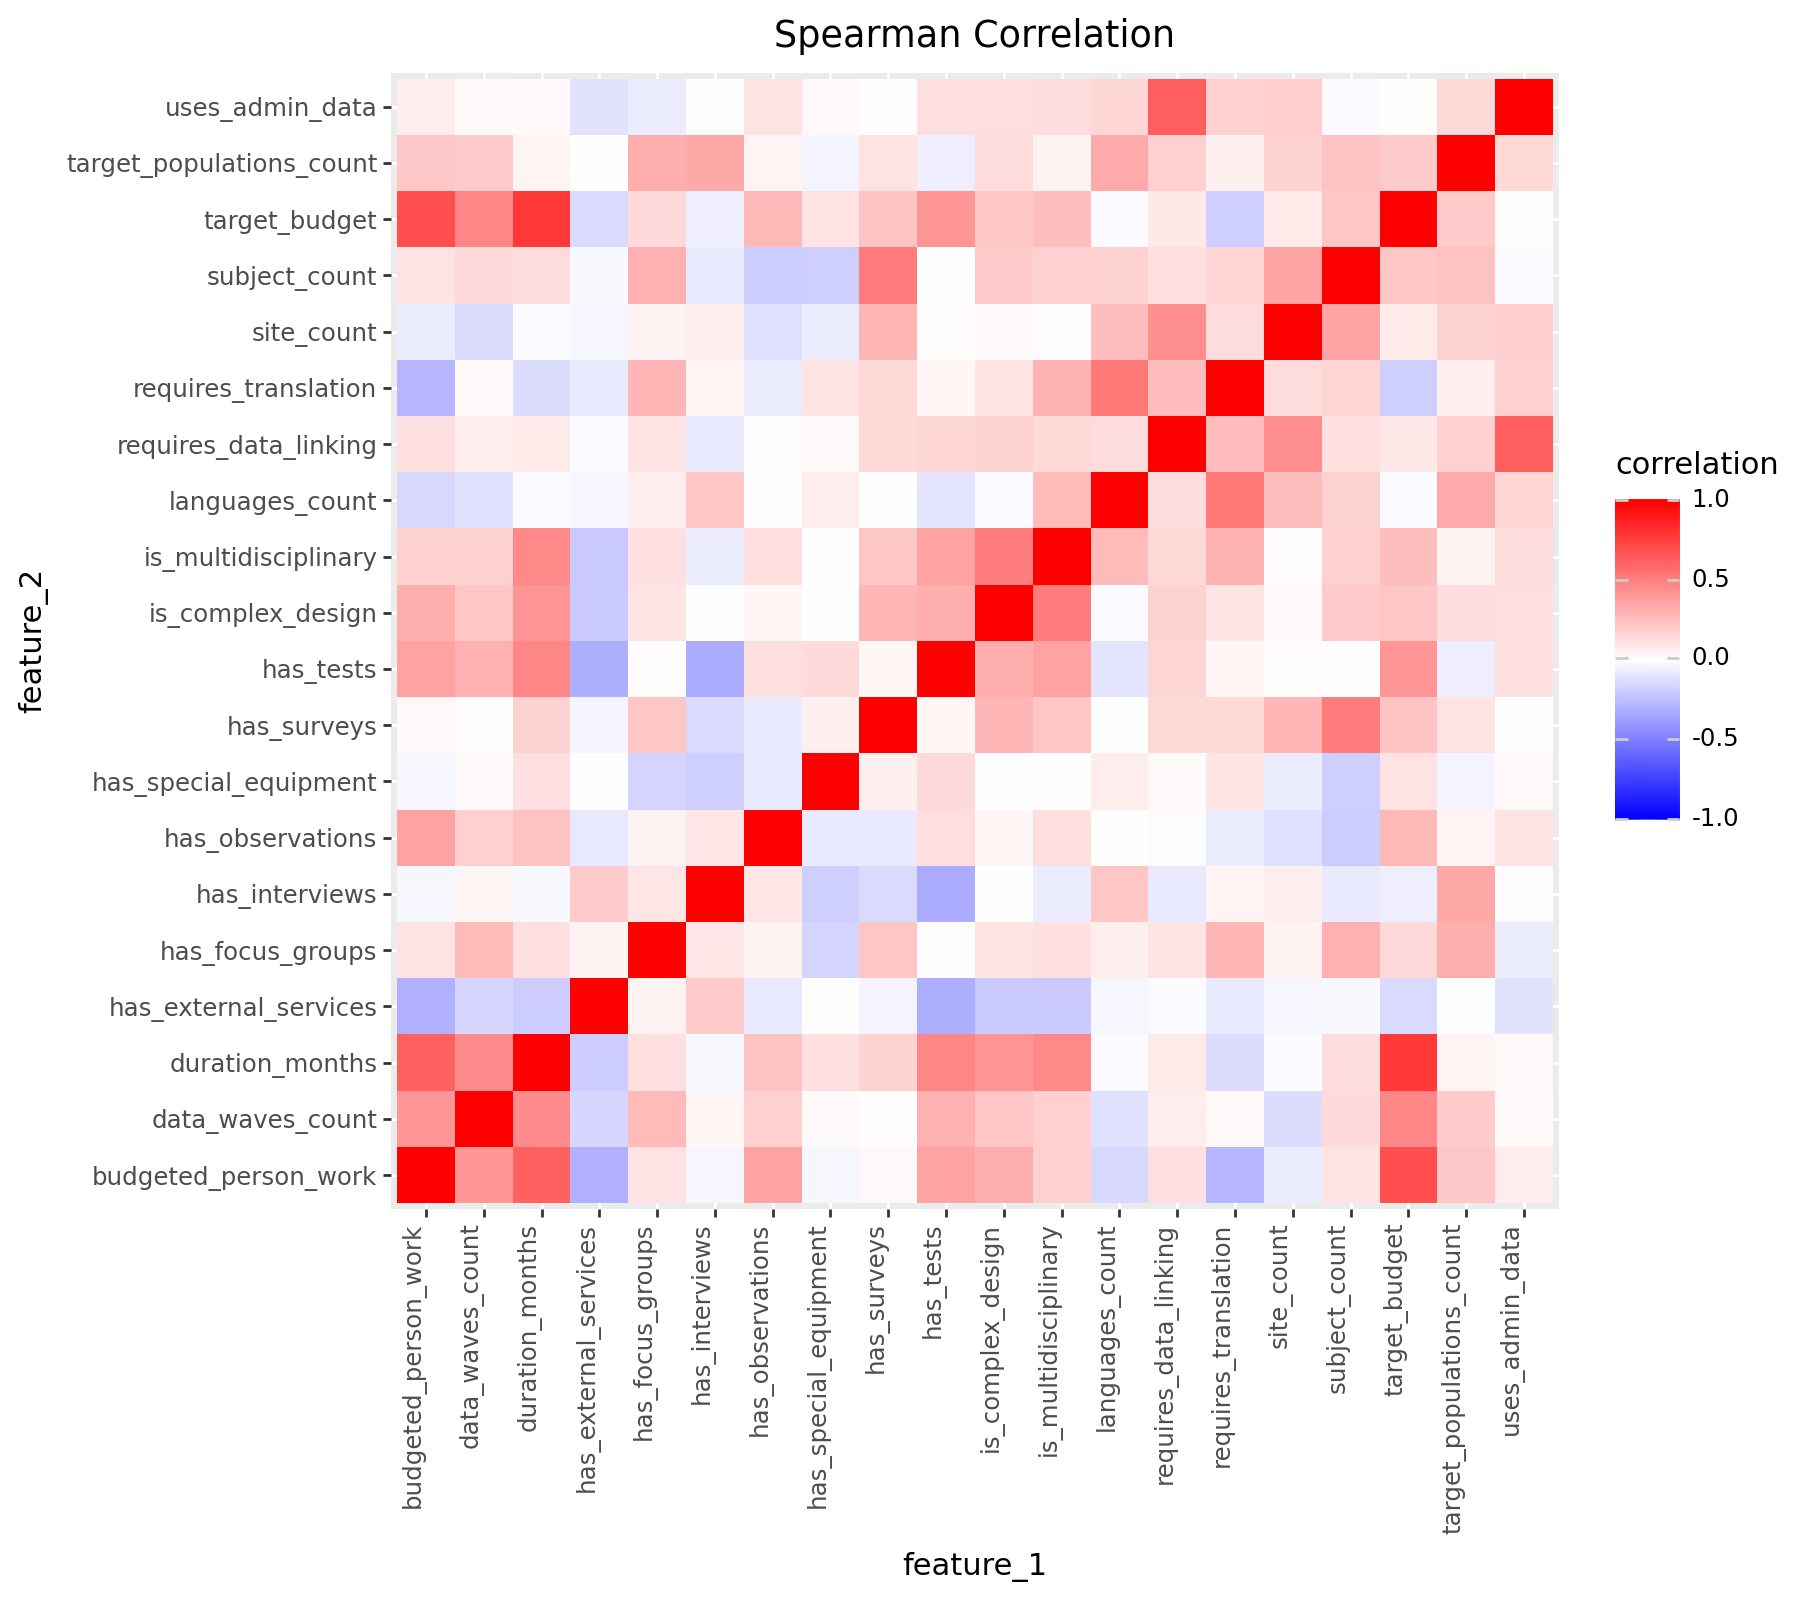

In [295]:
corr_heatmap(mono_corr_cross, "Spearman Correlation")

##### *Insights*

**Table: Top 10 variables most correlated with the target (`target_budget`)**

| # | Variable | Relationship type | Strength |
|---|---|---|---|
| 1 | `budgeted_person_work` | Linear (Pearson) | 0.961 |
| 2 | `duration_months` | Monotonic (Spearman) | 0.806 |
| 3 | `data_waves_count` | Monotonic (Spearman) | 0.532 |
| 4 | `has_tests` | Monotonic (Spearman) | 0.469 |
| 5 | `has_observations` | Linear (Pearson) | 0.406 |
| 6 | `uses_admin_data` | Linear (Pearson) | 0.363 |
| 7 | `is_multidisciplinary` | Monotonic (Spearman) | 0.297 |
| 8 | `subject_count` | Linear (Pearson) | 0.294 |
| 9 | `target_populations_count` | Monotonic (Spearman) | 0.268 |
| 10 | `languages_count` | Linear (Pearson) | 0.255 |

In [296]:
def build_correlation_table(df, cols):
    pearson = df[cols].corr(method="pearson")     # full NxN Pearson correlation matrix
    spearman = df[cols].corr(method="spearman")   # full NxN Spearman correlation matrix

    rows = []  # will collect one dict per unique pair of columns
    for i, c1 in enumerate(cols):        # i = index of c1 in the cols list; c1 = column name itself
        for c2 in cols[i+1:]:            # only pairs AFTER c1 in the list -> avoids (A,B) and (B,A) duplicates, and A vs A
            p = pearson.loc[c1, c2]      # Pearson value for this specific pair
            s = spearman.loc[c1, c2]     # Spearman value for this specific pair
            if pd.isna(p) and pd.isna(s):
                continue                 # skip pairs where both correlations are undefined (e.g., no overlapping data)
            p_abs = abs(p) if pd.notna(p) else -1   # absolute Pearson value, or -1 placeholder if missing
            s_abs = abs(s) if pd.notna(s) else -1   # absolute Spearman value, or -1 placeholder if missing
            if p_abs >= s_abs:
                relationship, strength = "Linear (Pearson)", p       # Pearson wins -> relationship is linear
            else:
                relationship, strength = "Monotonic (Spearman)", s   # Spearman wins -> relationship is monotonic
            rows.append({"var1": c1, "var2": c2, "relationship": relationship, "strength": round(strength, 3)})
            # append this pair's result as one row (dict) to the rows list

    result = pd.DataFrame(rows)                          # convert list of dicts into a DataFrame
    result["abs_strength"] = result["strength"].abs()    # temporary column, used only for sorting
    result = result.sort_values("abs_strength", ascending=False).drop(columns="abs_strength")
    # sort by strongest relationship first, then remove the helper column
    return result.reset_index(drop=True)   # renumber rows 0,1,2,... after sorting


# df_clean: dataframe with -1 / "Unknown" already replaced by NaN
# numeric_cols: list of all numeric columns (continuous + binary)

full_corr_table = build_correlation_table(df_clean, numeric_cols)   # run the function once on the full column list

# Table 1: top 20 strongest relationships across the whole dataset
top20_overall = full_corr_table.head(20)   # first 20 rows = 20 strongest, since table is already sorted

# Table 2: top 10 strongest relationships for a specific target variable
target_col = "target_budget"   # <-- change to whichever variable is your target

target_table = full_corr_table[
    (full_corr_table["var1"] == target_col) | (full_corr_table["var2"] == target_col)
].copy()   # keep only rows where the target variable appears in either column; .copy() avoids a pandas warning later

# Make sure the target variable always appears in var1, for readability
def put_target_first(row):
    if row["var2"] == target_col:               # if target is in var2, swap var1/var2 so target is always first
        return pd.Series({"var1": row["var2"], "var2": row["var1"],
                           "relationship": row["relationship"], "strength": row["strength"]})
    return row   # already in the right order, leave unchanged

target_table = target_table.apply(put_target_first, axis=1)   # apply the swap row-by-row (axis=1 = row-wise)
top10_target = target_table.head(10).reset_index(drop=True)   # first 10 rows + reset row numbering

display(top20_overall)   # Jupyter-friendly table display

,var1,var2,relationship,strength
0,budgeted_person_work,target_budget,Linear (Pearson),0.900
1,duration_months,target_budget,Linear (Pearson),0.810
2,duration_months,budgeted_person_work,Linear (Pearson),0.736
3,uses_admin_data,requires_data_linking,Linear (Pearson),0.634
4,languages_count,requires_translation,Monotonic (Spearman),0.531
5,is_complex_design,is_multidisciplinary,Linear (Pearson),0.516
6,subject_count,has_surveys,Monotonic (Spearman),0.512
7,site_count,requires_data_linking,Linear (Pearson),0.505
8,duration_months,data_waves_count,Linear (Pearson),0.500
9,site_count,subject_count,Linear (Pearson),0.489


In [297]:
display(top10_target)

,var1,var2,relationship,strength
0,target_budget,budgeted_person_work,Linear (Pearson),0.900
1,target_budget,duration_months,Linear (Pearson),0.810
2,target_budget,data_waves_count,Monotonic (Spearman),0.476
3,target_budget,has_tests,Monotonic (Spearman),0.411
4,target_budget,has_observations,Linear (Pearson),0.292
5,target_budget,is_complex_design,Linear (Pearson),0.264
6,target_budget,is_multidisciplinary,Monotonic (Spearman),0.253
7,target_budget,has_surveys,Monotonic (Spearman),0.228
8,target_budget,subject_count,Monotonic (Spearman),0.226
9,target_budget,target_populations_count,Linear (Pearson),0.214


##### *Feature exclusion decisions*

| Feature | Issue | Decision |
|---|---|---|
| `budgeted_person_work` | Leakage (r=0.961 with target, same source doc) **and** not known at prediction time — it's a downstream breakdown of the total budget, not a preceding input | **Excluded** |
| `site_count`, `data_waves_count` | >35% missing + weak NotebookLM labeling | Pending audit results (see Labeling audit) — may become a binned "don't know yet" category instead of exclusion |
| `has_surveys` | Near-constant (low variance) | Exclude, or fold into an aggregate methodology-complexity score |
| `call_title`, `pi_name`, `proposal_title`, `source_file` | Free text | Excluded from tabular model (future NLP feature only) |

#### *Categorical correlation*